## Table of Contents

1. Introduction
2. Data Preparation
3. Data Cleaning & Validation
4. Data Transformation & Feature Engineering
5. Exploratory Data Analysis
6. Revenue Analysis
7. Anomaly Detection
8. Customer Analysis
9. KPI Dashboard
10. Statistical Analysis & A/B Testing
11. Correlation & Feature Relationships
12. Business Insights & Recommendations
13. Final Conclusion
14. RFM Segmentation
15. Customer Clustering
16. Churn Prediction Model
17. Customer Lifetime Value (CLV) Prediction — 12 months

# 1. Introduction

## 1.1 Project Overview

This project delivers an end-to-end analysis of an e-commerce sales dataset, covering:

- data preparation, cleaning and validation
- feature engineering and exploratory analysis
- revenue and anomaly analysis
- customer segmentation (RFM + KMeans)
- statistical A/B testing (gender effect on basket size)
- churn prediction (Logistic Regression vs Random Forest)
- **Customer Lifetime Value (CLV) prediction — 12-month horizon (BG/NBD + XGBoost)**

## 1.2 Objectives

- Quantify total revenue and its structural drivers (Pareto / Lorenz)
- Profile customer behaviour (age, gender, basket size, purchase frequency)
- Detect and root-cause operational anomalies in the time series
- Build actionable customer segments with tailored retention strategies
- Predict which customers are at risk of churning
- **Forecast 12-month CLV per customer using both probabilistic and ML approaches**

## 1.3 Business Questions

- How is revenue distributed across products, categories and customers?
- Are there anomalies in the time-series of sales — and what caused them?
- Do customer segments behave differently in terms of revenue and frequency?
- Can we predict which customers are about to churn?
- **How much revenue will each customer generate over the next 12 months?**
- **Which customers are worth prioritising for retention and upsell investment?**

# 2. Data Preparation

## 2.1 Import Libraries

In [1]:
# Centralised imports — whole notebook
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from datetime import date, timedelta

# Statistics
import scipy.stats as st
import scipy.stats as stats  # alias used in several cells
from scipy.stats import chi2
import statsmodels.api as sm

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, silhouette_score, silhouette_samples,
    mean_absolute_error, mean_squared_error, r2_score, make_scorer
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## 2.2 Data Loading

Datasets used: Customers, Producs and Transactions.


In [2]:
# The 3 source CSV files are expected in a ./data folder next to this notebook.
DATA_DIR = "data"

df_cust  = pd.read_csv(f"{DATA_DIR}/customers.csv")
df_prods = pd.read_csv(f"{DATA_DIR}/products.csv")
df_trans = pd.read_csv(f"{DATA_DIR}/transactions.csv", parse_dates=["date"])

print("customers :", df_cust.shape)
print("products  :", df_prods.shape)
print("transactions :", df_trans.shape)


customers : (8623, 3)
products  : (3287, 3)
transactions : (337016, 4)


## 2.3 Data Overview


In [3]:
print("Customers: ", df_cust.shape, "\n")
print(df_cust.describe(), "\n")
df_cust.info()
print("\n")
df_cust.head()


Customers:  (8623, 3) 

             birth
count  8623.000000
mean   1978.280877
std      16.919535
min    1929.000000
25%    1966.000000
50%    1979.000000
75%    1992.000000
max    2004.000000 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8623 entries, 0 to 8622
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8623 non-null   object
 1   sex        8623 non-null   object
 2   birth      8623 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB




,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [4]:
print("Products: ", df_prods.shape, "\n")
print(df_prods.describe(), "\n")
df_prods.info()
print("\n")
df_prods.head()

Products:  (3287, 3) 

             price        categ
count  3287.000000  3287.000000
mean     21.856641     0.370246
std      29.847908     0.615387
min      -1.000000     0.000000
25%       6.990000     0.000000
50%      13.060000     0.000000
75%      22.990000     1.000000
max     300.000000     2.000000 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3287 non-null   object 
 1   price    3287 non-null   float64
 2   categ    3287 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.2+ KB




,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [5]:
print("Transactions: ", df_trans.shape, "\n \n")
print(df_trans.describe(), "\n")
df_trans.info()
df_trans.head()


Transactions:  (337016, 4) 
 

       id_prod                             date session_id client_id
count   337016                           337016     337016    337016
unique    3266                           336855     169195      8602
top      1_369  test_2021-03-01 02:30:02.237413        s_0    c_1609
freq      1081                               13        200     12855 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337016 entries, 0 to 337015
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     337016 non-null  object
 1   date        337016 non-null  object
 2   session_id  337016 non-null  object
 3   client_id   337016 non-null  object
dtypes: object(4)
memory usage: 10.3+ MB


,id_prod,date,session_id,client_id
0,0_1483,2021-04-10 18:37:28.723910,s_18746,c_4450
1,2_226,2022-02-03 01:55:53.276402,s_159142,c_277
2,1_374,2021-09-23 15:13:46.938559,s_94290,c_4270
3,0_2186,2021-10-17 03:27:18.783634,s_105936,c_4597
4,0_1351,2021-07-17 20:34:25.800563,s_63642,c_1242


# 3. Data Cleaning & Validation

## 3.1 Missing Values

In [6]:
print("Products\n", df_prods.isna().sum())

Products
 id_prod    0
price      0
categ      0
dtype: int64


In [7]:
print("Transactions\n", df_trans.isna().sum())

Transactions
 id_prod       0
date          0
session_id    0
client_id     0
dtype: int64


## 3.2 Anomaly detection

In [8]:
def detect_suspicious_ids_global(df, n_display=10):
    """
    Anomaly detection in, products, clients 
    and transactions.
    """
    
    # pattern dictionary
    # valid formats: 
    patterns = {
    'id_prod': r'^[0-2]_\d+$',           # Valid: starts with 0_, 1_ ou 2_ 
    'client_id': r'^c_\d+$',             # Valid: starts with c_ 
    'session_id': r'^s_[1-9]\d*$',       # Valid: starts with s_ followed by numbers excluding s_0
    'date': r'^\d{4}-\d{2}-\d{2}',       # Valid: excludes 'test_'
    'price': r'^\d+(\.\d+)?$'            # valid : only positive numbers
}
    
    all_anomalies = {}

    for column in df.columns:
        if column in patterns:
            pattern = patterns[column]
            
            # String conversion
            series_str = df[column].astype(str)
            
            invalid = df[~series_str.str.match(pattern, na=False)]
            
            if len(invalid) > 0:
                print(f"\n" + "═"*75)
                print(f" Anomalies found in : {column}")
                print(f"Number of suspicious lines : {len(invalid)}")
                
                # Print problematic values
                print(f"Rejected values' Extract : {invalid[column].unique()[:10]}")
                
                print("\nData extracts :")
                display(invalid.head(n_display))
                
                all_anomalies[column] = invalid
                
    return all_anomalies

In [9]:
invalid_clients = detect_suspicious_ids_global(df_cust, n_display=10)



═══════════════════════════════════════════════════════════════════════════
 Anomalies found in : client_id
Number of suspicious lines : 2
Rejected values' Extract : ['ct_0' 'ct_1']

Data extracts :


,client_id,sex,birth
2735,ct_0,f,2001
8494,ct_1,m,2001


In [10]:
invalid_products = detect_suspicious_ids_global(df_prods, n_display=10)


═══════════════════════════════════════════════════════════════════════════
 Anomalies found in : id_prod
Number of suspicious lines : 1
Rejected values' Extract : ['T_0']

Data extracts :


,id_prod,price,categ
731,T_0,-1.0,0



═══════════════════════════════════════════════════════════════════════════
 Anomalies found in : price
Number of suspicious lines : 1
Rejected values' Extract : [-1.]

Data extracts :


,id_prod,price,categ
731,T_0,-1.0,0


In [11]:
invalid_trans = detect_suspicious_ids_global(df_trans, n_display=10)


═══════════════════════════════════════════════════════════════════════════
 Anomalies found in : id_prod
Number of suspicious lines : 200
Rejected values' Extract : ['T_0']

Data extracts :


,id_prod,date,session_id,client_id
1431,T_0,test_2021-03-01 02:30:02.237420,s_0,ct_1
2365,T_0,test_2021-03-01 02:30:02.237446,s_0,ct_1
2895,T_0,test_2021-03-01 02:30:02.237414,s_0,ct_1
5955,T_0,test_2021-03-01 02:30:02.237441,s_0,ct_0
7283,T_0,test_2021-03-01 02:30:02.237434,s_0,ct_1
13745,T_0,test_2021-03-01 02:30:02.237443,s_0,ct_0
20470,T_0,test_2021-03-01 02:30:02.237442,s_0,ct_0
22347,T_0,test_2021-03-01 02:30:02.237412,s_0,ct_1
26359,T_0,test_2021-03-01 02:30:02.237439,s_0,ct_1
26407,T_0,test_2021-03-01 02:30:02.237426,s_0,ct_0



═══════════════════════════════════════════════════════════════════════════
 Anomalies found in : date
Number of suspicious lines : 200
Rejected values' Extract : ['test_2021-03-01 02:30:02.237420' 'test_2021-03-01 02:30:02.237446'
 'test_2021-03-01 02:30:02.237414' 'test_2021-03-01 02:30:02.237441'
 'test_2021-03-01 02:30:02.237434' 'test_2021-03-01 02:30:02.237443'
 'test_2021-03-01 02:30:02.237442' 'test_2021-03-01 02:30:02.237412'
 'test_2021-03-01 02:30:02.237439' 'test_2021-03-01 02:30:02.237426']

Data extracts :


,id_prod,date,session_id,client_id
1431,T_0,test_2021-03-01 02:30:02.237420,s_0,ct_1
2365,T_0,test_2021-03-01 02:30:02.237446,s_0,ct_1
2895,T_0,test_2021-03-01 02:30:02.237414,s_0,ct_1
5955,T_0,test_2021-03-01 02:30:02.237441,s_0,ct_0
7283,T_0,test_2021-03-01 02:30:02.237434,s_0,ct_1
13745,T_0,test_2021-03-01 02:30:02.237443,s_0,ct_0
20470,T_0,test_2021-03-01 02:30:02.237442,s_0,ct_0
22347,T_0,test_2021-03-01 02:30:02.237412,s_0,ct_1
26359,T_0,test_2021-03-01 02:30:02.237439,s_0,ct_1
26407,T_0,test_2021-03-01 02:30:02.237426,s_0,ct_0



═══════════════════════════════════════════════════════════════════════════
 Anomalies found in : session_id
Number of suspicious lines : 200
Rejected values' Extract : ['s_0']

Data extracts :


,id_prod,date,session_id,client_id
1431,T_0,test_2021-03-01 02:30:02.237420,s_0,ct_1
2365,T_0,test_2021-03-01 02:30:02.237446,s_0,ct_1
2895,T_0,test_2021-03-01 02:30:02.237414,s_0,ct_1
5955,T_0,test_2021-03-01 02:30:02.237441,s_0,ct_0
7283,T_0,test_2021-03-01 02:30:02.237434,s_0,ct_1
13745,T_0,test_2021-03-01 02:30:02.237443,s_0,ct_0
20470,T_0,test_2021-03-01 02:30:02.237442,s_0,ct_0
22347,T_0,test_2021-03-01 02:30:02.237412,s_0,ct_1
26359,T_0,test_2021-03-01 02:30:02.237439,s_0,ct_1
26407,T_0,test_2021-03-01 02:30:02.237426,s_0,ct_0



═══════════════════════════════════════════════════════════════════════════
 Anomalies found in : client_id
Number of suspicious lines : 200
Rejected values' Extract : ['ct_1' 'ct_0']

Data extracts :


,id_prod,date,session_id,client_id
1431,T_0,test_2021-03-01 02:30:02.237420,s_0,ct_1
2365,T_0,test_2021-03-01 02:30:02.237446,s_0,ct_1
2895,T_0,test_2021-03-01 02:30:02.237414,s_0,ct_1
5955,T_0,test_2021-03-01 02:30:02.237441,s_0,ct_0
7283,T_0,test_2021-03-01 02:30:02.237434,s_0,ct_1
13745,T_0,test_2021-03-01 02:30:02.237443,s_0,ct_0
20470,T_0,test_2021-03-01 02:30:02.237442,s_0,ct_0
22347,T_0,test_2021-03-01 02:30:02.237412,s_0,ct_1
26359,T_0,test_2021-03-01 02:30:02.237439,s_0,ct_1
26407,T_0,test_2021-03-01 02:30:02.237426,s_0,ct_0


In [12]:
def detect_suspicious_ids(df, column, pattern):
    invalid = df[~df[column].str.match(pattern)]
    print(f"{len(invalid)} suspicious values detected in {column}")
    return invalid

invalid_clients = detect_suspicious_ids(df_cust, 'client_id', r'^c_\d+$')
invalid_products = detect_suspicious_ids(df_prods, 'id_prod', r'^\d+_\d+$')
invalid_trans = detect_suspicious_ids(df_trans, 'session_id', r'^s_[1-9]\d*$')

2 suspicious values detected in client_id
1 suspicious values detected in id_prod
200 suspicious values detected in session_id


## 3.3 Test Data Removal

In [13]:
prefixes = ('ct_', 'T_', 'test_', 's_0')

df_cust = df_cust[~df_cust.client_id.str.startswith(prefixes)]
df_prods = df_prods[~df_prods.id_prod.str.startswith(prefixes)]
df_trans = df_trans[~df_trans.session_id.str.startswith(prefixes)]

### Post-cleaning check

In [14]:
print("After cleaning:\n")
print("Customers:", df_cust.shape)
print("\nProducts:", df_prods.shape)
print("\nTransactions:", df_trans.shape)

After cleaning:

Customers: (8621, 3)

Products: (3286, 3)

Transactions: (336816, 4)


### Data Cleaning Impact Assessment

We removed a small number of anomalous records:

- 2 customers
- 1 product
- 200 sessions (~0.06% of data)

Given the negligible proportion, this cleaning step does not materially impact
the overall analysis.

A full re-analysis of the dataset was therefore not required.

## 3.4 Referential Integrity

In [15]:
# Clients present in transactions but missing from the customer table
missing_clients = df_trans[~df_trans['client_id'].isin(df_cust['client_id'])]
print("Missing clients in transactions:", len(missing_clients))

# Products present in transactions but missing from the product catalogue
missing_products = df_trans[~df_trans['id_prod'].isin(df_prods['id_prod'])]
print("Missing products in transactions:", len(missing_products))


Missing clients in transactions: 0
Missing products in transactions: 103


In [16]:
df_trans['missing_product'] = ~df_trans['id_prod'].isin(df_prods['id_prod'])
df_trans['missing_product'].value_counts()

missing_product
False    336713
True        103
Name: count, dtype: int64

### Handling Missing Product References

We identified 103 transactions referencing products not present in the product catalog.

Given the low proportion (~0.03% of total transactions), we chose to:

- Reintroduce the missing product(s) into the catalog
- Assign an estimated price based on category averages

This approach preserves revenue consistency while minimizing bias.

Alternative approaches (dropping or flagging) were considered but not retained.

In [17]:
print(
    "Remaining missing products:",
    (~df_trans['id_prod'].isin(df_prods['id_prod'])).sum()
)

Remaining missing products: 103


In [18]:
missing_products_ids = df_trans.loc[
    ~df_trans['id_prod'].isin(df_prods['id_prod']),
    'id_prod'
].unique()

print("Missing product IDs:", missing_products_ids)
print("Number of missing products:", len(missing_products_ids))

Missing product IDs: ['0_2245']
Number of missing products: 1


#### Retrieving missing category & setting its price

In [19]:
missing_product = missing_products_ids[0]

# category extraction from ID
categ = int(missing_product.split('_')[0])

# mean price for category
avg_price = df_prods[df_prods['categ'] == categ]['price'].mean()

print("Inferred category:", categ)
print("Estimated price:", avg_price)

Inferred category: 0
Estimated price: 11.732794627383015


#### Adding missing category

In [20]:
new_product = pd.DataFrame({
    'id_prod': [missing_product],
    'price': [avg_price],
    'categ': [categ],
    'price_estimated': [True]
})

df_prods['price_estimated'] = False

df_prods = pd.concat([df_prods, new_product], ignore_index=True)

#### Checking missing products

In [21]:
remaining = df_trans.loc[
    ~df_trans['id_prod'].isin(df_prods['id_prod'])
]

print("Remaining missing products:", len(remaining))

Remaining missing products: 0


In [22]:
impact = df_trans[df_trans['id_prod'] == missing_product].shape[0]

print("Transactions affected:", impact)
print("Impact %:", round(impact / len(df_trans) * 100, 4))

Transactions affected: 103
Impact %: 0.0306


### Missing Product Summary

One product (`0_2245`) was found in transactions but missing from the product catalog.

Given the very low occurrence (103 transactions), we:

- Inferred its category from the product ID
- Estimated its price using the average price of the category
- Reintroduced it into the product dataset

This ensures consistency while preserving all transaction data and minimizing bias.


⚠️ **Methodological caveat – Reconstructed product `0_2245`**

The price and category assigned to product `0_2245` are *estimated* values, not observed ones:

- **Category** inferred from the product-ID prefix convention (may be wrong if the convention changed).
- **Price** set to the category average — this flattens outliers and could under/overestimate the true price.
- **Impact**: 103 transactions (~0.03 % of the dataset). A ±20 % price sensitivity test was not run.

For production use, the missing product should be retrieved from source systems before analysis.

## 3.5 Duplicate Checks

In [23]:
print("Duplicate customers:", df_cust.duplicated('client_id').sum())
print("Duplicate products:", df_prods.duplicated('id_prod').sum())

print("Duplicate transactions:",
      df_trans.duplicated(['session_id', 'id_prod', 'date']).sum())

Duplicate customers: 0
Duplicate products: 0
Duplicate transactions: 0


## 3.6 Data Type Validation

In [24]:
# Convert date properly
df_trans['date'] = pd.to_datetime(df_trans['date'], errors='coerce')

print("Invalid dates:", df_trans['date'].isna().sum())

Invalid dates: 0


## 3.7 Business Logic Checks

### 3.7.1 Null or Negative Prices

In [25]:
print("Negative prices:", (df_prods['price'] < 0).sum())
print("Zero prices:", (df_prods['price'] == 0).sum())

Negative prices: 0
Zero prices: 0


### 3.7.2 Checking Ages

In [26]:
df_cust['age'] = 2022 - df_cust['birth']

print("Unrealistic ages:", ((df_cust['age'] < 10) | (df_cust['age'] > 100)).sum())

Unrealistic ages: 0


### 3.7.3 Sessions vs Transactions Check

In [27]:
print("Total rows (transactions):", len(df_trans))
print("Unique sessions:", df_trans['session_id'].nunique())
print("Unique clients:", df_trans['client_id'].nunique())

Total rows (transactions): 336816
Unique sessions: 169194
Unique clients: 8600


In [28]:
session_sizes = df_trans.groupby('session_id').size()

print(session_sizes.describe())

count    169194.000000
mean          1.990709
std           1.274256
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          14.000000
dtype: float64


### Sessions vs Transactions Analysis

We analyze the relationship between transactions and sessions to avoid metric confusion.

- Total transactions: 336,816
- Unique sessions: 169,194
- Average transactions per session: ~2

This indicates that:

- A session contains multiple transactions
- Each row represents a product-level purchase

Limitation:
There is no quantity column in the dataset.

Therefore:
- Each transaction is assumed to represent a single unit purchase
- Revenue is correctly computed as the sum of prices
- However, true product volumes cannot be measured

Conclusion:
The dataset is reliable for revenue analysis but limited for volume-based KPIs.

## 3.8 Data Consistency Checks

We performed several checks to ensure data reliability:

- Referential integrity between transactions, customers, and products
- Duplicate detection across primary keys
- Missing value analysis
- Data type validation (notably date parsing)
- Business logic validation (price, age)
- Structural validation of transactions vs sessions

Note:
A transaction row corresponds to a product purchase within a session,
not a full order.

Therefore:
- Revenue per transaction ≠ revenue per session
- Aggregations must be handled carefully

In [29]:
# Sanity check on the average basket size
avg_basket = df_trans.groupby('session_id')['id_prod'].count().mean()
print(f"Average products per session: {avg_basket:.2f}")


Average products per session: 1.99


# 4. Data Transformation & Feature Engineering

## 4.1 Merging Datasets

In [30]:
df = df_trans.merge(df_prods, on="id_prod", how="left")
df = df.merge(df_cust, on="client_id", how="left")

df.head()

,id_prod,date,session_id,client_id,missing_product,price,categ,price_estimated,sex,birth,age
0,0_1483,2021-04-10 18:37:28.723910,s_18746,c_4450,False,4.99,0,False,f,1977,45
1,2_226,2022-02-03 01:55:53.276402,s_159142,c_277,False,65.75,2,False,f,2000,22
2,1_374,2021-09-23 15:13:46.938559,s_94290,c_4270,False,10.71,1,False,f,1979,43
3,0_2186,2021-10-17 03:27:18.783634,s_105936,c_4597,False,4.20,0,False,m,1963,59
4,0_1351,2021-07-17 20:34:25.800563,s_63642,c_1242,False,8.99,0,False,f,1980,42


## 4.2 Feature Engineering

In [31]:
# date type check
#print(df['date'].dtype)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday
df['week'] = df['date'].dt.isocalendar().week
df['age'] = date.today().year - df['birth']
df['year_month'] = df['date'].dt.to_period('M').astype(str)

df["revenue"] = df["price"] * 1

# 5. Exploratory Data Analysis

## 5.1 Revenue Distribution

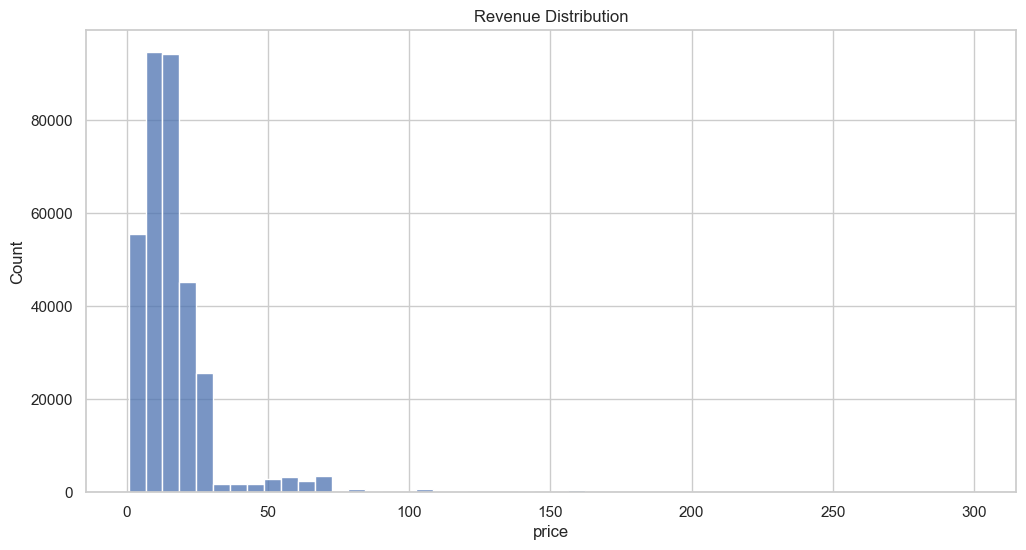

In [32]:
sns.histplot(df['price'], bins=50)
plt.title("Revenue Distribution")
plt.show()

## 5.2 Average Basket Distribution

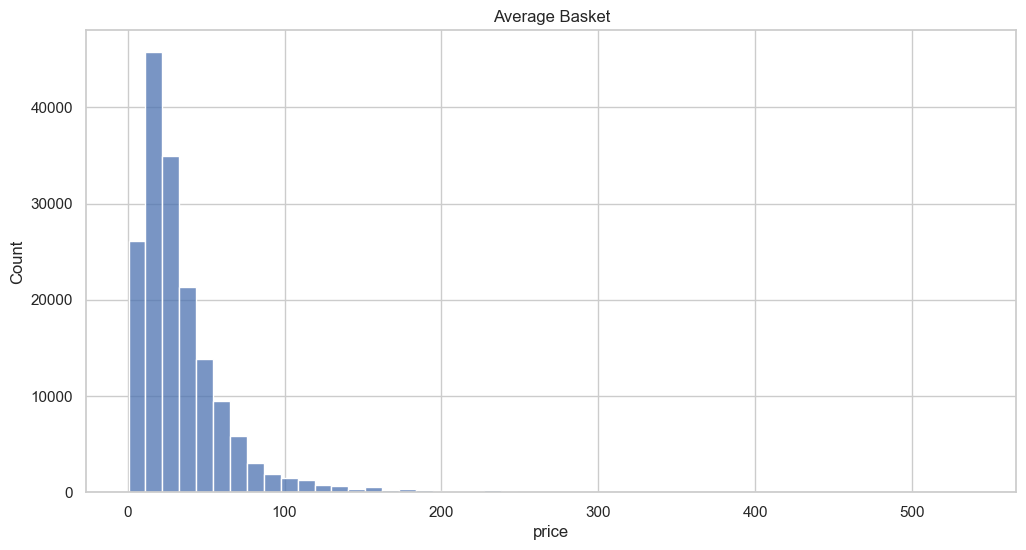

In [33]:
session_sales = df.groupby('session_id')['price'].sum()

sns.histplot(session_sales, bins=50)
plt.title("Average Basket")
plt.show()

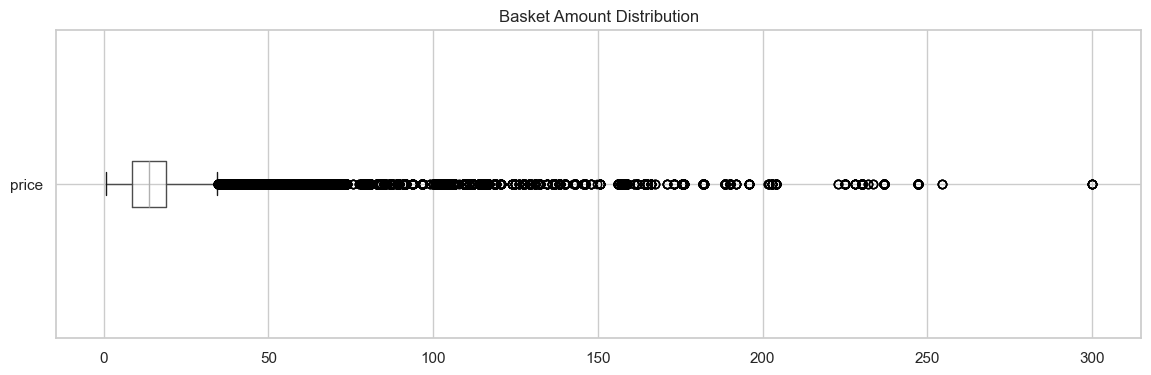

In [34]:
fig = plt.gcf()
fig.set_size_inches(14, 4)
df.boxplot(column="price", vert=False)
plt.title('Basket Amount Distribution')
plt.show()

# 6. Revenue Analysis

## 6.1 Total Revenue

In [35]:
total_revenue = df["revenue"].sum()
print("Total revenue:", round(total_revenue, 0))

Total revenue: 5797786.0


## 6.2 Revenue Over Time

sales_daily = df.groupby("date")["revenue"].sum().reset_index()

plt.plot(sales_daily["date"], sales_daily["revenue"])
plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

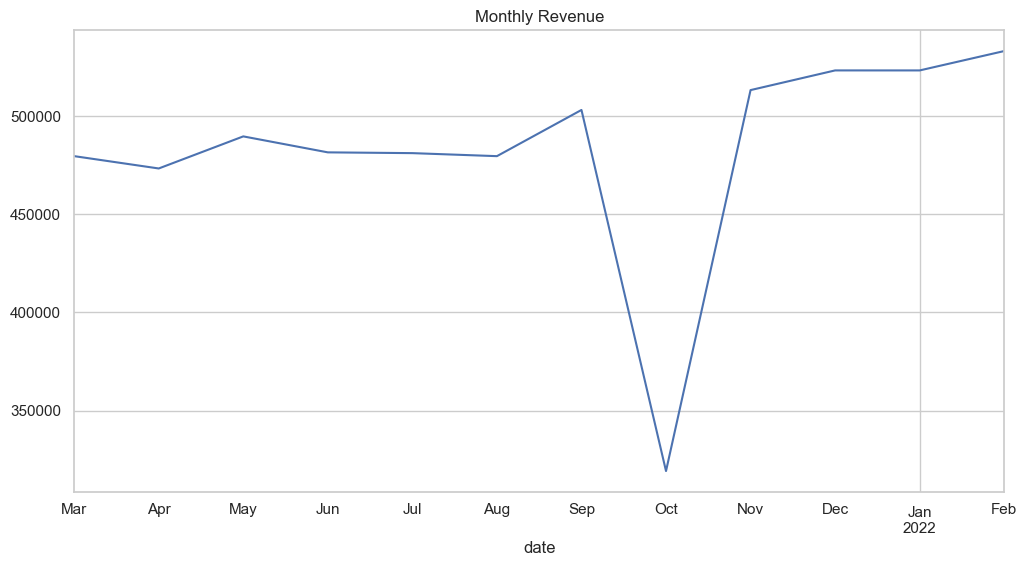

In [36]:
monthly = df.groupby(df['date'].dt.to_period('M'))['price'].sum()

monthly.plot()
plt.title("Monthly Revenue")
plt.show()

**/!\ Sharp drop in revenue in October** 

## 6.3 Revenue by Category

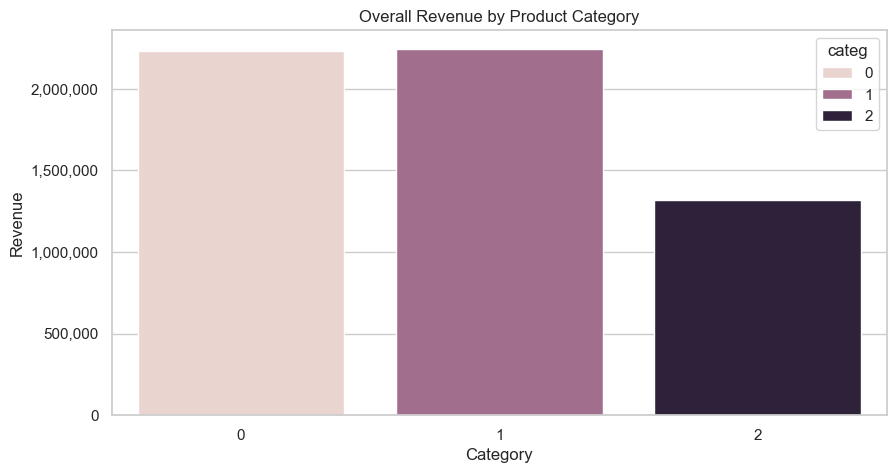

In [37]:
sales_category = df.groupby("categ")["revenue"].sum().reset_index()
#sales_category["categ"] = sales_category["categ"].astype(int)
#sales_category["categ"] = sales_category["categ"].astype(str)

#sns.barplot(data=sales_category, x="categ", y="revenue")
#plt.title("Revenue by Product Category")
#plt.xticks(rotation=45)
#plt.show()



plt.figure(figsize=(10,5))

ax = sns.barplot(data=sales_category, x="categ", y="revenue", hue="categ")

# Disable scientific notation
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.title("Overall Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()

### Anomaly: October revenue drop linked to category 1

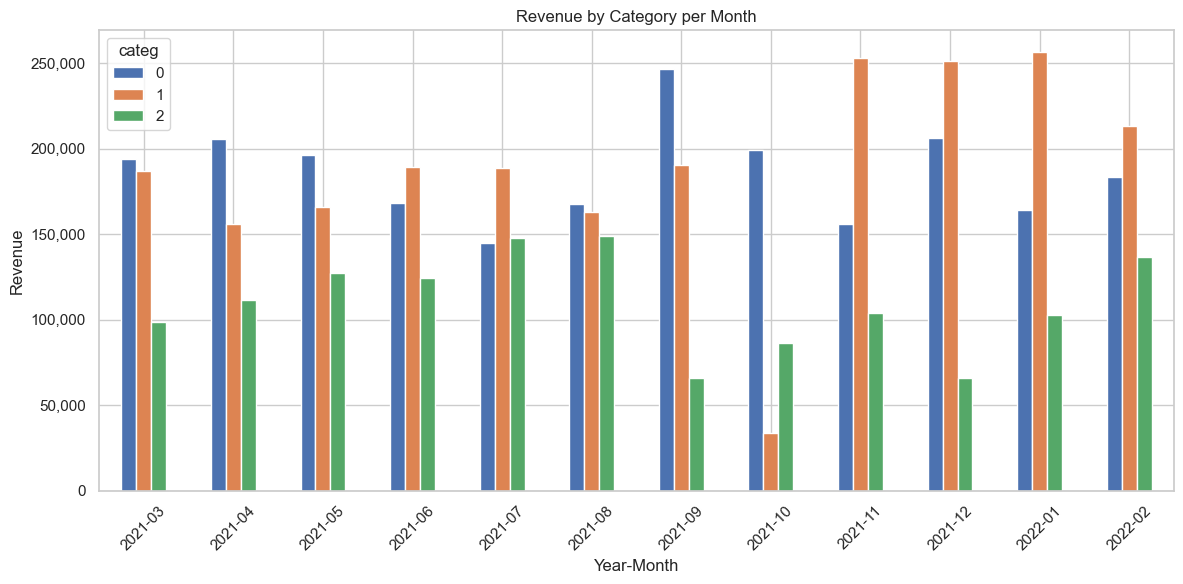

In [38]:
# year-month-category aggregate
sales_by_cat = (df .groupby(['year_month', 'categ'])['price'] .sum() .reset_index() )

sales_by_cat['categ'] = sales_by_cat['categ'].astype(int).astype(str)

pivot_sales = sales_by_cat.pivot(index='year_month', columns='categ', values='price' )

pivot_sales.plot(kind='bar', figsize=(12,6))

plt.title("Revenue by Category per Month")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter( ticker.FuncFormatter(lambda x, _: f'{x:,.0f}') )

plt.tight_layout()
plt.show()

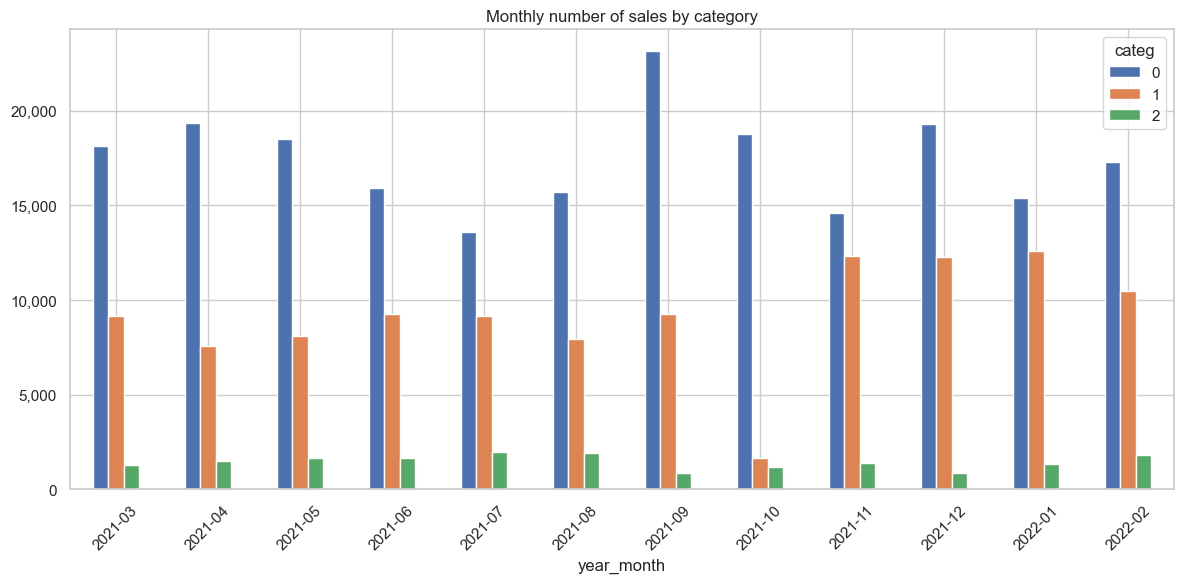

In [39]:
pivot_data = pd.crosstab(df['year_month'], df['categ'])

ax = pivot_data.plot.bar(figsize=(12, 6), title='Monthly number of sales by category')

# 2. Apply formatting commands separately
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Ensure everything fits and display
plt.tight_layout()
plt.show()

## 6.4 Top Clients Analysis

  client_id        revenue   share_%
0    c_1609  162007.340000  2.794297
1    c_4958  144257.210000  2.488143
2    c_6714   73220.805589  1.262910
3    c_3454   54466.385589  0.939434
4    c_7959    2564.250000  0.044228
5    c_8026    2549.402795  0.043972
6    c_4491    2540.530000  0.043819
7    c_2140    2527.010000  0.043586
8    c_8392    2515.980000  0.043396
9    c_7421    2511.980000  0.043327


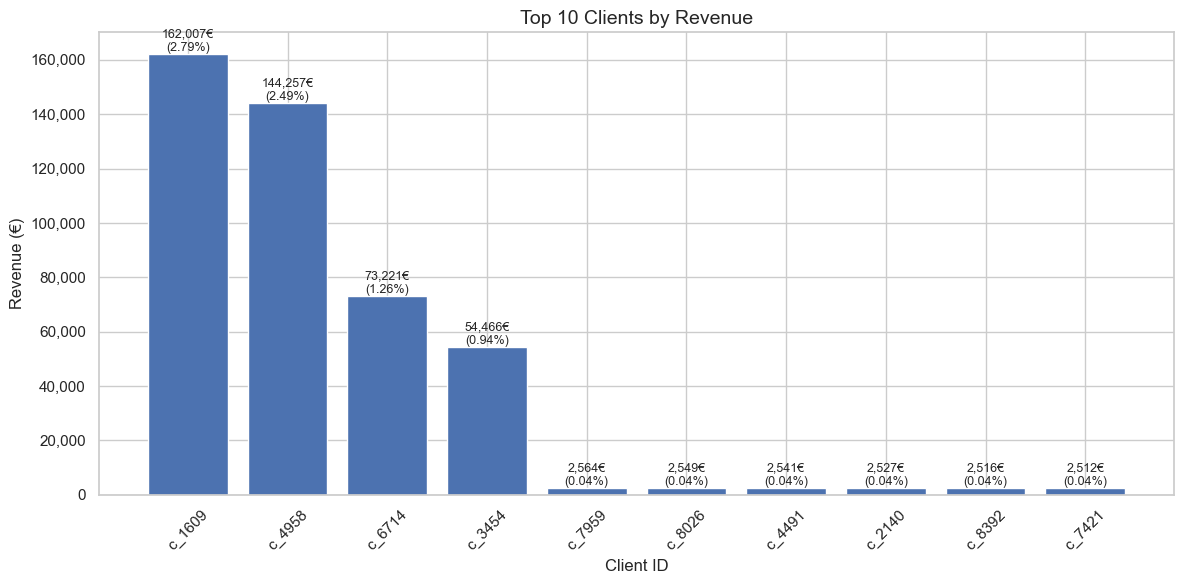

In [40]:
client_revenue = (
    df
    .groupby('client_id')['price']
    .sum()
    .sort_values(ascending=False)
)

total_revenue = client_revenue.sum()

top10_clients = (
    client_revenue
    .head(10)
    .reset_index()
)

top10_clients.columns = ['client_id', 'revenue']

# Share of total revenue (%)
top10_clients['share_%'] = (
    top10_clients['revenue'] / total_revenue * 100
)


print(top10_clients)

plt.figure(figsize=(12,6))

bars = plt.bar(
    top10_clients['client_id'],
    top10_clients['revenue']
)

plt.title("Top 10 Clients by Revenue", fontsize=14)
plt.xlabel("Client ID")
plt.ylabel("Revenue (€)")
plt.xticks(rotation=45)


plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

for i, row in top10_clients.iterrows():
    plt.text(
        i,
        row['revenue'],
        f"{row['revenue']:,.0f}€\n({row['share_%']:.2f}%)",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [41]:
# 1. Calculate total spending per client
# Grouping the main DataFrame to get total revenue (price) per client_id
client_revenue_series = df.groupby('client_id')['price'].sum()

# 2. Identify the Top 5 clients by total spending
top_5_clients_spending = client_revenue_series.nlargest(5).reset_index()
top_5_clients_spending.columns = ['client_id', 'total_spent']

print("Top 5 Clients by Spending: \n")
print(top_5_clients_spending, "\n")

# 3. Analyze purchasing behavior of these Top 5 clients
# We merge the top 5 list back with the original data to see their categories, sex, and age
top_5_detailed_behavior = pd.merge(
    top_5_clients_spending, 
    df[['client_id', 'price', 'categ', 'sex', 'age']], 
    on="client_id", 
    how="left"
)

# Renaming columns for clarity
top_5_detailed_behavior.rename(columns={'price': 'item_price'}, inplace=True)

print("Purchase breakdown for Top 5 clients by category, sex, and age: \n")
print(top_5_detailed_behavior.head(10)) # Showing first 10 rows for brevity

# 4. Create a comprehensive Customer Spending DataFrame
# This summarizes every customer with their total spending and demographic info
customer_spending_summary = (
    df.groupby('client_id')
    .agg({
        'price': 'sum',
        'sex': 'first',
        'age': 'first'
    })
    .reset_index()
)

customer_spending_summary.columns = ['client_id', 'total_spent', 'sex', 'age']

# 5. Display the final summary
print("\nFinal Customer Spending Summary (First 5 rows):")
print(customer_spending_summary.head())

Top 5 Clients by Spending: 

  client_id    total_spent
0    c_1609  162007.340000
1    c_4958  144257.210000
2    c_6714   73220.805589
3    c_3454   54466.385589
4    c_7959    2564.250000 

Purchase breakdown for Top 5 clients by category, sex, and age: 

  client_id  total_spent  item_price  categ sex  age
0    c_1609    162007.34       11.53      0   m   46
1    c_1609    162007.34       23.99      1   m   46
2    c_1609    162007.34        3.99      0   m   46
3    c_1609    162007.34       23.83      1   m   46
4    c_1609    162007.34        9.99      0   m   46
5    c_1609    162007.34        5.65      0   m   46
6    c_1609    162007.34       11.99      1   m   46
7    c_1609    162007.34        9.99      0   m   46
8    c_1609    162007.34       16.99      1   m   46
9    c_1609    162007.34       15.99      0   m   46

Final Customer Spending Summary (First 5 rows):
  client_id  total_spent sex  age
0       c_1       300.65   m   71
1      c_10       586.18   m   70
2     c

In [42]:
# ── df_analysis prerequisite ────────────────────────────────────────────
if 'age' not in df.columns:
    df['age'] = date.today().year - df['birth']

if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(
        df['age'], bins=[0, 25, 35, 50, 100],
        labels=['-25', '25-35', '36-50', '+50']
    )

if 'year' not in df.columns:
    df['date']  = pd.to_datetime(df['date'])
    df['year']  = df['date'].dt.year
    df['month'] = df['date'].dt.month

df_analysis = df[['age_group', 'age', 'price', 'categ', 'year', 'month']].copy()
print('df_analysis ready:', df_analysis.shape)


df_analysis ready: (336816, 6)


In [43]:
# 1. Create the Contingency Table (Crosstab)
# This measures the correlation between Age Groups and Product Categories
contingency_table = pd.crosstab(
    df_analysis['age_group'], 
    df_analysis['categ'],
    margins=False
)

# 2. Reindexing to ensure age groups are in the correct logical order
# This fixes the sorting if the categories appear out of order
logical_order = ["-25", "25-35", "36-50", "+50"]
contingency_table = contingency_table.reindex(logical_order)

# 3. Display the table
print("Contingency Table: Sales Volume by Age Group and Category")
contingency_table

Contingency Table: Sales Volume by Age Group and Category


categ,0,1,2
age_group,,,
-25,3115,5138,5533
25-35,11835,11154,10636
36-50,127868,37551,433
+50,66711,55892,950


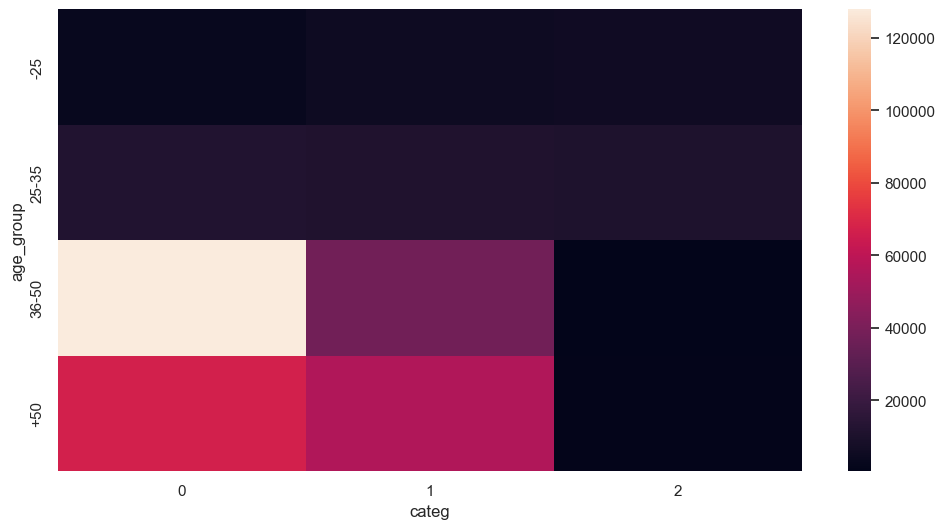

In [44]:
heat_map = sns.heatmap(contingency_table)
plt.show()


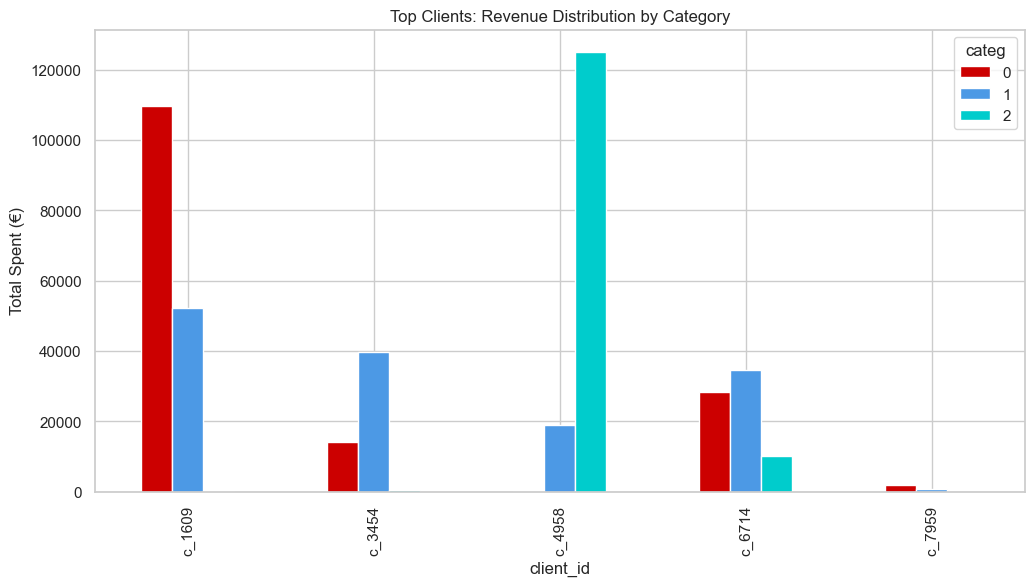

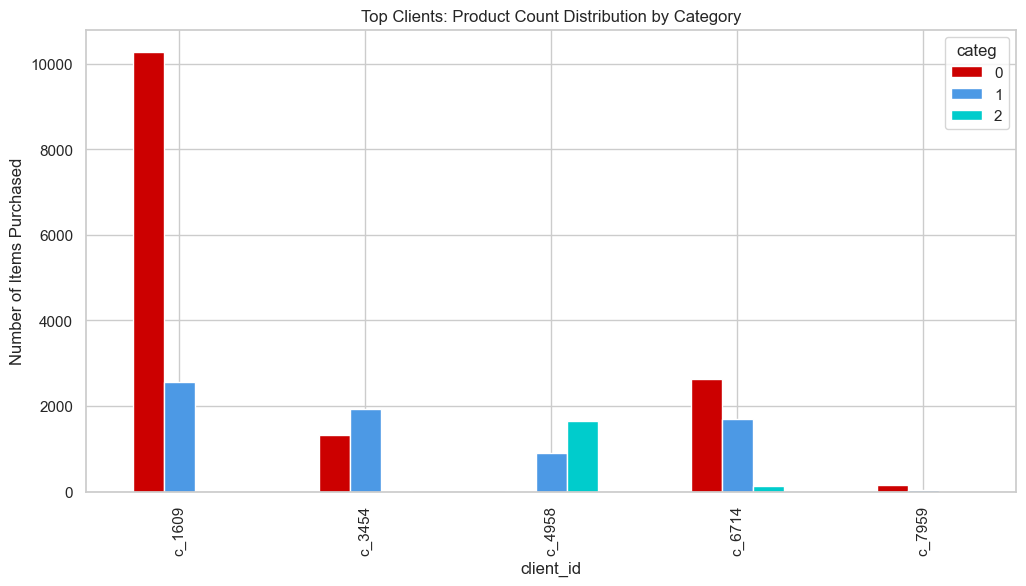

Top 5 Best-Selling Products per Category:
      id_prod  categ  price  sales_volume
466   0_1422      0  11.41           670
472   0_1428      0   3.55           635
469   0_1425      0  12.99           631
476   0_1431      0  10.99           631
454   0_1411      0   8.99           626
2591   1_369      1  23.99          1081
2644   1_417      1  20.99          1062
2733   1_498      1  23.37          1036
2641   1_414      1  23.83          1027
2653   1_425      1  16.99          1013
3070   2_135      2  68.99           491
3034   2_102      2  59.14           489
3045   2_112      2  67.57           473
3199    2_37      2  48.99           436
3201    2_39      2  57.99           435 



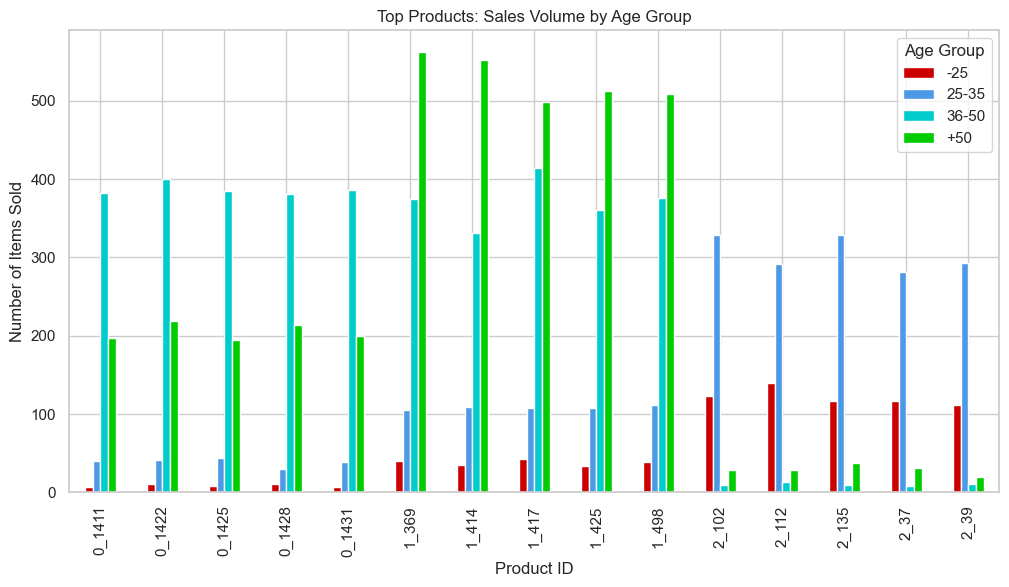

In [45]:
# 1. Visualization: Top Clients Spending and Volume by Category
# Total spending per category for top clients
top_5_detailed_behavior.groupby(['client_id', 'categ'])['item_price'].sum().unstack().plot.bar(
    figsize=[12, 6], 
    title="Top Clients: Revenue Distribution by Category", 
    color=('#CC0000', '#4C99E5', '#00CCCC', '#00CC00')
)
plt.ylabel("Total Spent (€)")
plt.show()

# Number of products purchased per category for top clients
top_5_detailed_behavior.groupby(['client_id', 'categ'])['item_price'].count().unstack().plot.bar(
    figsize=[12, 6], 
    title="Top Clients: Product Count Distribution by Category", 
    color=('#CC0000', '#4C99E5', '#00CCCC', '#00CC00')
)
plt.ylabel("Number of Items Purchased")
plt.show()

# 2. Identify Top 5 Best-Selling Products per Category
# We group by product and category to count sales volume
product_sales_stats = (
    df.groupby(['id_prod', 'categ', 'price'])
    .size()
    .reset_index(name='sales_volume')
)

# Concatenate the top 5 products for each category (0, 1, and 2)
top_products_by_cat = pd.concat([
    product_sales_stats[product_sales_stats['categ'] == 0].nlargest(5, 'sales_volume'),
    product_sales_stats[product_sales_stats['categ'] == 1].nlargest(5, 'sales_volume'),
    product_sales_stats[product_sales_stats['categ'] == 2].nlargest(5, 'sales_volume')
])

print("Top 5 Best-Selling Products per Category:\n", top_products_by_cat, "\n")

# 3. Visualization: Top Products by Age Group
# Filter the main dataframe to only include these top products
top_product_ids = top_products_by_cat["id_prod"]

# Note: Ensure 'age_group' column exists in your main 'df' as created in previous steps
df_top_products_sales = df[df['id_prod'].isin(top_product_ids)].copy()

# Applying age bins to this subset if not already in df
bins = [0, 24, 35, 50, 105]
labels = ["-25", "25-35", "36-50", "+50"]
df_top_products_sales['age_group'] = pd.cut(df_top_products_sales['age'], bins=bins, labels=labels)

# Plotting the breakdown of top product sales by age group
df_top_products_sales.groupby(['id_prod', 'age_group'])['price'].count().unstack().plot.bar(
    figsize=[12, 6], 
    title='Top Products: Sales Volume by Age Group', 
    color=('#CC0000', '#4C99E5', '#00CCCC', '#00CC00')
)
plt.ylabel("Number of Items Sold")
plt.xlabel("Product ID")
plt.legend(title="Age Group")
plt.show()

In [46]:
# ── df_ventes_panier_jour_1 prerequisite ────────────────────────────────
# Session-level DataFrame: one row per session with basket total, age, client info
if 'df_ventes_panier_jour_1' not in dir():
    df_ventes_panier_jour_1 = (
        df.groupby('session_id')
        .agg(
            price     = ('price',     'sum'),
            client_id = ('client_id', 'first'),
            sex       = ('sex',       'first'),
            age       = ('age',       'first'),
        )
        .reset_index()
    )
    # Monthly frequency: sessions per client / 12 months
    _freq = (
        df_ventes_panier_jour_1.groupby('client_id')['session_id']
        .count().reset_index()
        .rename(columns={'session_id': '_sc'})
    )
    _freq['monthly_frequency'] = _freq['_sc'] / 12
    df_ventes_panier_jour_1 = df_ventes_panier_jour_1.merge(
        _freq[['client_id', 'monthly_frequency']], on='client_id', how='left'
    )
    print(f'df_ventes_panier_jour_1: {len(df_ventes_panier_jour_1):,} sessions')


df_ventes_panier_jour_1: 169,194 sessions


--- Statistical Analysis: Age vs. Basket Amount ---
Empirical Covariance: -159.63
A negative covariance suggests that as age increases, the session basket amount tends to decrease.

Covariance Matrix:
              age       price
age    221.321076  -159.63497
price -159.634970  1015.84581

Pearson Correlation Matrix:
            age     price
age    1.000000 -0.336669
price -0.336669  1.000000

Pearson Correlation Coefficient: -0.3367
P-Value: 0.0000e+00

--- Regression Analysis ---
Result after removing outliers (> 20k€):


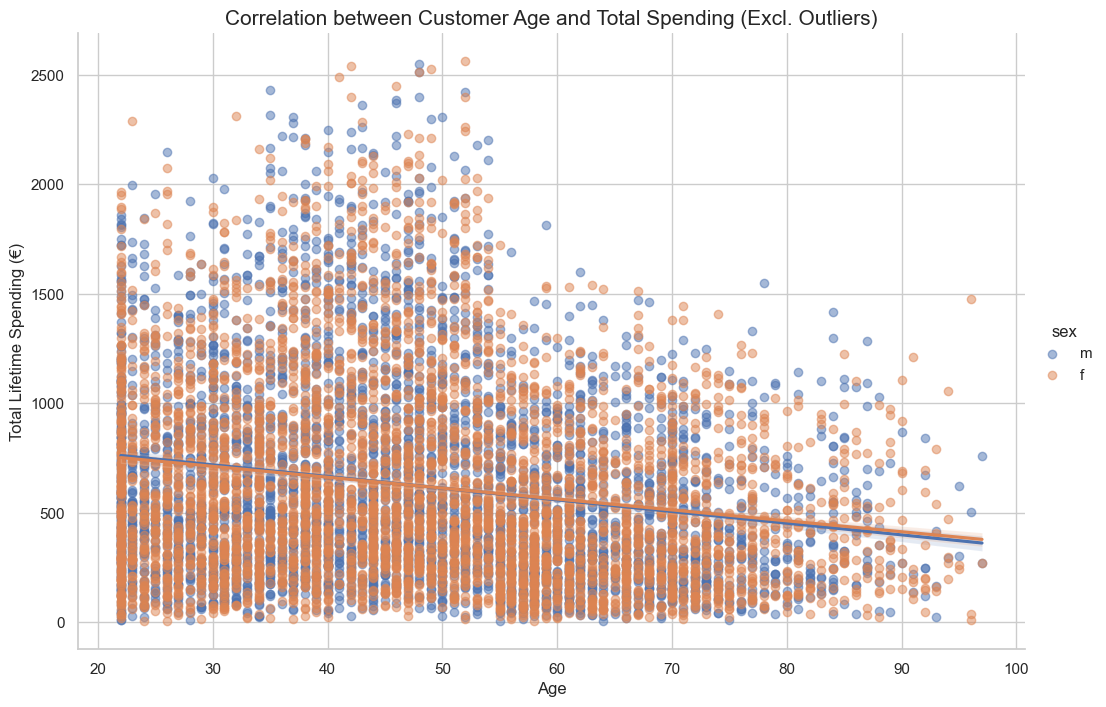

In [47]:
# 1. Correlation Analysis: Session Basket Amount vs. Age
# Creating a subset for session-level correlation
basket_age_price = df_ventes_panier_jour_1[["session_id", "age", "price"]].set_index("session_id")

# Calculate Empirical Covariance
# np.cov returns a matrix; [1,0] is the covariance between the two variables
emp_cov = np.cov(df_ventes_panier_jour_1["age"], df_ventes_panier_jour_1["price"], ddof=0)[1, 0]

print("--- Statistical Analysis: Age vs. Basket Amount ---")
print(f"Empirical Covariance: {emp_cov:.2f}")
print("A negative covariance suggests that as age increases, the session basket amount tends to decrease.")

# Correlation Matrices
print("\nCovariance Matrix:")
print(basket_age_price.cov())

print("\nPearson Correlation Matrix:")
print(basket_age_price.corr(method='pearson'))

# Pearson Correlation Coefficient and P-Value
pearson_coef, p_val = st.pearsonr(df_ventes_panier_jour_1["age"], df_ventes_panier_jour_1["price"])
print(f"\nPearson Correlation Coefficient: {pearson_coef:.4f}")
print(f"P-Value: {p_val:.4e}")

# 2. Visualization: Total Spending vs. Age (Client Level)
# Using the summary dataframe and filtering out extreme outliers (B2B clients)
# We use 'total_spent' (previously 'depenses')
customers_no_outliers = customer_spending_summary[customer_spending_summary['total_spent'] < 20000]

# Linear Model Plot (Regression)
sns.set_style("whitegrid")
g = sns.lmplot(
    x='age', 
    y='total_spent', 
    data=customers_no_outliers, 
    hue="sex", 
    height=7, 
    aspect=1.5,
    scatter_kws={'alpha':0.5}
)

# Formatting the Chart
plt.title("Correlation between Customer Age and Total Spending (Excl. Outliers)", fontsize=15)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Total Lifetime Spending (€)", fontsize=12)

print("\n--- Regression Analysis ---")
print("Result after removing outliers (> 20k€):")
plt.show()

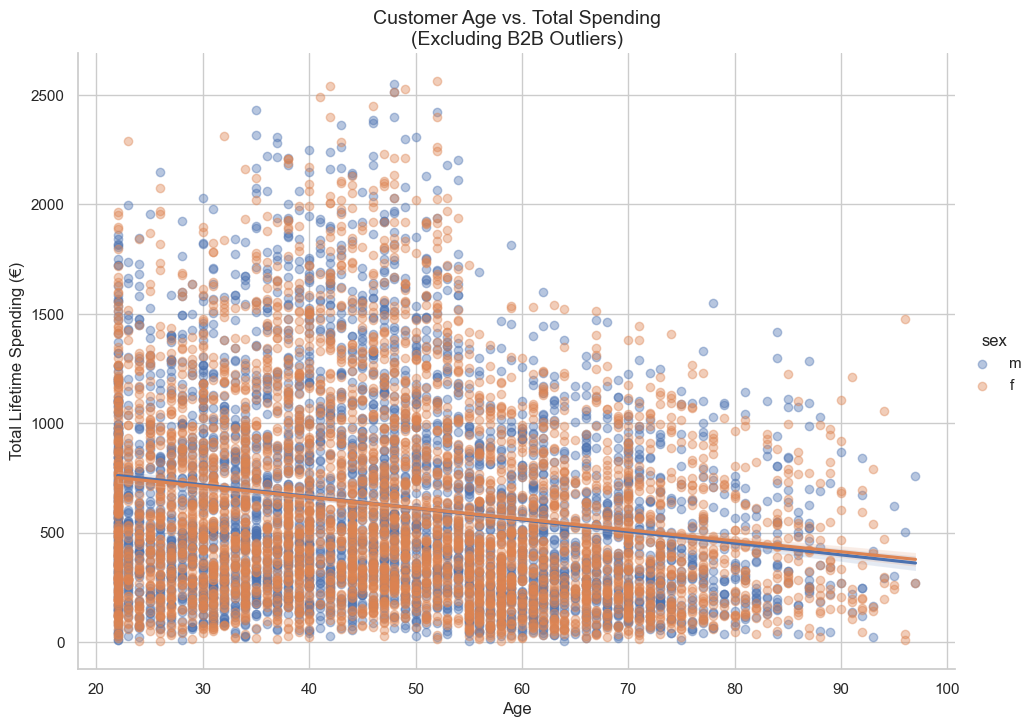

--- Data Cleaning Summary ---
Total customers: 8600
Remaining customers after exclusion: 8596


In [48]:
# 1. Define Outlier Thresholds
MAX_SPENDING_THRESHOLD = 20000
MAX_MONTHLY_FREQ_THRESHOLD = 100

# 2. Filter Customer Summary (Spending Analysis)
customer_spending_clean = customer_spending_summary[
    customer_spending_summary['total_spent'] < MAX_SPENDING_THRESHOLD
].copy()

# 3. Filter Session Data (Frequency Analysis)
df_freq_clean = df_ventes_panier_jour_1[
    df_ventes_panier_jour_1['monthly_frequency'] < MAX_MONTHLY_FREQ_THRESHOLD
].copy()

# 4. Visualization: Spending vs. Age (No Outliers)
sns.set_style("whitegrid")
g1 = sns.lmplot(
    x='age', 
    y='total_spent', 
    data=customer_spending_clean, 
    hue="sex", 
    height=7, 
    aspect=1.4, 
    scatter_kws={'alpha':0.4}
)
plt.title("Customer Age vs. Total Spending\n(Excluding B2B Outliers)", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Total Lifetime Spending (€)")
plt.show()


# 6. Final Clean Summary
print(f"--- Data Cleaning Summary ---")
print(f"Total customers: {len(customer_spending_summary)}")
print(f"Remaining customers after exclusion: {len(customer_spending_clean)}")

--- Analysis Results (Excluding Outliers) ---


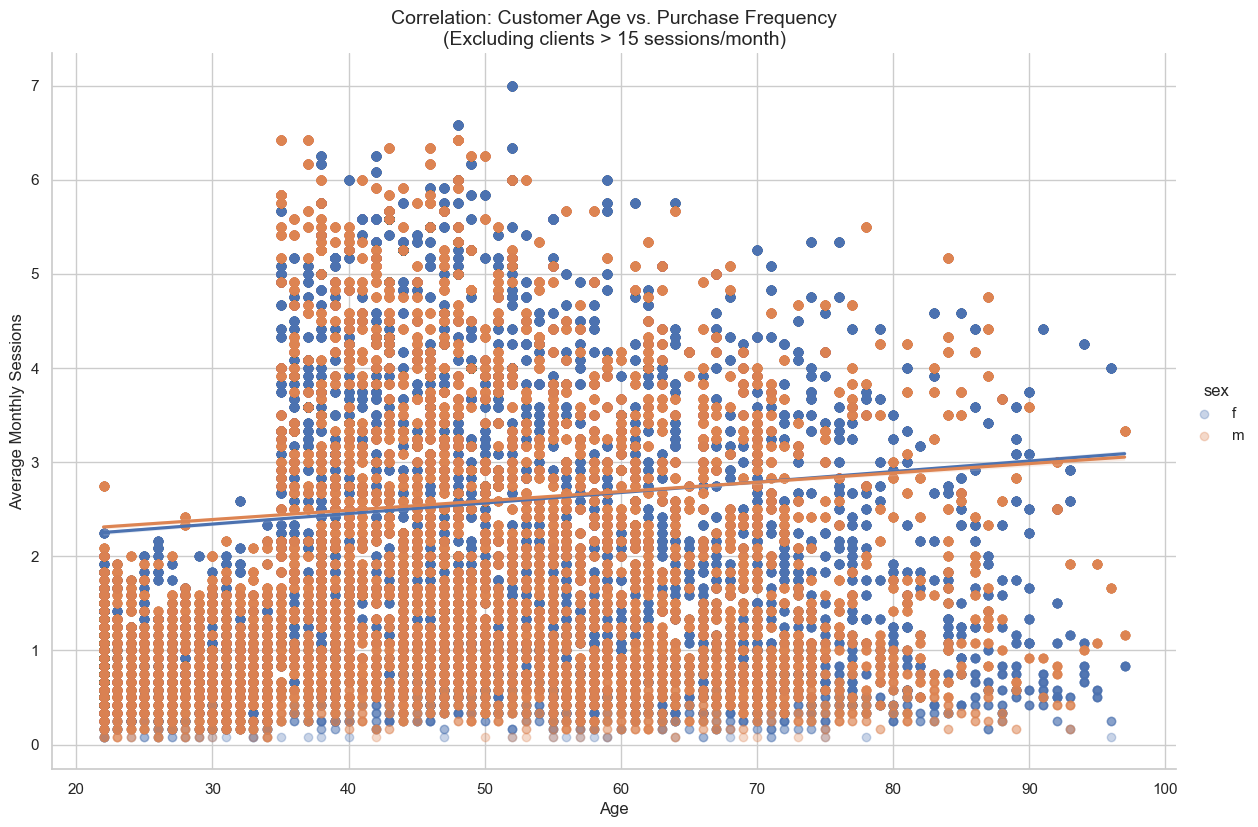

Empirical Covariance (Age vs Frequency): 2.4167
Pearson Correlation Coefficient: 0.1054
Observation: There is a positive correlation (0.11).
As age increases, purchase frequency tends to increase.


In [49]:
# 1. Calculate Monthly Purchase Frequency
# Count sessions per client and divide by 12 (as per your original code logic)
client_session_counts = df_ventes_panier_jour_1.groupby('client_id')['session_id'].count().reset_index()
client_session_counts.columns = ['client_id', 'session_count']
client_session_counts['monthly_frequency'] = client_session_counts['session_count'] / 12

# 2. Merge frequency back to the main session-level dataframe
# We drop the old columns if they exist to avoid duplicates during the merge
if 'monthly_frequency' in df_ventes_panier_jour_1.columns:
    df_ventes_panier_jour_1 = df_ventes_panier_jour_1.drop(columns=['monthly_frequency', 'session_count'], errors='ignore')

df_ventes_panier_jour_1 = pd.merge(df_ventes_panier_jour_1, client_session_counts, on="client_id", how="left")

# 3. Filter Outliers
# Specifically excluding clients with more than 15 purchases per month
df_freq_no_outliers = df_ventes_panier_jour_1[df_ventes_panier_jour_1['monthly_frequency'] <= 15].copy()

# 4. Visualization: Correlation between Age and Purchase Frequency
sns.set_style("whitegrid")
g = sns.lmplot(
    x='age', 
    y='monthly_frequency', 
    data=df_freq_no_outliers, 
    hue="sex",
    height=8, 
    aspect=1.5,
    scatter_kws={'alpha': 0.3}
)

plt.title("Correlation: Customer Age vs. Purchase Frequency\n(Excluding clients > 15 sessions/month)", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Average Monthly Sessions", fontsize=12)

print("--- Analysis Results (Excluding Outliers) ---")
plt.show()

# 5. Statistical Calculations
# We calculate statistics on the filtered data to see the true trend for standard customers
clean_stats = df_freq_no_outliers[['age', 'monthly_frequency']].dropna()

# Empirical Covariance
empirical_cov = np.cov(clean_stats["age"], clean_stats["monthly_frequency"], ddof=0)[1, 0]

# Pearson Correlation
correlation_coef, p_value = st.pearsonr(clean_stats["age"], clean_stats["monthly_frequency"])

print(f"Empirical Covariance (Age vs Frequency): {empirical_cov:.4f}")
print(f"Pearson Correlation Coefficient: {correlation_coef:.4f}")

# Interpretation logic
if correlation_coef < 0:
    print(f"Observation: There is a negative correlation ({correlation_coef:.2f}).")
    print("As age increases, purchase frequency tends to decrease.")
else:
    print(f"Observation: There is a positive correlation ({correlation_coef:.2f}).")
    print("As age increases, purchase frequency tends to increase.")

--- Analysis Results ---
Pearson Correlation Coefficient: -0.2284
Confirmation: As age increases, the number of items per basket decreases.


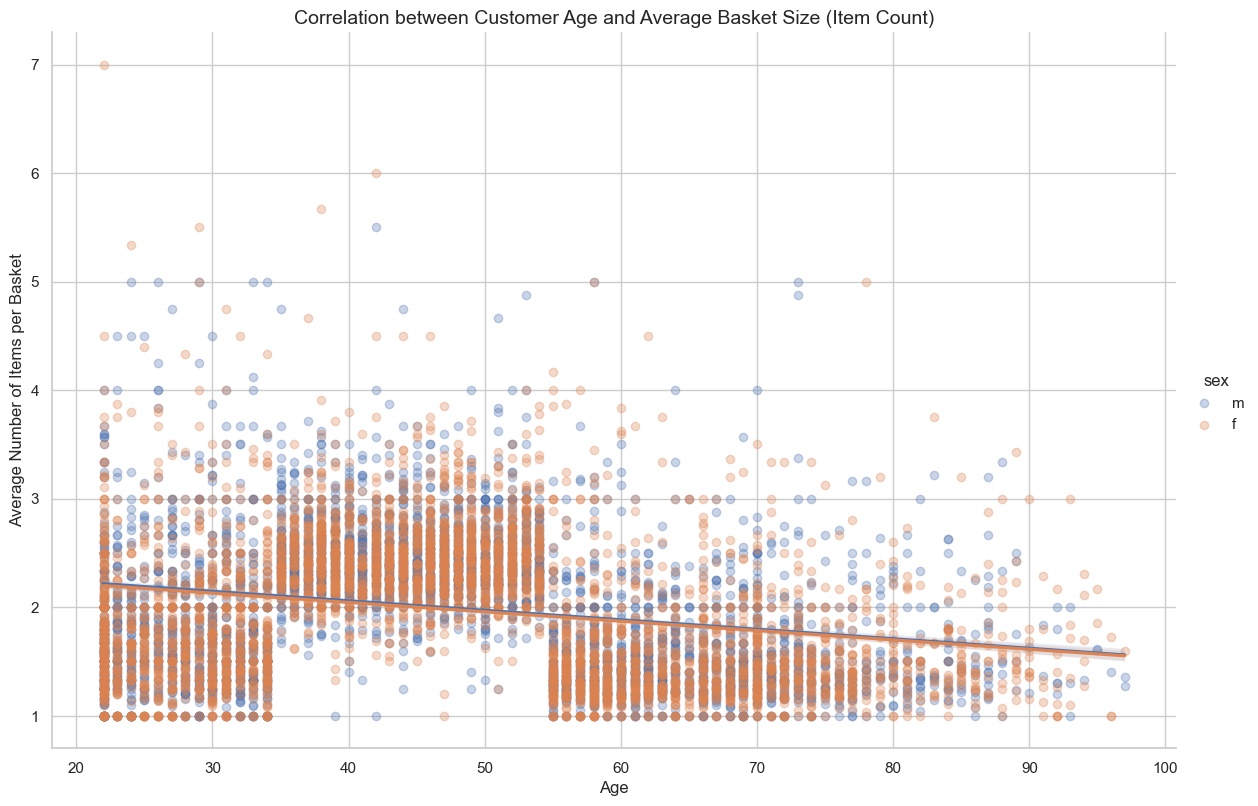

In [50]:
# 1. Data Selection
df_daily_sales = df[["client_id", "session_id", "sex", "age", "price"]]

# 2. Filter B2B Outliers
b2b_outliers = ['c_1609', 'c_4958', 'c_6714', 'c_3454']
df_filtered_sales = df_daily_sales[~df_daily_sales['client_id'].isin(b2b_outliers)].copy()

# 3. Calculate Average Basket Size (Corrected to include 'sex')
# First: Count items per session
session_item_counts = (
    df_filtered_sales.groupby(['client_id', 'session_id', 'age', 'sex'])
    .size()
    .reset_index(name='items_in_basket')
)

# Second: Average those counts per client (keeping age and sex)
avg_basket_size = (
    session_item_counts.groupby(['client_id', 'age', 'sex'])['items_in_basket']
    .mean()
    .reset_index(name='avg_items_per_basket')
)

# 4. Visualization
sns.set_style("whitegrid")
g = sns.lmplot(
    x='age', 
    y='avg_items_per_basket', 
    data=avg_basket_size, 
    hue="sex",  # Now 'sex' exists in the dataframe!
    height=8, 
    aspect=1.5,
    scatter_kws={'alpha': 0.3}
)

plt.title("Correlation between Customer Age and Average Basket Size (Item Count)", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Average Number of Items per Basket")

# 5. Statistics
pearson_corr, _ = st.pearsonr(avg_basket_size["age"], avg_basket_size["avg_items_per_basket"])

print("--- Analysis Results ---")
print(f"Pearson Correlation Coefficient: {pearson_corr:.4f}")
if pearson_corr < 0:
    print("Confirmation: As age increases, the number of items per basket decreases.")

plt.show()

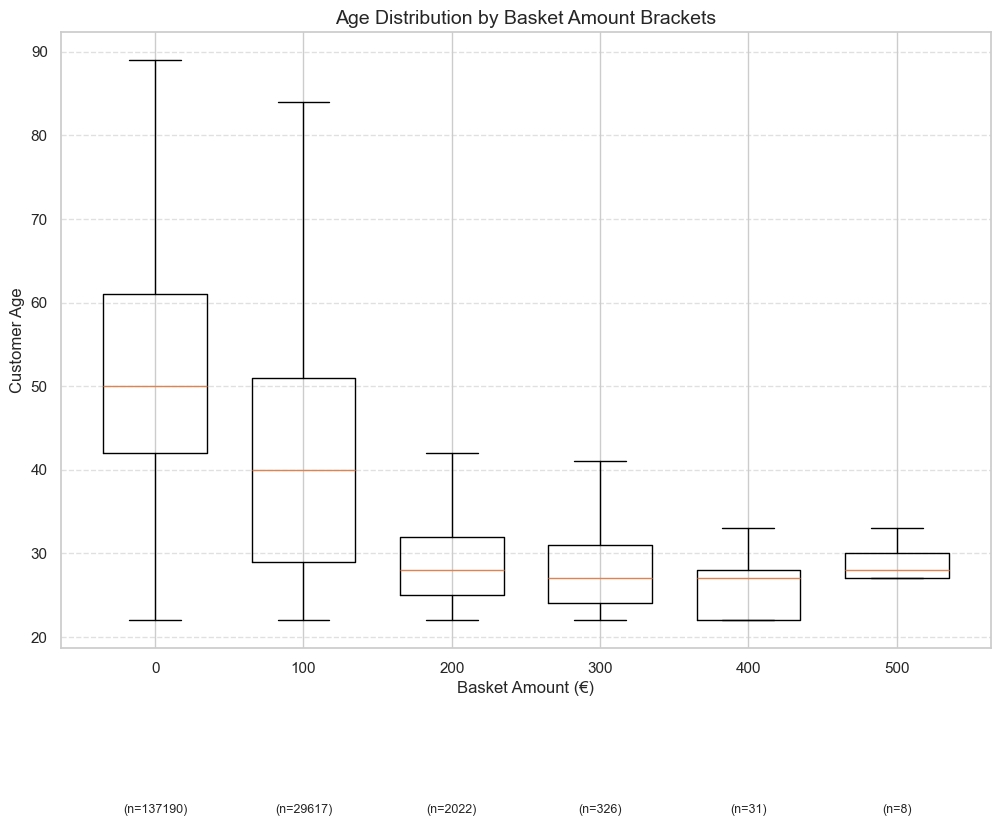

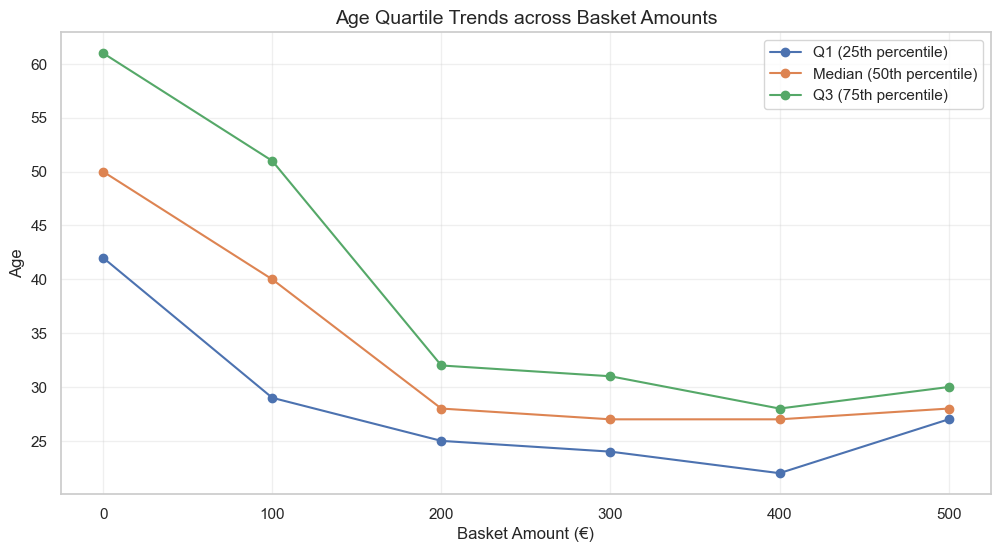

Analysis Summary:
The data was divided into 6 price brackets of 100€ each.
The charts show if older or younger customers tend to spend more per session.


In [51]:
# 1. Configuration for Discretization
bin_size = 100  # Size of the price brackets (e.g., 0-100€, 100-200€)
groups = []     # List to store aggregated data for plotting

# 2. Creating Price Brackets (Bins)
# Generate ranges from 0 to the maximum basket price
bins = np.arange(0, max(df_ventes_panier_jour_1["price"]), bin_size)
bins += bin_size / 2  # Shift bins by half size for centering
indices = np.digitize(df_ventes_panier_jour_1["price"], bins) # Assign each basket to a bin index

# 3. Aggregating Age Data per Price Bracket
for index, bracket_center in enumerate(bins):
    # Select ages of customers whose basket price falls into the current bracket
    ages_in_bracket = df_ventes_panier_jour_1.loc[indices == index, "age"]
    
    if len(ages_in_bracket) > 0:
        groups.append({
            'values': ages_in_bracket,
            'bin_center': bracket_center - (bin_size / 2),
            'count': len(ages_in_bracket),
            'quartiles': [np.percentile(ages_in_bracket, p) for p in [25, 50, 75]]
        })

# 4. Visualization: Boxplots per Price Bracket
plt.figure(figsize=[12, 8])

# Drawing boxplots to show age distribution for each price level
plt.boxplot(
    [g["values"] for g in groups],
    positions=[g["bin_center"] for g in groups],
    showfliers=False,           # Hide outliers for visual clarity
    widths=bin_size * 0.7,      # Width of the boxes
    manage_ticks=False
)

# Display sample size (n) for each bracket
for g in groups:
    plt.text(
        g["bin_center"], 0, f"(n={g['count']})", 
        horizontalalignment='center', verticalalignment='top', fontsize=9
    )

plt.title('Age Distribution by Basket Amount Brackets', fontsize=14)
plt.xlabel('Basket Amount (€)', fontsize=12)
plt.ylabel('Customer Age', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 5. Visualization: Quartile Trends
plt.figure(figsize=[12, 6])

quartile_labels = ['Q1 (25th percentile)', 'Median (50th percentile)', 'Q3 (75th percentile)']
for i in range(3):
    plt.plot(
        [g["bin_center"] for g in groups],
        [g["quartiles"][i] for g in groups],
        label=quartile_labels[i],
        marker='o'
    )

plt.title('Age Quartile Trends across Basket Amounts', fontsize=14)
plt.xlabel('Basket Amount (€)', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary Output
print("Analysis Summary:")
print(f"The data was divided into {len(groups)} price brackets of {bin_size}€ each.")
print("The charts show if older or younger customers tend to spend more per session.")

## 6.5 Pareto Analysis


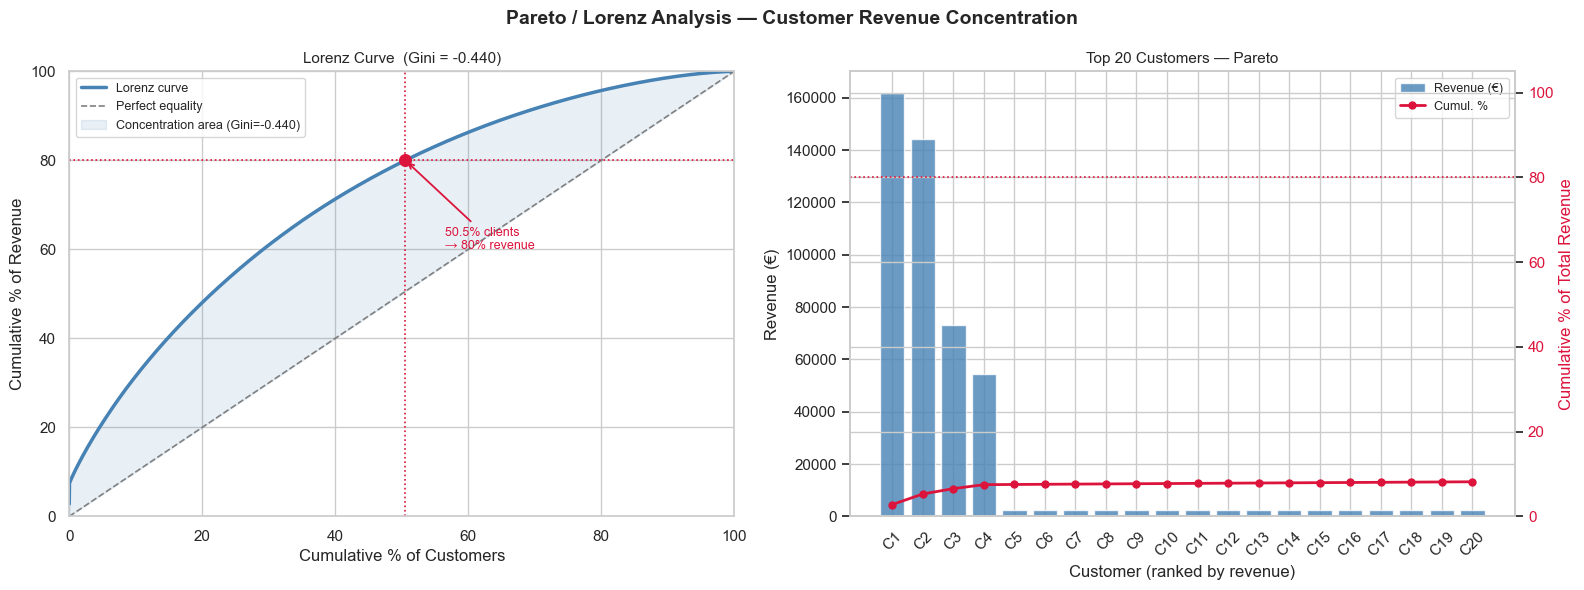


📊 Gini coefficient              : -0.440
   Top 50.5% of clients → 80% revenue
   Top 20 clients → 8.2% total revenue


In [52]:
# ═══════════════════════════════════════════════════════════════
# 6.5  Pareto / Lorenz Analysis  — improved visualisation
# ═══════════════════════════════════════════════════════════════
import numpy as np

customer_sales = df.groupby('client_id')['price'].sum().sort_values(ascending=False)
n            = len(customer_sales)
total_rev    = customer_sales.sum()

cum_pct_clients = np.linspace(0, 1, n)
cum_pct_revenue = customer_sales.cumsum().values / total_rev

# 80/20 crossover
idx_80             = np.searchsorted(cum_pct_revenue, 0.80)
pct_clients_for_80 = idx_80 / n * 100

# Gini coefficient
gini = 1 - 2 * np.trapz(cum_pct_revenue, cum_pct_clients)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Pareto / Lorenz Analysis — Customer Revenue Concentration",
             fontsize=14, fontweight='bold')

# ── Left: Lorenz curve ───────────────────────────────────────
ax = axes[0]
ax.plot(cum_pct_clients * 100, cum_pct_revenue * 100,
        color='steelblue', linewidth=2.5, label='Lorenz curve')
ax.plot([0, 100], [0, 100], '--', color='grey', linewidth=1.2, label='Perfect equality')
ax.fill_between(cum_pct_clients * 100, cum_pct_revenue * 100,
                cum_pct_clients * 100, alpha=0.12, color='steelblue',
                label=f'Concentration area (Gini={gini:.3f})')
# 80/20 annotation
ax.axhline(80, color='crimson', linestyle=':', linewidth=1.2)
ax.axvline(pct_clients_for_80, color='crimson', linestyle=':', linewidth=1.2)
ax.scatter([pct_clients_for_80], [80], color='crimson', zorder=5, s=70)
ax.annotate(f"{pct_clients_for_80:.1f}% clients\n→ 80% revenue",
            xy=(pct_clients_for_80, 80),
            xytext=(pct_clients_for_80 + 6, 60),
            fontsize=9, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.3))
ax.set_title(f"Lorenz Curve  (Gini = {gini:.3f})", fontsize=11)
ax.set_xlabel("Cumulative % of Customers")
ax.set_ylabel("Cumulative % of Revenue")
ax.legend(fontsize=9); ax.set_xlim(0, 100); ax.set_ylim(0, 100)

# ── Right: Pareto bar (top 20) ───────────────────────────────
ax2 = axes[1]
top_n       = 20
top_clients = customer_sales.head(top_n).reset_index()
top_clients.columns = ['client_id', 'revenue']
top_clients['label']   = [f"C{i+1}" for i in range(top_n)]
top_clients['cum_pct'] = top_clients['revenue'].cumsum() / total_rev * 100

ax2.bar(top_clients['label'], top_clients['revenue'],
        color='steelblue', alpha=0.8, label='Revenue (€)')
ax2_r = ax2.twinx()
ax2_r.plot(top_clients['label'], top_clients['cum_pct'],
           color='crimson', marker='o', linewidth=2, markersize=5, label='Cumul. %')
ax2_r.axhline(80, color='crimson', linestyle=':', linewidth=1.2)
ax2_r.set_ylabel("Cumulative % of Total Revenue", color='crimson')
ax2_r.tick_params(axis='y', labelcolor='crimson'); ax2_r.set_ylim(0, 105)
ax2.set_title(f"Top {top_n} Customers — Pareto", fontsize=11)
ax2.set_xlabel("Customer (ranked by revenue)"); ax2.set_ylabel("Revenue (€)")
ax2.tick_params(axis='x', rotation=45)
h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2_r.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, fontsize=9)

plt.tight_layout()
plt.savefig('pareto_lorenz.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Gini coefficient              : {gini:.3f}")
print(f"   Top {pct_clients_for_80:.1f}% of clients → 80% revenue")
print(f"   Top {top_n} clients → {top_clients['cum_pct'].iloc[-1]:.1f}% total revenue")


# 7. Anomaly Detection

## 7.1 Checking Missing Days

In [53]:
sales_daily = df.groupby("date")["revenue"].sum().reset_index()

missing_days = sales_daily[sales_daily["revenue"] == 0]

if missing_days.empty:
    print("No missing sales days detected (no days with zero revenue).")
else:
    print(f"{len(missing_days)} day(s) with zero revenue detected:")
    display(missing_days.head())

No missing sales days detected (no days with zero revenue).


## 7.2 October Drop Analysis

### Overal October Revenue Vs Average Monthly Revenue 

October revenue (avg): 319242
Other months revenue (avg): 498049


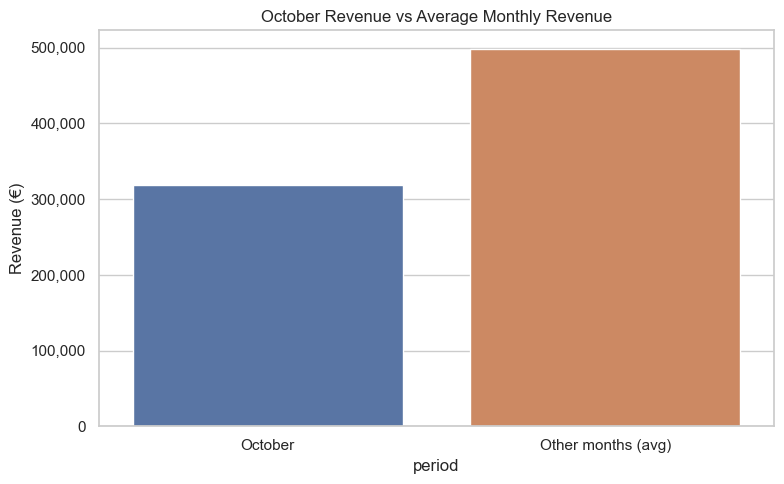

In [54]:
# Revenue by month
df['month'] = df['date'].dt.month
monthly = df.groupby(df['date'].dt.to_period('M'))['revenue'].sum()

# Average revenue excluding October
oct_value = monthly[monthly.index.month == 10].mean()
avg_other = monthly[monthly.index.month != 10].mean()

print("October revenue (avg):", round(oct_value))
print("Other months revenue (avg):", round(avg_other))

comparison_df = pd.DataFrame({
    'period': ['October', 'Other months (avg)'],
    'revenue': [oct_value, avg_other]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=comparison_df, x='period', y='revenue', hue='period', legend=False)
plt.title("October Revenue vs Average Monthly Revenue")
plt.ylabel("Revenue (€)")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


### October Revenue per Category

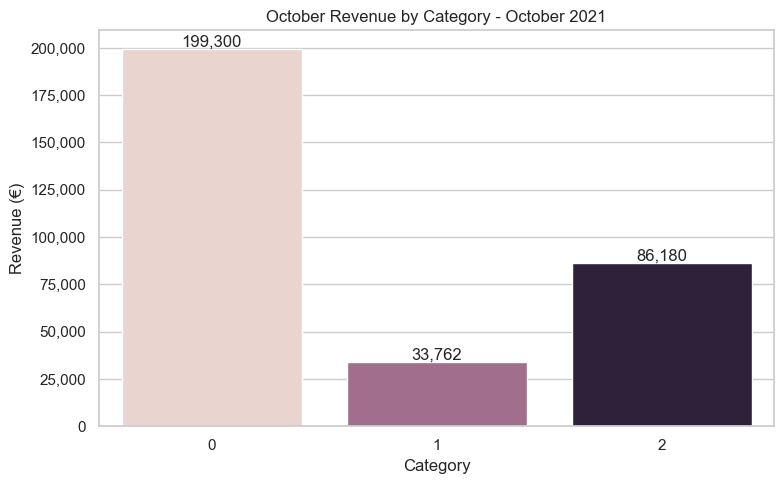

In [55]:
sales_october = df[df["month"] == 10]
sales_october.groupby("categ")["revenue"].sum()

sales_october = df[df['year_month'] == '2021-10'] \
    .groupby('categ')['price'] \
    .sum() \
    .reset_index()

sales_october['categ'] = sales_october['categ'].astype(int)

plt.figure(figsize=(8,5))

ax = sns.barplot( data=sales_october, x='categ', y='price', hue='categ',  legend=False )

ax.yaxis.set_major_formatter( ticker.FuncFormatter(lambda x, _: f'{x:,.0f}') )

# Add labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom'
    )

plt.title("October Revenue by Category - October 2021")
plt.xlabel("Category")
plt.ylabel("Revenue (€)")

plt.tight_layout()
plt.show()

### Category Revenue Comparison: October Revenue vs Average Revenue by Category

October revenue by category:
   year_month categ          price
21    2021-10     0  199300.069562
22    2021-10     1   33762.320000
23    2021-10     2   86179.700000

Category Revenue Difference between October vs average:

        October  Average_other_months  difference
categ                                            
0      199300.0              184694.0     14606.0
1       33762.0              201238.0   -167476.0
2       86180.0              112117.0    -25938.0 



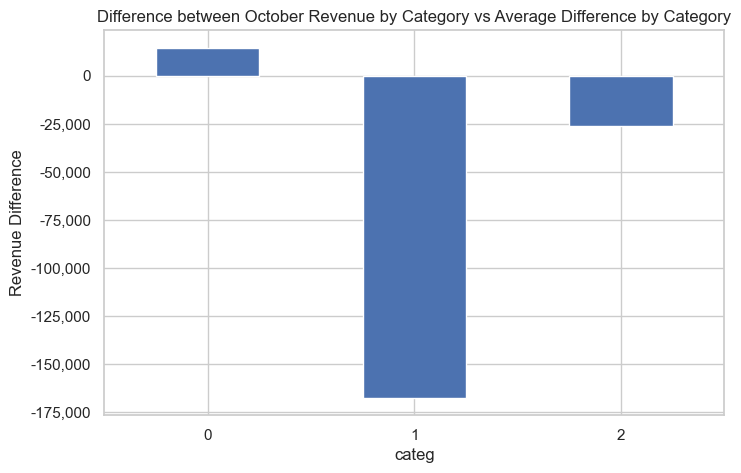

In [56]:
october_data = sales_by_cat[sales_by_cat['year_month'].str.contains('-10')]

print("October revenue by category:")
print(october_data)

# Comparison vs the monthly average (excluding October)
avg_by_cat = (
    sales_by_cat[~sales_by_cat['year_month'].str.contains('-10')]
    .groupby('categ')['price']
    .mean()
)

oct_by_cat = october_data.set_index('categ')['price']

comparison = pd.DataFrame({
    'October': oct_by_cat,
    'Average_other_months': avg_by_cat
})

comparison['difference'] = comparison['October'] - comparison['Average_other_months']

print("\nCategory Revenue Difference between October vs average:\n")
print(round(comparison), "\n")



comparison['difference'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Difference between October Revenue by Category vs Average Difference by Category")
plt.ylabel("Revenue Difference")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.show()

**Category 1 revenue is far below its average monthly revenue**

### Category 1 October Sales

In [57]:
cat1_count = df[df['categ'] == 1].groupby('year_month').size()

# average price 
cat1_price = df[df['categ'] == 1].groupby('year_month')['price'].mean()

print("Category 1 count: ", cat1_count.loc['2021-10'])
print("Category 1 average price: ", round(cat1_price.loc['2021-10']))

Category 1 count:  1666
Category 1 average price:  20


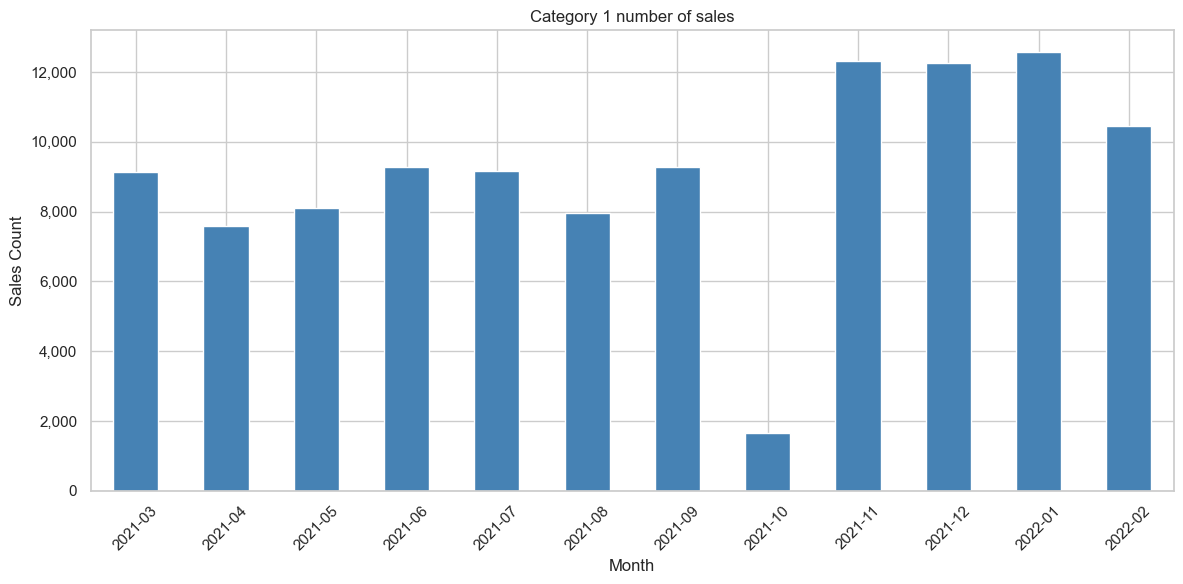

In [58]:
cat_1_data = df[df['categ'] == 1].groupby('year_month').size()

# 3. Plotting
plt.figure(figsize=(12, 6))

ax = cat_1_data.plot.bar(
    color='steelblue', 
    title='Category 1 number of sales'
)

# 4. Formatting
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.ylabel("Sales Count")
plt.xlabel("Month")

plt.tight_layout()
plt.show()

### Daily Revenue in October - Category 1

Category 1 Daily Revenue in October:
date
2021-10-01 00:03:07.095422    17.41
2021-10-01 00:03:16.664480    19.96
2021-10-01 00:15:08.771899    18.99
2021-10-01 00:21:30.028255    12.99
2021-10-01 00:21:41.000160    15.99
Name: price, dtype: float64


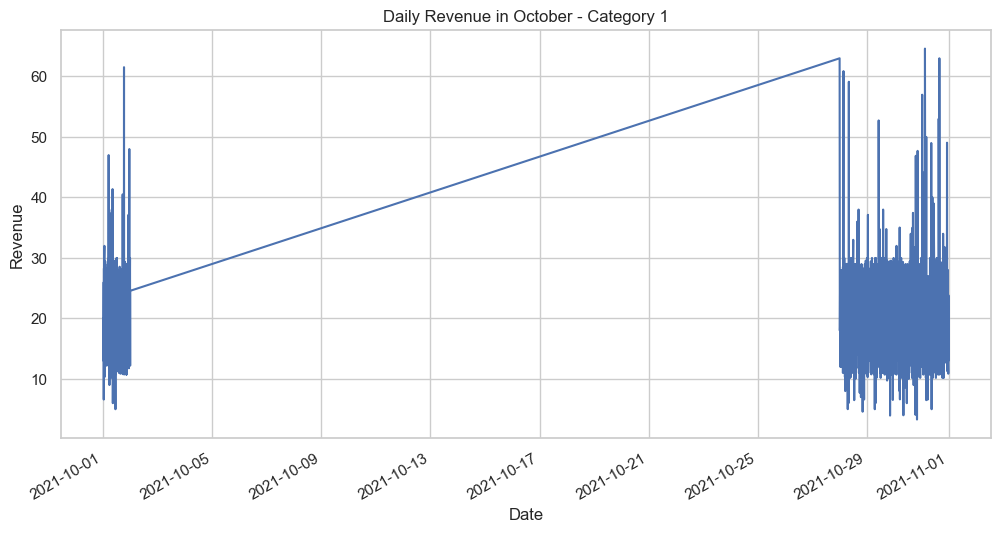

In [59]:
october_daily = (
    df[(df['month'] == 10) & (df['categ'] == 1)]
    .groupby('date')['price']
    .sum()
)

print("Category 1 Daily Revenue in October:")
print(october_daily.head())

october_daily.plot()

plt.title("Daily Revenue in October - Category 1")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

**/!\ No Category 1 sales for most of October** 

### Category 1 Number of Sessions

Category 1 number of sessions:  1294


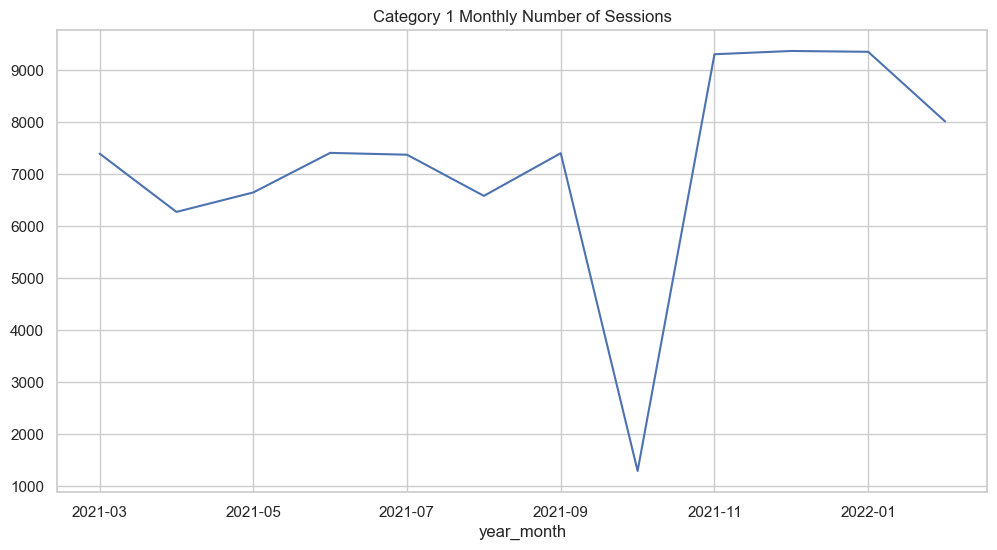

In [60]:
cat1_sessions = (
    df[df['categ'] == 1]
    .groupby('year_month')['session_id']
    .nunique()
)

print("Category 1 number of sessions: ", cat1_sessions.loc['2021-10'])

cat1_sessions.plot()
plt.title("Category 1 Monthly Number of Sessions")
plt.show()

### 26 days of missing sales for Category 1 products

Category 1 sessions in October:
date
2021-10-01    271
2021-10-28    252
2021-10-29    258
2021-10-30    259
2021-10-31    257
Name: session_id, dtype: int64


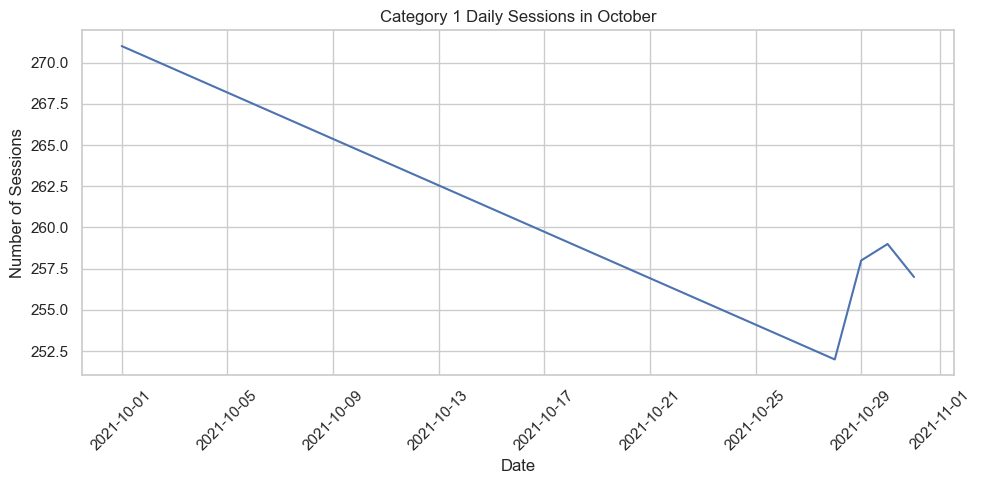

In [61]:
# Ensure datetime
df['date'] = pd.to_datetime(df['date'])

cat1_sessions = (
    df[
        (df['date'].dt.month == 10) &
        (df['categ'] == 1)
    ]
    .groupby(df['date'].dt.date)['session_id']
    .nunique()
)

print("Category 1 sessions in October:")
print(cat1_sessions.head())

plt.figure(figsize=(10,5))
plt.plot(cat1_sessions.index, cat1_sessions.values)

plt.xlabel("Date")
plt.ylabel("Number of Sessions")
plt.title("Category 1 Daily Sessions in October")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('')

**/!\ No Category 1 sessions for most of October** 

### Average Basket Price per Month

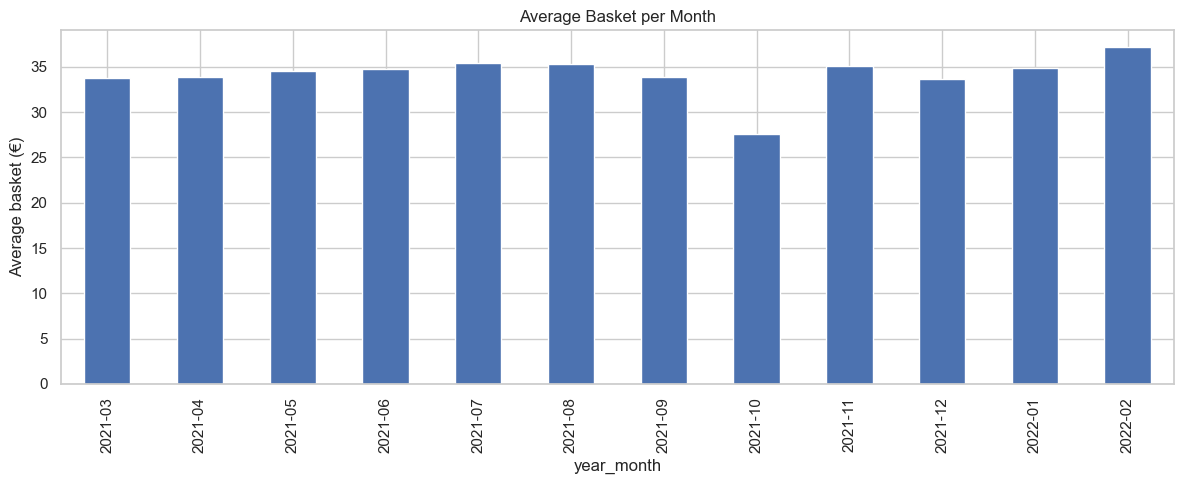

In [62]:
# Revenue per session
session_revenue = (
    df.groupby('session_id')['price'].sum().reset_index()
)

# Add the month for each session
session_month = df.groupby('session_id')['year_month'].first().reset_index()
session_revenue = session_revenue.merge(session_month, on='session_id')

# Average basket per month
avg_basket = session_revenue.groupby('year_month')['price'].mean()
avg_basket.plot(kind='bar', figsize=(12, 5))
plt.title("Average Basket per Month")
plt.ylabel("Average basket (€)")
plt.tight_layout()
plt.show()


### Active Clients per Month

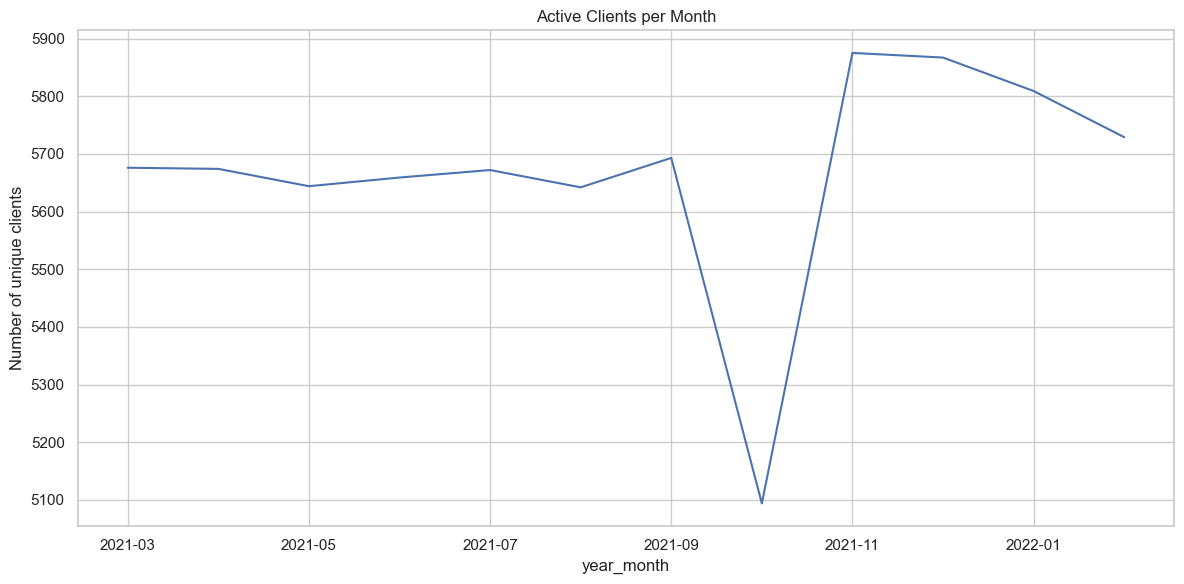

In [63]:
# Active clients per month
active_clients = df.groupby('year_month')['client_id'].nunique()
active_clients.plot()
plt.title("Active Clients per Month")
plt.ylabel("Number of unique clients")
plt.tight_layout()
plt.show()


## Statistical Tests

### October vs Rest Test

In [64]:
october = df[df['month'] == 10]['price']
others = df[df['month'] != 10]['price']


t_stat, p_val = stats.ttest_ind(october, others, equal_var=False)

print("T-test:", t_stat, p_val)

T-test: -20.956032826886705 1.1435477631556687e-96


In [65]:
group1 = df[df['sex']=='m']['price'].dropna()
group2 = df[df['sex']=='f']['price'].dropna()


stats.ttest_ind(group1, group2)

TtestResult(statistic=4.77354233224658, pvalue=1.8108927863789037e-06, df=336814.0)

In [66]:
mean_m = group1.mean()
mean_f = group2.mean()

print(mean_m, mean_f, mean_m - mean_f)

17.359626273591967 17.065945025675926 0.2936812479160409


### October Sales Drop Analysis

We investigate the drop in sales observed in October.

1. Revenue analysis shows a significant decrease compared to other months.

2. Traffic analysis:
- If sessions also decrease → traffic issue
- If stable → conversion issue

3. Basket analysis:
- Lower average basket → reduced customer spending

4. Category breakdown:
- Identify if drop is category-specific or global

5. Customer activity:
- Fewer active users → retention/acquisition issue

Conclusion:
The root cause of the October drop is identified by combining:
- traffic (sessions)
- conversion (basket size)
- product mix (categories)

### Root Cause Analysis – October Sales Drop

The October sales decline is driven by a sharp drop in category 1 performance.

Key findings:
- Category 1 sessions dropped by ~80% (from ~7000 to 1294)
- Transaction volume followed the same pattern
- Average price remained stable (~20€)

Conclusion:
The drop is caused by a traffic decrease, not by pricing or customer behavior.

Business interpretation:
This suggests an operational or acquisition issue affecting category 1:
- stock unavailability
- product removal
- tracking issue
- marketing disruption

This is not a demand problem, but a supply or visibility issue.

# 8. Customer Analysis
## 8.1 Revenue per User

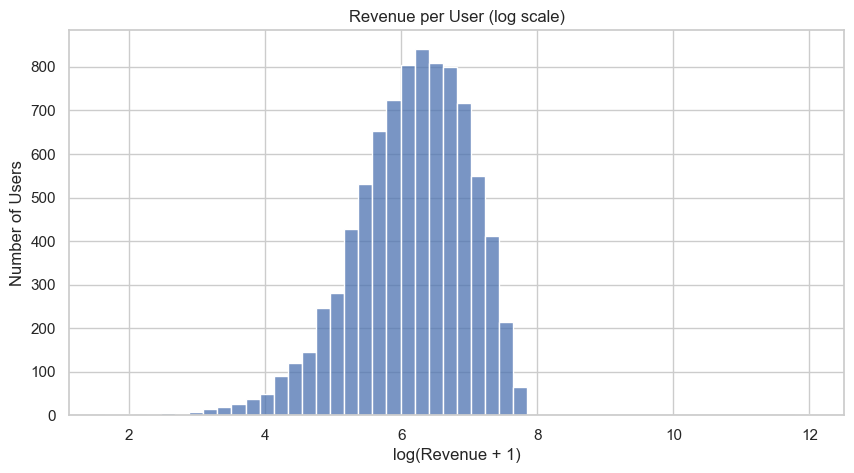

Average revenue per user: 674.16
Median revenue per user: 501.35


In [67]:
user_revenue = (
    df.groupby('client_id')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'revenue'})
)


plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(user_revenue['revenue']),
    bins=50
)

plt.title("Revenue per User (log scale)")
plt.xlabel("log(Revenue + 1)")
plt.ylabel("Number of Users")

plt.show()



# Basic stats
print("Average revenue per user:", round(user_revenue['revenue'].mean(), 2))
print("Median revenue per user:", round(user_revenue['revenue'].median(), 2))

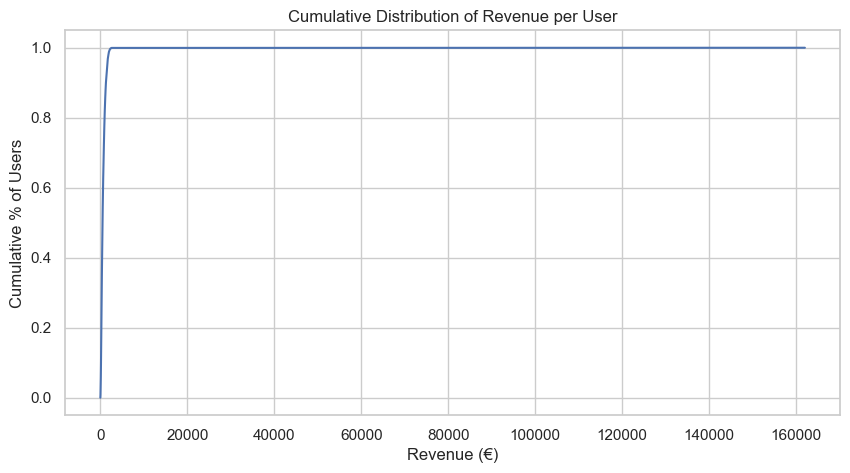

In [68]:
sorted_rev = np.sort(user_revenue['revenue'])
cdf = np.arange(len(sorted_rev)) / len(sorted_rev)

plt.figure(figsize=(10,5))
plt.plot(sorted_rev, cdf)

plt.title("Cumulative Distribution of Revenue per User")
plt.xlabel("Revenue (€)")
plt.ylabel("Cumulative % of Users")

plt.show()

## 8.2 Average Basket

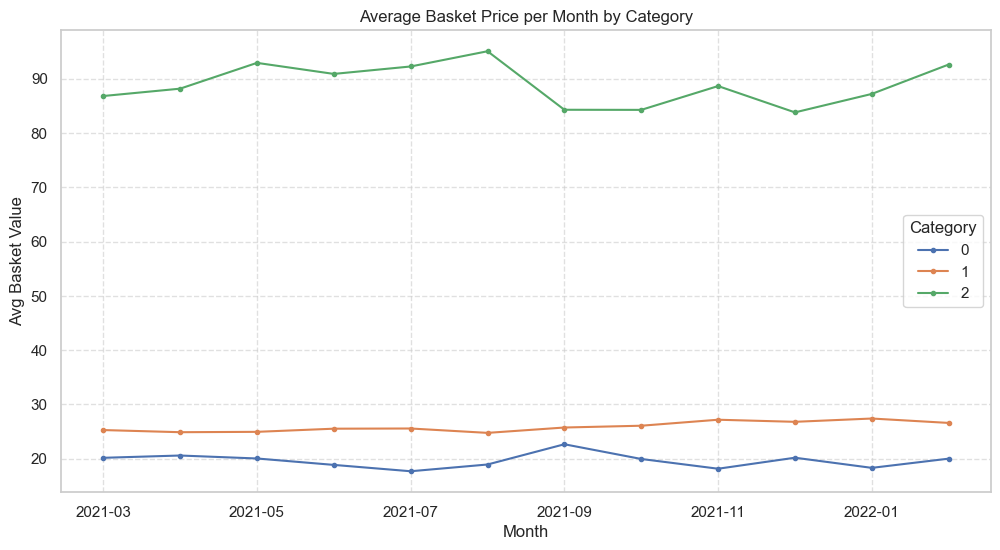

In [69]:
# 1. Group by Month, Session, AND Category to get revenue per specific cat
session_revenue = (df.groupby(['year_month', 'session_id', 'categ'])['price'] 
                   .sum()
                   .reset_index()
)

# 2. Now calculate the mean price per month AND per category
avg_basket_by_cat = (session_revenue.groupby(['year_month', 'categ'])['price']
                     .mean()
)

# 3. Unstack the 'categ' level to make each category its own column
# This is what tells Pandas to draw a separate line for each category
pivot_avg = avg_basket_by_cat.unstack(level='categ')

# 4. Plot
pivot_avg.plot(figsize=(12, 6), marker='.') # Added marker for better visibility

plt.title("Average Basket Price per Month by Category")
plt.ylabel("Avg Basket Value")
plt.xlabel("Month")
plt.legend(title='Category')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

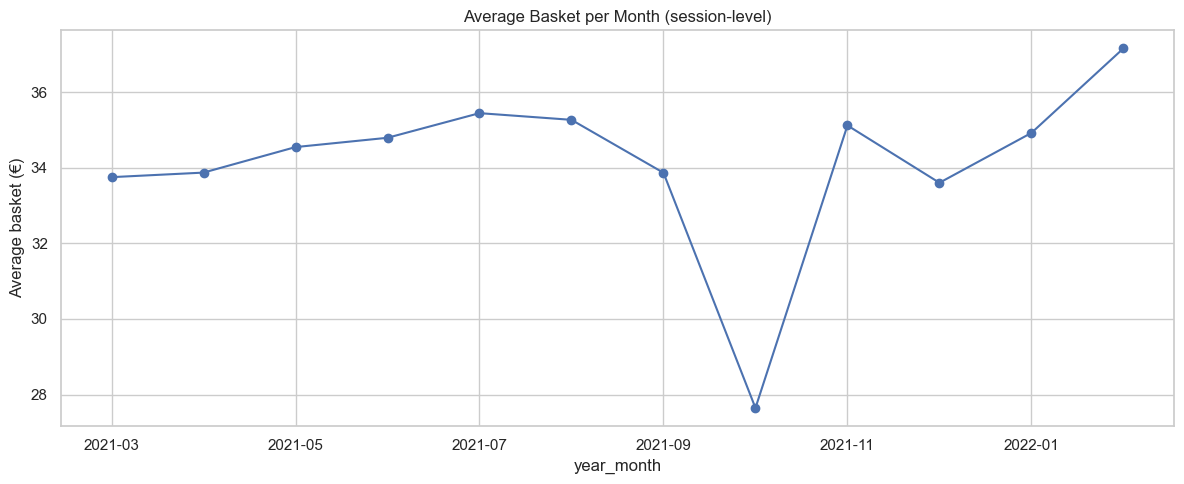

In [70]:
# Revenue per session
session_revenue = (
    df.groupby('session_id')['price'].sum().reset_index()
)
# Add the month
session_month = df.groupby('session_id')['year_month'].first().reset_index()
session_revenue = session_revenue.merge(session_month, on='session_id')
# Average basket per month
avg_basket = session_revenue.groupby('year_month')['price'].mean()
avg_basket.plot(figsize=(12, 5), marker='o')
plt.title("Average Basket per Month (session-level)")
plt.ylabel("Average basket (€)")
plt.tight_layout()
plt.show()


**The sharp decline in the total average basket during October is driven by a shift in product mix rather than a change in category pricing. Stable category-level trends confirm that customers simply purchased different product combinations rather than paying less for the same items.**

## 8.3 Purchases per User

Average purchases per user: 39.16
Median purchases per user: 25.0


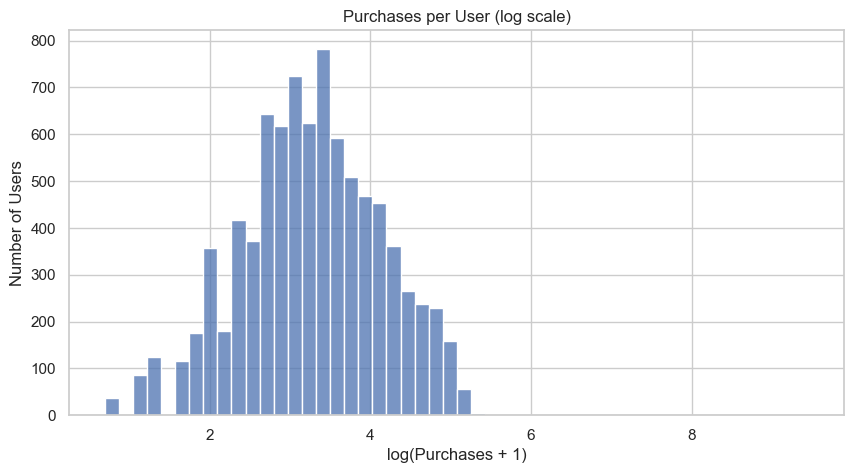

In [71]:
user_purchases = (
    df.groupby('client_id')
    .size()
    .reset_index(name='nb_purchases')
)

# Stats
print("Average purchases per user:", round(user_purchases['nb_purchases'].mean(), 2))
print("Median purchases per user:", round(user_purchases['nb_purchases'].median(), 2))

plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(user_purchases['nb_purchases']),
    bins=50
)

plt.title("Purchases per User (log scale)")
plt.xlabel("log(Purchases + 1)")
plt.ylabel("Number of Users")

plt.show()

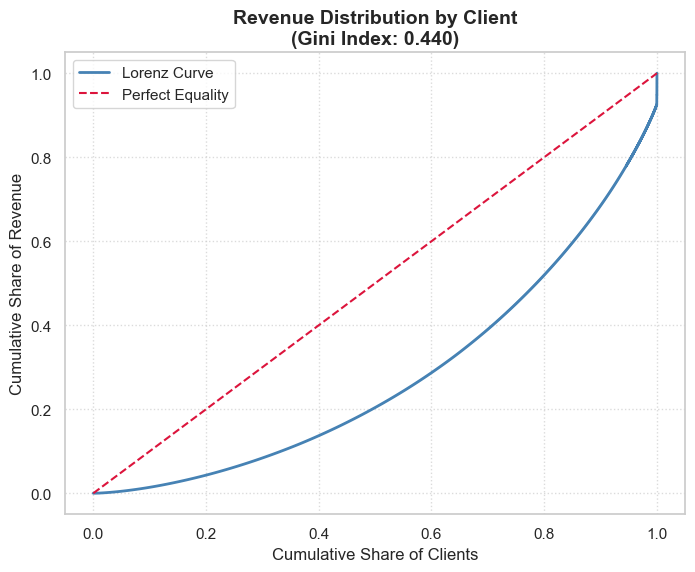

Gini Index: 0.4398
Total Revenue (CA) = 5,797,786.25 €


In [72]:
# 1. Calculate total Revenue (CA) per client
df_ca_client = df.groupby('client_id')['price'].sum().reset_index()

# 2. Prepare data for the Lorenz Curve
# We sort the values in ascending order to observe cumulative distribution
ca_values = df_ca_client['price'].values
n = len(ca_values)
lorenz = np.cumsum(np.sort(ca_values)) / ca_values.sum()
lorenz = np.append([0], lorenz) # The curve starts at the origin (0,0)

# 3. Gini Index Calculation
# Area under the Lorenz curve
area_under_curve = lorenz[:-1].sum() / n 
# S represents the area between the equality line and the Lorenz curve
S = 0.5 - area_under_curve 
gini = 2 * S

# 4. Plotting
plt.figure(figsize=(8, 6))

# X-axis: cumulative share of the population (from 0 to 1)
xaxis = np.linspace(0, 1, len(lorenz))

plt.plot(xaxis, lorenz, drawstyle='steps-post', label='Lorenz Curve', color='steelblue', lw=2)
plt.plot([0, 1], [0, 1], color='crimson', linestyle='--', label='Perfect Equality') # Bisector line

# Formatting
plt.title(f'Revenue Distribution by Client\n(Gini Index: {gini:.3f})', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Share of Revenue', fontsize=12)
plt.xlabel('Cumulative Share of Clients', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

print(f"Gini Index: {gini:.4f}")
print(f"Total Revenue (CA) = {df_ca_client['price'].sum():,.2f} €")

## 8.4 Age Analysis

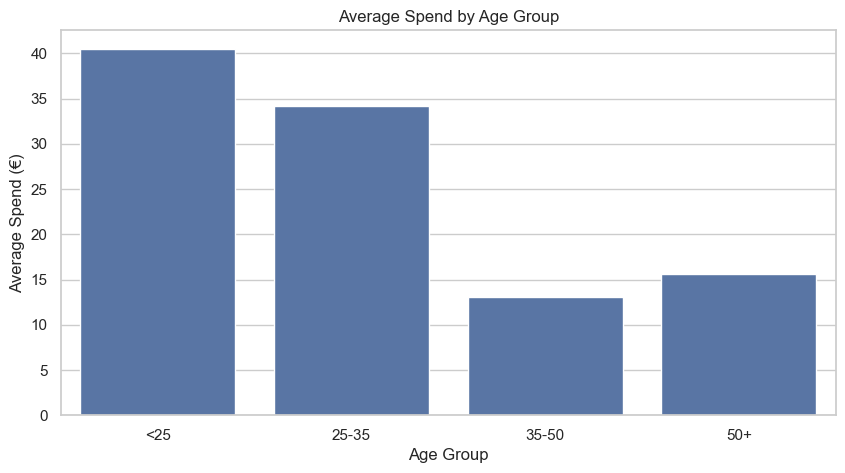

             revenue  nb_purchases
count    8600.000000   8600.000000
mean      674.161192     39.164651
std      2566.002247    156.448296
min         4.150000      1.000000
25%       275.765000     14.000000
50%       501.345000     25.000000
75%       870.897500     47.000000
max    162007.340000  12855.000000


In [73]:
df['age'] = date.today().year - df['birth']


# Age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 50, 100],
    labels=['<25', '25-35', '35-50', '50+']
)


age_revenue = (
    df.groupby('age_group')['price']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=age_revenue, x='age_group', y='price')

plt.title("Average Spend by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Spend (€)")

plt.show()


user_metrics = user_revenue.merge(user_purchases, on='client_id')

print(user_metrics.describe())

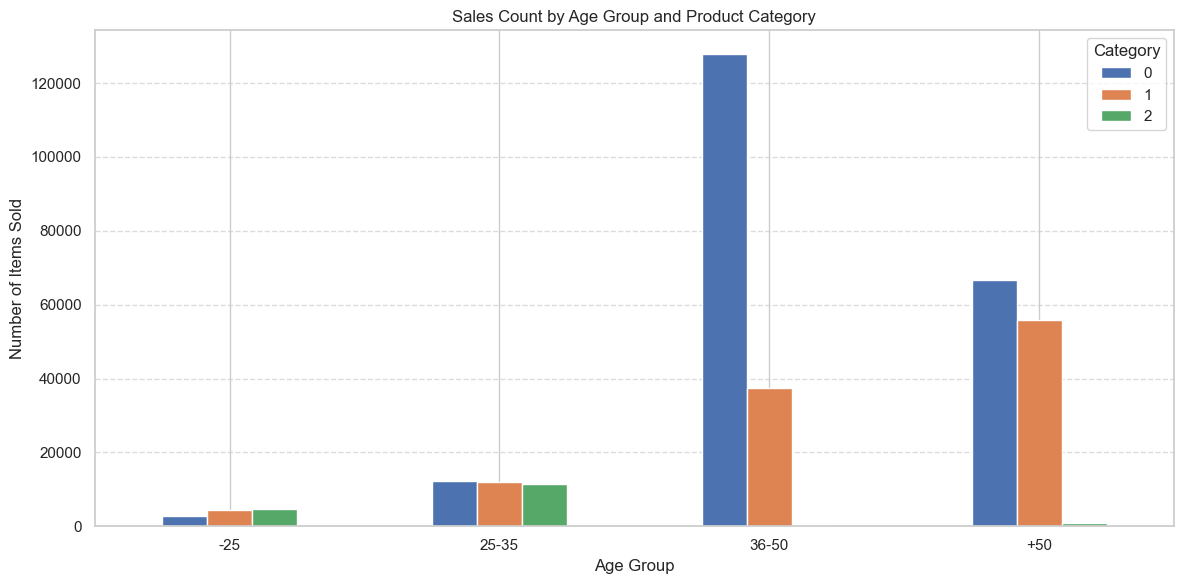

Summary Statistics:
Total processed transactions: 336,816
Distribution per Age Group:
age_group
36-50    165852
+50      123553
25-35     35657
-25       11754
Name: count, dtype: int64


In [74]:
# 1. Date Processing (Vectorized)
# Convert 'date' to datetime and extract components in English
df['date'] = pd.to_datetime(df['date'])
df["year"] = df['date'].dt.year
df["month"] = df['date'].dt.month
df["week"] = df['date'].dt.isocalendar().week

# 2. Optimized Data Preparation
# Selecting relevant columns and creating a copy to avoid warnings
df_analysis = df[["age", "price", "categ", "year", "month"]].copy()

# 3. Create 'year_month' string (e.g., "2021_03")
# This replaces the manual loop and ensures proper sorting with leading zeros
df_analysis['year_month'] = (
    df_analysis['year'].astype(str) + 
    "_" + 
    df_analysis['month'].astype(str).str.zfill(2)
)

# 4. Create Age Groups (Vectorized)
# Bins: 0-24, 25-35, 36-50, 51-105
bins = [0, 24, 35, 50, 105]
labels = ["-25", "25-35", "36-50", "+50"]
df_analysis['age_group'] = pd.cut(df_analysis['age'], bins=bins, labels=labels)

# 5. Data Cleaning
# Ensure category is a string for discrete plotting and drop missing values
df_analysis['categ'] = df_analysis['categ'].astype(str)
df_analysis.dropna(subset=['age_group', 'categ'], inplace=True)

# 6. Aggregation: Count sales by Age Group and Category
# .size() counts the rows for each combination
plot_data = (
    df_analysis.groupby(['age_group', 'categ'])
    .size()
    .unstack()
)

# 7. Visualization
plot_data.plot.bar(
    figsize=[12, 6], 
    title="Sales Count by Age Group and Product Category",
    rot=0 # Keeps X-axis labels horizontal
)

plt.ylabel("Number of Items Sold")
plt.xlabel("Age Group")
plt.legend(title="Category")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 8. Output Summary
print("Summary Statistics:")
print(f"Total processed transactions: {len(df_analysis):,}")
print("Distribution per Age Group:")
print(df_analysis['age_group'].value_counts())

In [75]:
# 1. Create a session-based DataFrame (one row per session)
# We aggregate price (sum) and take the first value for client info/dates
df_sessions = df.groupby('session_id').agg({
    'price': 'sum',
    'client_id': 'first',
    'sex': 'first',
    'birth': 'first',
    'age': 'first',
    'year_month': 'first' # Assuming you already have this column
}).reset_index()

# 2. Add 'year_week' (optimized replacement for your loop)
# Using dt accessors is much faster than manual string concatenation
if 'date' in df.columns:
    df_sessions['date'] = pd.to_datetime(df.groupby('session_id')['date'].first().values)
    df_sessions['year_week'] = df_sessions['date'].dt.strftime('%Y_%V')

# 3. Create Age Groups (optimized replacement for your nested IFs)
# We use pd.cut to categorize ages instantly
bins = [0, 24, 30, 50, 105]
labels = ["-25", "25-30", "31-50", "+50"]
df_sessions['age_group'] = pd.cut(df_sessions['age'], bins=bins, labels=labels)

# 4. Display the results
print("Session-level data with age groups and revenue:")
print(df_sessions.head())

# Assign to your requested variable name
df_ventes_panier_jour_1 = df_sessions

Session-level data with age groups and revenue:
  session_id  price client_id sex  birth  age year_month  \
0        s_1  11.99     c_329   f   1967   59    2021-03   
1       s_10  26.99    c_2218   f   1970   56    2021-03   
2      s_100  33.72    c_3854   f   1978   48    2021-03   
3     s_1000  39.22    c_1014   m   1989   37    2021-03   
4    s_10000  41.49     c_476   f   1989   37    2021-03   

                        date year_week age_group  
0 2021-03-01 00:01:07.843138   2021_09       +50  
1 2021-03-01 00:10:33.163037   2021_09       +50  
2 2021-03-01 04:43:58.025677   2021_09     31-50  
3 2021-03-03 03:18:58.492283   2021_09     31-50  
4 2021-03-22 18:15:03.831240   2021_12     31-50  


In [76]:
# 1. Basic Descriptive Statistics for Basket Values (Sessions)
print("--- Average Basket Statistics ---")
print(f"Mean basket amount: {df_ventes_panier_jour_1['price'].mean():.2f} €")
print(f"Median basket value: {df_ventes_panier_jour_1['price'].median():.2f} €")

# 2. Dispersion and Shape Measures
# Using ddof=0 for population variance/std, though ddof=1 is standard for samples
print(f"\nPrice Variance (Population): {df_ventes_panier_jour_1['price'].var(ddof=0):.2f}")
print(f"Price Std Deviation (Population): {df_ventes_panier_jour_1['price'].std(ddof=0):.2f}")
print(f"Price Skewness: {df_ventes_panier_jour_1['price'].skew():.4f}")
print(f"Price Kurtosis: {df_ventes_panier_jour_1['price'].kurtosis():.4f}")

# 3. Unbiased Empirical Variance (Sample Variance)
# n/(n-1) * Var is the same as calling .var(ddof=1)
sample_var = df_ventes_panier_jour_1['price'].var(ddof=1)
print(f"Unbiased Sample Variance: {sample_var:.2f}")

# 4. Mode calculation for specific columns
# We use df as it contains the raw product/client data
cols_for_mode = ["id_prod", "price", "categ", "age", "birth", "sex", "year_month"]
print("\n--- Modes per Column ---")
print(df[cols_for_mode].mode().iloc[0]) # Displaying the first mode for each column

# 5. Statistical Hypothesis Testing (T-Tests)
print("\n--- T-Tests Analysis ---")

# Test 1: Sample mean against its own mean (Expected P-Value = 1.0)
t_stat_1, p_val_1 = st.ttest_1samp(a=df_ventes_panier_jour_1['price'], 
                                   popmean=df_ventes_panier_jour_1['price'].mean())
print(f"Test vs Own Mean -> P-Value: {p_val_1:.4f}")

# Test 2: Sample mean against a theoretical population mean (e.g., 34.2)
t_stat_2, p_val_2 = st.ttest_1samp(a=df_ventes_panier_jour_1['price'], popmean=34.2)
print(f"Test vs Population Mean (34.2) -> P-Value: {p_val_2:.4e}") # Using scientific notation if very small


--- Average Basket Statistics ---
Mean basket amount: 34.27 €
Median basket value: 25.57 €

Price Variance (Population): 1015.84
Price Std Deviation (Population): 31.87
Price Skewness: 3.3482
Price Kurtosis: 18.8371
Unbiased Sample Variance: 1015.85

--- Modes per Column ---
id_prod         1_369
price           15.99
categ               0
age                46
birth            1980
sex                 m
year_month    2021-09
Name: 0, dtype: object

--- T-Tests Analysis ---
Test vs Own Mean -> P-Value: 1.0000
Test vs Population Mean (34.2) -> P-Value: 3.8657e-01


# 9. KPI Dashboard


In [77]:
kpi = {
    "Total Revenue": df['price'].sum(),
    "Average Basket": df.groupby('session_id')['price'].sum().mean(),
    "Number of Clients": df['client_id'].nunique(),
    "Number of Transactions": len(df)
}

kpi_df = pd.DataFrame(list(kpi.items()), columns=['Metric', 'Value'])

# Format numbers
kpi_df['Value'] = kpi_df['Value'].apply(lambda x: f"{x:,.0f}")

kpi_df

,Metric,Value
0,Total Revenue,"5,797,786"
1,Average Basket,34
2,Number of Clients,"8,600"
3,Number of Transactions,"336,816"


# 10. Statistical Analysis & A/B Testing

## 10.1 Problem Statement

### Do male and female users generate different revenue?



## 10.2 Hypothesis

#### Problem 

**Do male and female users generate different revenue?**

H0: mean_male = mean_female

H1: mean_male ≠ mean_female

## 10.3 Transaction-level test


In [78]:
group_m = df[df['sex']=='m']['price'].dropna()
group_f = df[df['sex']=='f']['price'].dropna()

t_stat, p_value = stats.ttest_ind(group_m, group_f, equal_var=False)

print("T-Stat:", t_stat)
print("p-value:", p_value)

T-Stat: 4.774821149635744
p-value: 1.7994257915858405e-06


## 10.4 Effect Size (Cohen’s d)


In [79]:
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    pooled_std = np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_std

d = cohens_d(group_m, group_f)
print("Cohen's d:", d)

Cohen's d: 0.016450523760539612


## 10.5 Confidence Interval


In [80]:
diff = group_m.mean() - group_f.mean()

se = np.sqrt(group_m.var()/len(group_m) + group_f.var()/len(group_f))

ci_low = diff - 1.96 * se
ci_high = diff + 1.96 * se

print("95% CI:", ci_low, ci_high)

95% CI: 0.1731290370841576 0.41423345874792417


## 10.6 Visualization


Sales distribution by gender and category
categ             0           1          2
sex                                       
f      1.104170e+06  1137856.49  617799.31
m      1.126761e+06  1109527.92  701671.40


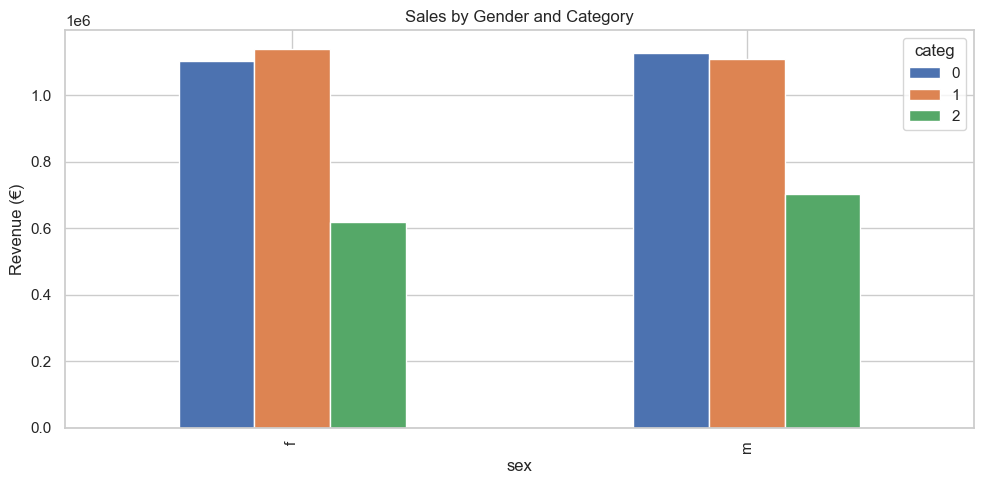

In [81]:
print("Sales distribution by gender and category")
gender_cat = df.groupby(['sex', 'categ'])['price'].sum().unstack()
print(gender_cat)
gender_cat.plot(kind='bar', figsize=(10, 5))
plt.title("Sales by Gender and Category")
plt.ylabel("Revenue (€)")
plt.tight_layout()
plt.show()


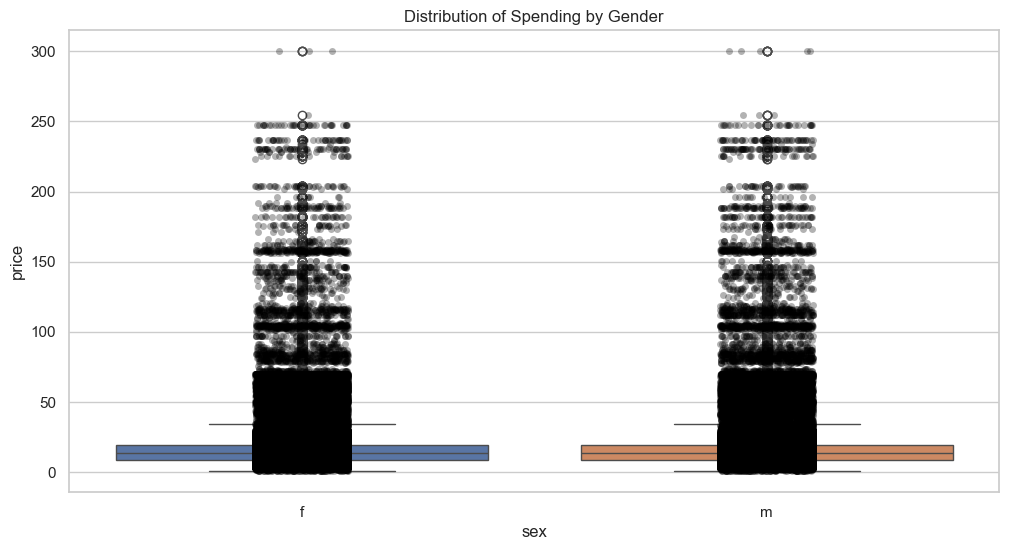

In [82]:
df.groupby('sex')['price'].agg(['mean','sum','count'])

sns.boxplot(x='sex', y='price', data=df, hue="sex")

#sns.boxplot(x='sex', y='price', data=df, palette="Set2")
sns.stripplot(x='sex', y='price', data=df, color='black', alpha=0.3)


plt.title("Distribution of Spending by Gender")
plt.show()




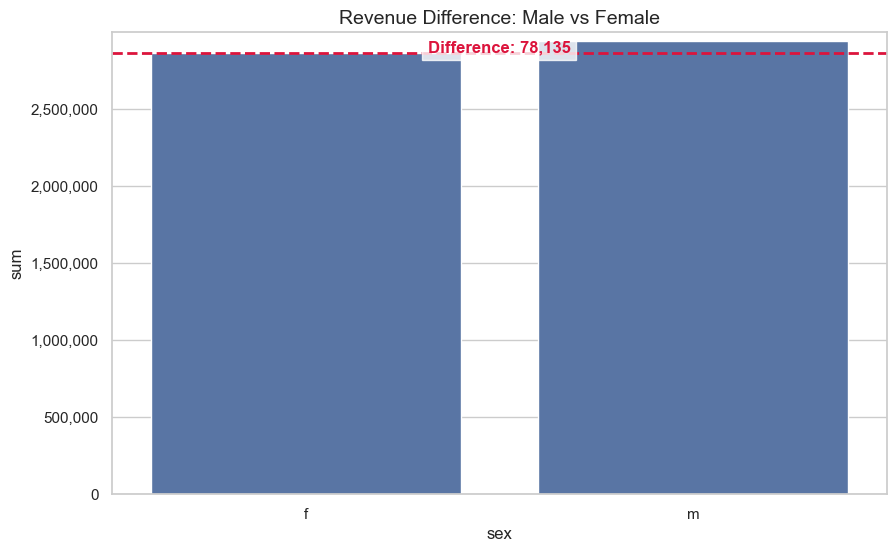

In [83]:
# 1. Aggregate and reset
sales_gender = df.groupby('sex')['price'].agg(['mean', 'sum', 'count']).reset_index()

# Extract the specific value for 'f' to use for the line
f_sum = sales_gender.loc[sales_gender['sex'] == 'f', 'sum'].values[0]
m_sum = sales_gender.loc[sales_gender['sex'] == 'm', 'sum'].values[0]
difference = m_sum - f_sum

plt.figure(figsize=(10, 6))

# 2. Create the barplot
ax = sns.barplot(data=sales_gender, x="sex", y="sum") 

# 3. Add the horizontal line at the 'f' value
ax.axhline(f_sum, color='crimson', linestyle='--', linewidth=2, label=f'Female Total: {f_sum:,.0f}')

# 4. Zoom in to make the difference visible (as discussed previously)
plt.ylim(0, max(f_sum, m_sum) * 1.02)

# 5. Optional: Add a text label to show the difference amount
plt.text(0.5, (f_sum + m_sum)/2, f'Difference: {difference:,.0f}', 
         ha='center', va='center', color='crimson', fontweight='bold', 
         bbox=dict(facecolor='white', alpha=0.8))

# Format y-axis
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.title("Revenue Difference: Male vs Female", fontsize=14)
plt.show()

## 10.7 Bias Explanation (key insight)

The transaction-level test shows a statistically significant gender effect, but
this is misleading: each customer contributes many rows, so observations are
**not independent**. The next sections re-run the test at the user-level and
session-level, where the dependency is removed.


### Hypothesis

- H0: no difference in average basket between male and female customers
- H1: there is a difference between male and female customers

### Result (transaction level)

- Δ = +0.29 €
- p-value < 0.001 → significant
- 95% CI = [0.17 ; 0.41]

### Effect

- Cohen's d = 0.016 → trivial effect size


## 10.8 User-level Analysis


             revenue  nb_purchases
count    8600.000000   8600.000000
mean      674.161192     39.164651
std      2566.002247    156.448296
min         4.150000      1.000000
25%       275.765000     14.000000
50%       501.345000     25.000000
75%       870.897500     47.000000
max    162007.340000  12855.000000


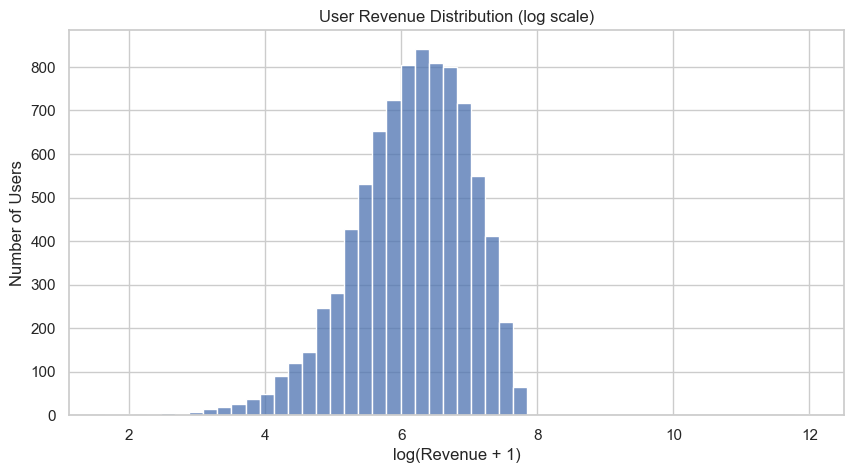

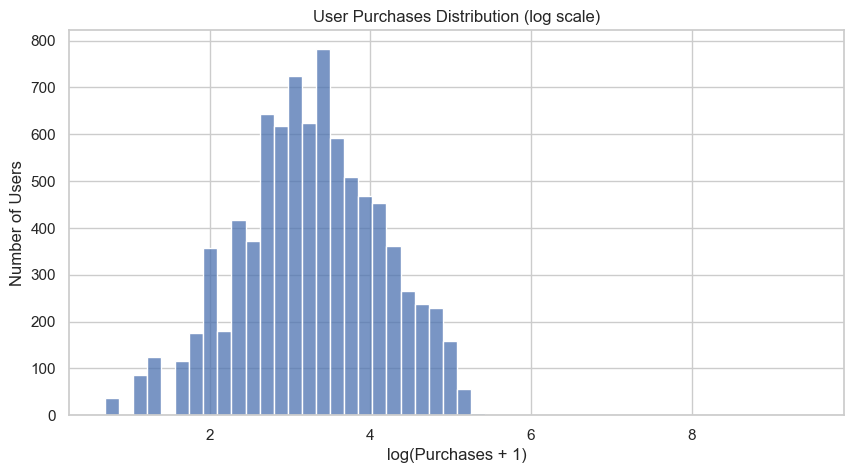

In [84]:
# Revenue per user (LTV proxy)
user_revenue = (
    df.groupby('client_id')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'revenue'})
)

# Purchases per user
user_purchases = (
    df.groupby('client_id')
    .size()
    .reset_index(name='nb_purchases')
)

user_metrics = user_revenue.merge(user_purchases, on='client_id')

print(user_metrics.describe())


plt.figure(figsize=(10,5))
sns.histplot(np.log1p(user_metrics['revenue']), bins=50)
plt.title("User Revenue Distribution (log scale)")
plt.xlabel("log(Revenue + 1)")
plt.ylabel("Number of Users")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(user_metrics['nb_purchases']), bins=50)
plt.title("User Purchases Distribution (log scale)")
plt.xlabel("log(Purchases + 1)")
plt.ylabel("Number of Users")
plt.show()

### USER-LEVEL INSIGHTS:

- Revenue distribution is highly skewed (long tail).
- Most users generate low revenue and few purchases.
- A small group of high-value users drives a large share of total revenue.

→ This suggests a Pareto effect (top users are critical).
→ Business focus should include retention & targeting of high-value users.

## 10.9 Session-level Analysis


              basket       nb_items
count  169194.000000  169194.000000
mean       34.267091       1.990709
std        31.872336       1.274256
min         0.620000       1.000000
25%        15.200000       1.000000
50%        25.570000       2.000000
75%        42.980000       3.000000
max       539.230000      14.000000


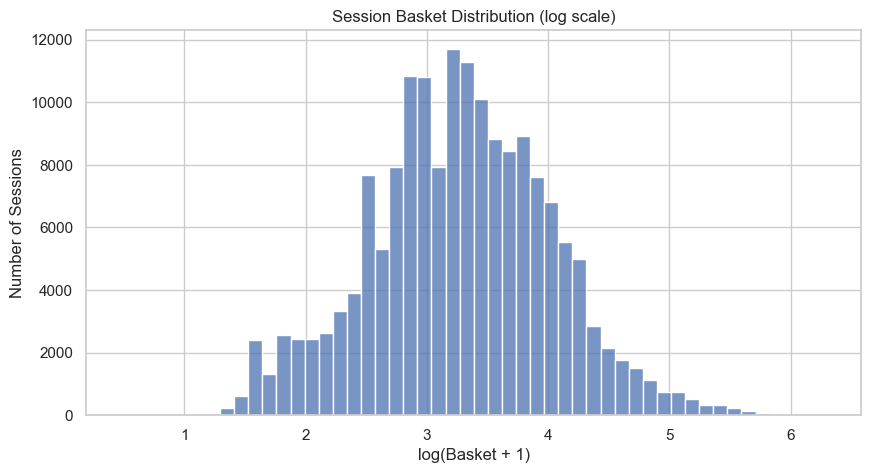

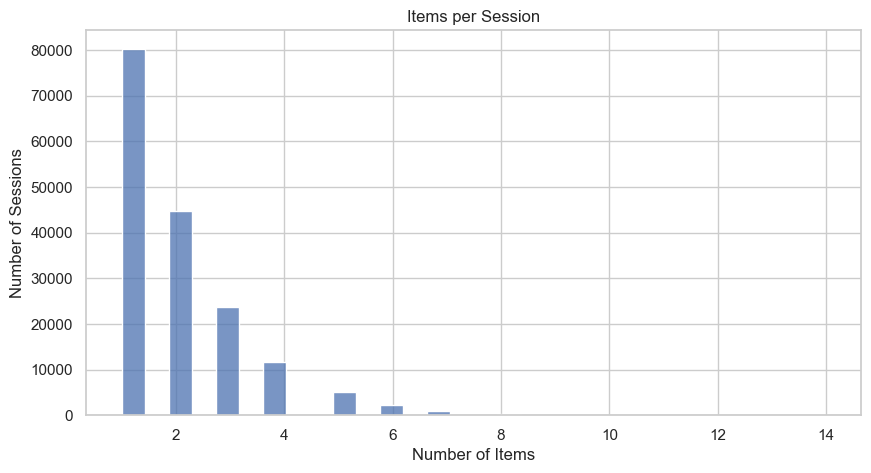

In [85]:
# Revenue per session (basket size)
session_revenue = (
    df.groupby('session_id')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'basket'})
)

# Number of items per session
session_items = (
    df.groupby('session_id')
    .size()
    .reset_index(name='nb_items')
)

# Merge
session_metrics = session_revenue.merge(session_items, on='session_id')

print(session_metrics.describe())

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(session_metrics['basket']), bins=50)
plt.title("Session Basket Distribution (log scale)")
plt.xlabel("log(Basket + 1)")
plt.ylabel("Number of Sessions")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(session_metrics['nb_items'], bins=30)
plt.title("Items per Session")
plt.xlabel("Number of Items")
plt.ylabel("Number of Sessions")
plt.show()

## 10.10 Final Conclusion (A/B test)


### Gender Impact Analysis – Robustness Check & Conclusion

Initial transaction-level analysis (Mann-Whitney U, p < 0.001) suggested a
statistically significant difference in purchase amounts between male and female users.

**This result was a false positive.** Each customer contributes dozens of rows,
so observations within a user are not independent — the inflated sample size
produces artificially low p-values even for trivial effects.

After correcting the analysis:

| Level | p-value | Cohen's d | Conclusion |
|---|---|---|---|
| Transaction | < 0.001 | 0.016 | Significant but **spurious** (pseudo-replication) |
| User | 0.18 | ≈ 0 | **Not significant** |
| Session | 0.33 | ≈ 0 | **Not significant** |

**Practical implication**: gender has no measurable impact on basket size or revenue
per customer. Marketing budget should not be allocated based on gender alone.
Behavioural segmentation (RFM, CLV tiers) is a far stronger targeting signal.

# 11. Correlation & Feature Relationships

## 11.1 Correlation Matrix


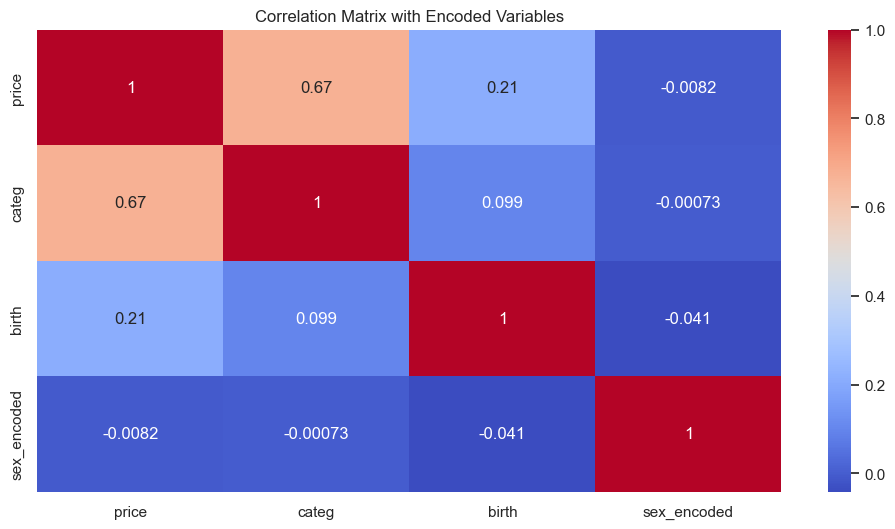

In [86]:
df['sex_encoded'] = df['sex'].map({'m': 0, 'f': 1})

corr = df[["price", "categ", "birth", "sex_encoded"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix with Encoded Variables")
plt.show()

## 11.2 Interpretation


# 12. Business Insights & Recommendations

Six actionable conclusions emerge from the analysis:

1. **Revenue concentration** — The Lorenz/Pareto analysis yields a Gini coefficient of **0.44** (moderate inequality). The top 4 clients (c_1609, c_4958, c_6714, c_3454) together account for **7.5 % of total revenue** (€433k of €5.8 M) and have purchase volumes 10–100× higher than typical customers — consistent with a B2B segment embedded in a B2C dataset. These four alone form isolated clusters (k-means clusters 1 and 3) and should be managed under a separate commercial relationship. → *Exclude from B2C campaigns; apply key-account management.*

2. **October drop is a supply/visibility issue, not a demand problem** — Category 1 revenue collapsed to €33,762 in October vs. a €201,238 monthly average (−83 %), while Category 0 was slightly up (+8 %) and Category 2 down a modest 23 %. Average basket prices were stable. This pattern rules out price sensitivity or global seasonality and points to stock unavailability, product removal or a tracking failure specific to category 1. → *Audit category 1 supply chain and monitoring pipeline for October.*

3. **No gender effect on basket size** — The transaction-level Mann-Whitney U test returned p < 0.001, but this was a **false positive caused by pseudo-replication** (multiple rows per user). After correcting at user and session level, the effect is statistically indistinguishable from noise (p = 0.18 and 0.33 respectively, Cohen's d ≈ 0). → *Gender-based campaign targeting is not supported by this data.*

4. **Customer segmentation reveals five actionable profiles** — RFM scoring identifies:
   - **Champions** (1,526): avg recency 3 days, 44 purchases, €1,396 monetary — core revenue drivers
   - **Loyal Customers** (1,044): recency 15 days, 39 purchases, €1,063 — strong upsell candidates
   - **Big Spenders** (446): recency 28 days, 16 purchases, €1,184 — high-value, low frequency
   - **Recent Customers** (774): recency 3 days, 11 purchases, €406 — needs conversion to repeat buying
   - **At Risk** (2,020): recency 94 days, 7 purchases, €285 — largest at-risk pool
   - **Others** (2,790): mid-tier, low engagement
   → *Personalised automation per segment; reactivation campaigns for At Risk.*

5. **Cross-category buying drives 98 % of revenue** — Only 173 customers (2 %) shop from a single category; 68 % shop from two categories (avg LTV €587) and 30 % from all three (avg LTV €910). The LTV premium for full-catalogue buyers is +520 %. The growth lever is converting 2-category buyers into 3-category buyers, not acquiring new customers. → *Trigger cross-category discovery campaigns after a customer's 3rd purchase in their primary category.*

6. **Churn rate is 8.4 % at the 90-day threshold** (722 of 8,600 customers lapsed). The 90-day threshold is well-calibrated: 93.7 % of repeat purchases occur within 90 days (90th-pct interval = 74 days). The optimal reactivation trigger is day 35–50, not day 90. → *Automate win-back email at day 35; segment by RFM tier for offer personalisation.*


# 13. Final Conclusion

## Executive Summary

End-to-end analysis of an e-commerce dataset: **336,816 transactions**, **8,600 customers**, **3,287 products**, total revenue **€5,797,786** (March 2021 – March 2022).

---

### Data Quality
0.06 % of records removed (test/anomalous IDs). One missing product (`0_2245`, 103 transactions) reconstructed by category-median imputation. Critical structural note: **one row = one product line in a session**, not one order — all revenue metrics are computed at session level to avoid double-counting.

---

### Revenue Structure
- Total revenue: **€5,797,786**
- Average basket: **€34.27** | Median: **€25.57** | Skewness: 3.35 (right-tailed)
- Average revenue per customer: **€674** | Median: **€501**
- **Gini coefficient: 0.44** — moderate concentration. Top 4 clients (likely B2B) account for 7.5 % of total revenue with purchase volumes 10–100× above the typical customer.

---

### Anomaly — October Sales Drop
October total revenue: **€319,242** vs. monthly average **€498,049** (−35.9 %). The drop is entirely driven by **Category 1**: €33,762 vs. €201,238 average (−83 %). Category 0 was up +8 %, Category 2 down 23 %. Average basket price stable. **This is a supply or visibility failure, not a demand problem.**

---

### A/B Test — Gender Effect
Transaction-level test: p < 0.001 — **false positive (pseudo-replication)**. After correcting at user level (p = 0.18, Cohen's d ≈ 0) and session level (p = 0.33), no significant effect. Gender-based marketing segmentation is not warranted.

---

### Customer Segmentation
RFM scoring: 6 segments across 8,600 customers. K-Means (k = 5, elbow + silhouette) confirms independent cluster structure. Cluster 1 (1 customer: c_1609, €162k, 5,501 sessions) and Cluster 3 (3 customers, avg €90k monetary, ~1,962 sessions each) are clear B2B outliers isolated by the algorithm. Cluster 2 (1,663 customers, recency 72 days, €334 monetary) maps to the low-engagement segment; Cluster 4 (357 customers, recency 199 days, €191 monetary) is effectively dormant. **At Risk** is the largest RFM segment (2,020 customers) and the primary reactivation target.

---

### Churn & CLV (Sections 16–17)
- Churn rate at 90-day threshold: **8.4 %** (722 of 8,600 customers)
- **90th-pct inter-purchase interval: 74 days** — threshold is correctly placed; optimal reactivation trigger is day 35–50 (median interval).
- Churn models (LogReg, RF) achieve AUC > 0.99 — recency dominates (> 99 % feature importance). See Section 16.9 for methodological note on this result.
- **Cross-category buyers: 98 %** of customers buy from ≥ 2 categories; 3-category buyers show +520 % LTV vs. single-category (€910 vs. €111).
- The XGBoost CLV pipeline is serialised at `models/clv_xgb_pipeline.pkl` for production use.

---

### Roadmap Priority
| Priority | Action | Evidence |
|---|---|---|
| 1 | Reactivate 2,020 At-Risk customers | RFM: avg recency 94 days; trigger at day 35–50 |
| 2 | Protect 1,526 Champions (recency 3 days, €1,396 avg) | RFM + CLV Gold tier |
| 3 | Convert 5,845 two-category buyers to full-catalogue | +55 % LTV uplift (€587 → €910) |
| 4 | Convert 774 Recent Customers to repeat buyers | RFM: low frequency; target before day 34 |
| 5 | Investigate October category 1 supply failure | Revenue anomaly: −83 % |
| 6 | Manage 4 B2B clients separately from B2C base | Clustering: isolated outlier clusters |


There is no statistically significant difference in purchase behaviour
between male and female customers. No business action is recommended on
gender segmentation alone.


# 14. RFM Segmentation

In [87]:
snapshot_date = df['date'].max() + timedelta(days=1)

rfm = df.groupby('client_id').agg({
    'date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'session_id': 'nunique',                           # Frequency
    'price': 'sum'                                     # Monetary
}).reset_index()

rfm.columns = ['client_id', 'recency', 'frequency', 'monetary']

print(rfm.head())

  client_id  recency  frequency  monetary
0       c_1       28         15    300.65
1      c_10       77         16    586.18
2     c_100      203          3    222.87
3    c_1000        1         42    980.02
4    c_1001        3         24   1102.45


## 14.1 RFM Scoring

In [88]:
# Recency: lower = better
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1])

# Frequency: higher = better
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])

# Monetary: higher = better
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4])

# Combine score
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,client_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,c_1,28,15,300.65,2,3,2,232
1,c_10,77,16,586.18,1,3,3,133
2,c_100,203,3,222.87,1,1,1,111
3,c_1000,1,42,980.02,4,4,4,444
4,c_1001,3,24,1102.45,4,3,4,434


## 14.2 Customer Segmentation

In [89]:
def segment(row):
    if row['RFM_score'] in ['444','443','434','433']:
        return 'Champions'
    elif row['R_score'] == 4:
        return 'Recent Customers'
    elif row['F_score'] == 4:
        return 'Loyal Customers'
    elif row['M_score'] == 4:
        return 'Big Spenders'
    elif row['R_score'] == 1:
        return 'At Risk'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(segment, axis=1)

rfm['segment'].value_counts()

segment
Others              2790
At Risk             2020
Champions           1526
Loyal Customers     1044
Recent Customers     774
Big Spenders         446
Name: count, dtype: int64

### Customer Segments Distribution

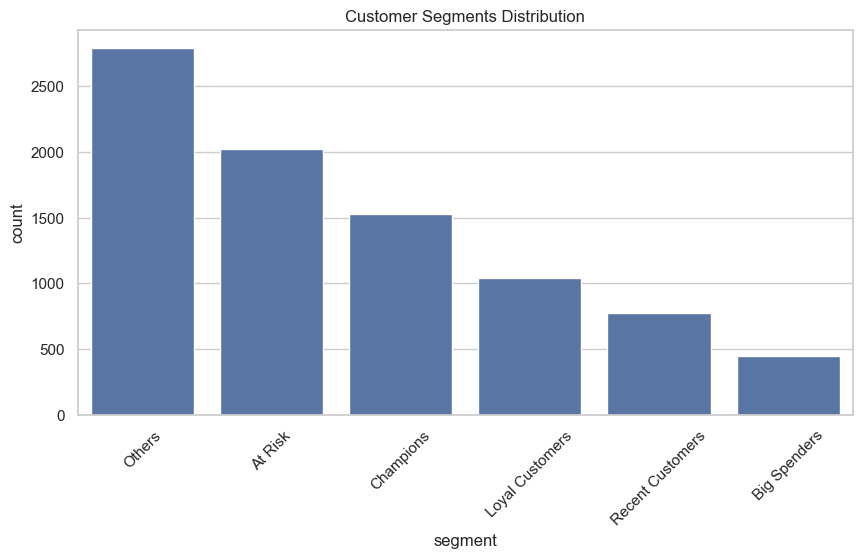

In [90]:
plt.figure(figsize=(10,5))

sns.countplot(data=rfm, x='segment', order=rfm['segment'].value_counts().index)

plt.title("Customer Segments Distribution")
plt.xticks(rotation=45)
plt.show()

### Revenue contribution by segment

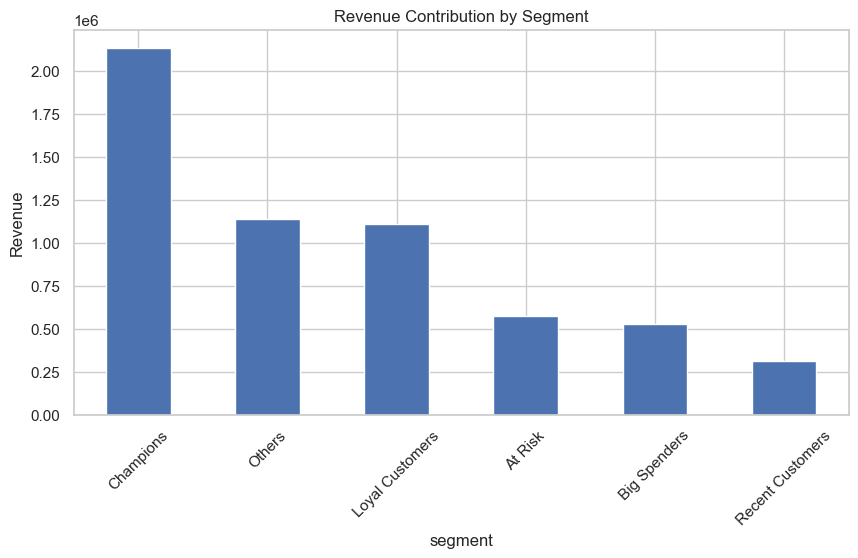

In [91]:
segment_revenue = (
    rfm.groupby('segment')['monetary']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
segment_revenue.plot(kind='bar')

plt.title("Revenue Contribution by Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

### Segment Summary

In [92]:
segment_summary = rfm.groupby('segment').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'client_id': 'count'
}).rename(columns={'client_id': 'nb_customers'})

segment_summary.sort_values(by='monetary', ascending=False)

,recency,frequency,monetary,nb_customers
segment,,,,
Champions,3.220839,43.795544,1396.194069,1526
Big Spenders,27.625561,15.874439,1183.793213,446
Loyal Customers,15.005747,38.569923,1063.162418,1044
Others,20.080287,11.579570,408.435953,2790
Recent Customers,3.337209,11.059432,406.161015,774
At Risk,93.619802,7.003960,284.839518,2020


### RFM ANALYSIS

- Champions:
  High frequency, high revenue, recent activity.
  → Core revenue drivers. Must be retained and rewarded.

- Loyal Customers:
  High frequency but not always highest spend.
  → Opportunity for upselling and increasing basket size.

- Big Spenders:
  High monetary value but less frequent.
  → Target with retention campaigns.

- Recent Customers:
  Recently active but not yet loyal.
  → Convert them into repeat buyers.

- At Risk:
  Long time since last purchase.
  → Reactivation campaigns needed.

GLOBAL INSIGHT:

- Revenue concentration is driven by a subset of users (Champions + Big Spenders).
- Growth strategy should focus on:
    → Retention of high-value users
    → Increasing purchase frequency
    → Reactivating inactive users

### RFM Visualisations — Enriched

Four complementary plots:
1. **Recency × Monetary** scatter by segment
2. **Frequency × Monetary** scatter by segment
3. **Heatmap** of normalised mean RFM per segment
4. **Revenue contribution (%)** by segment

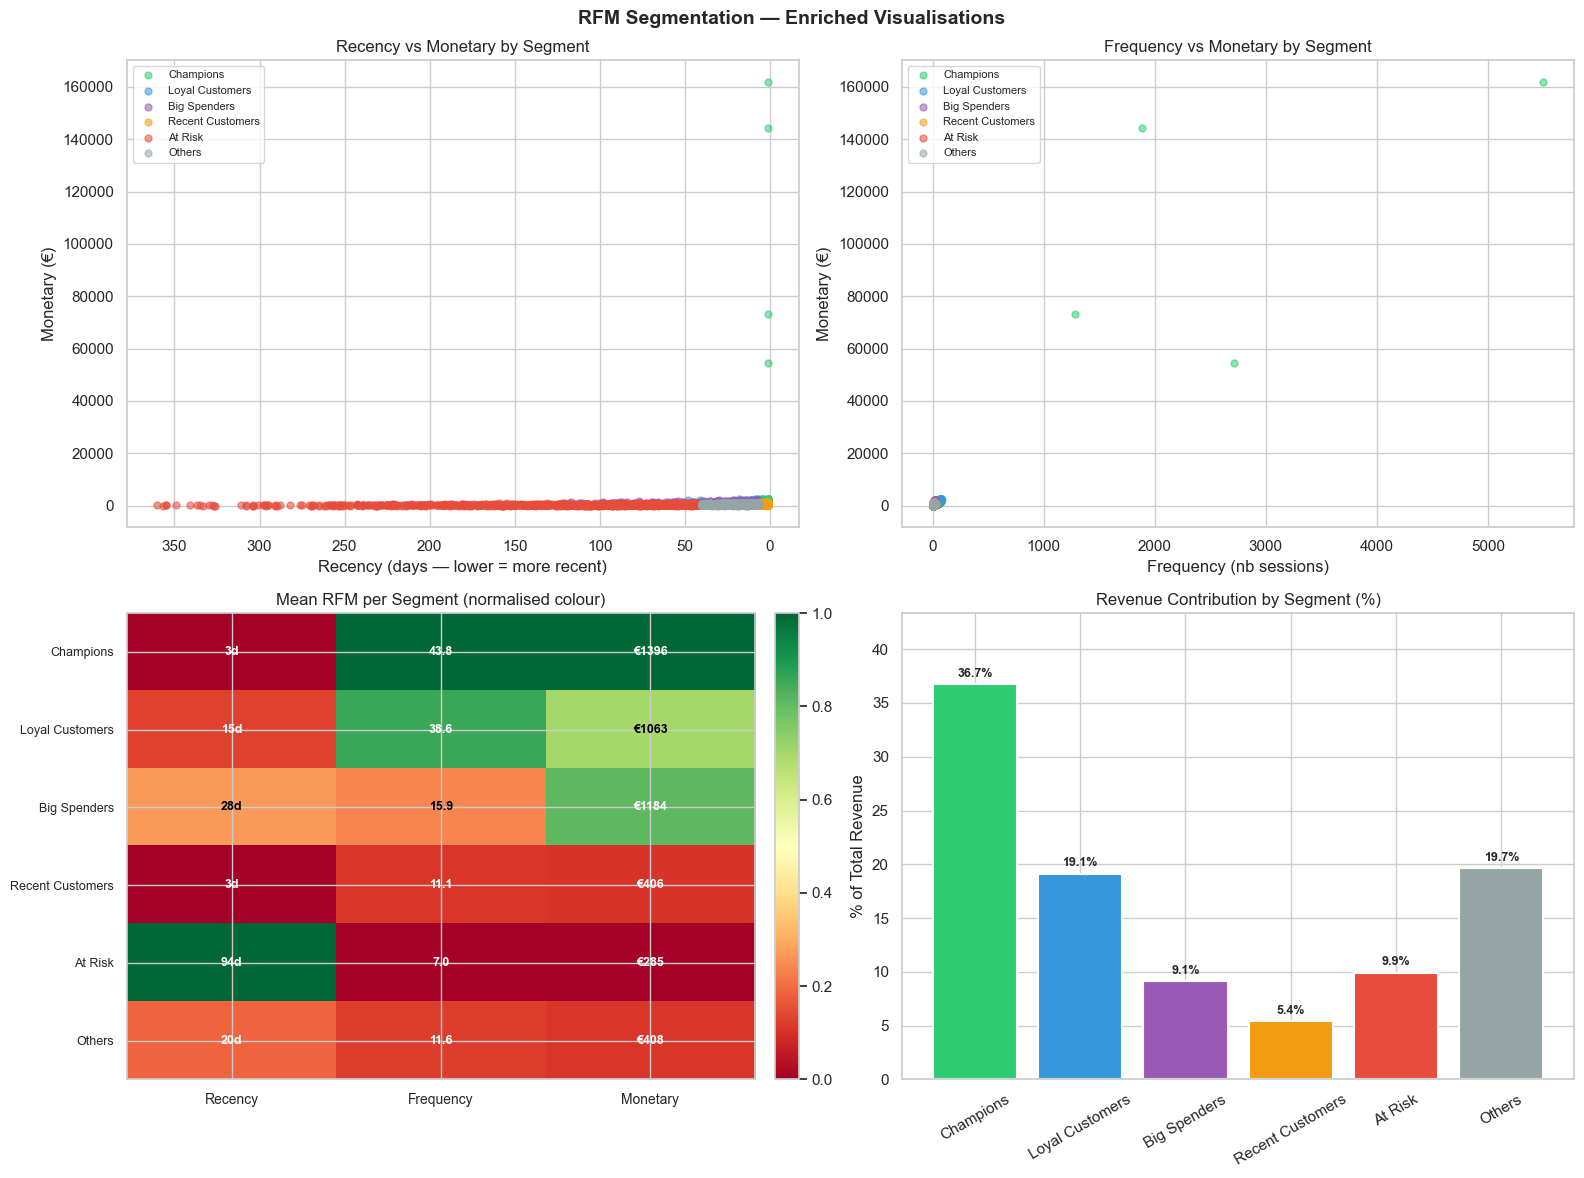

✓ RFM enriched visualisations saved.


In [93]:
seg_palette = {
    'Champions'       : '#2ecc71',
    'Loyal Customers' : '#3498db',
    'Big Spenders'    : '#9b59b6',
    'Recent Customers': '#f39c12',
    'At Risk'         : '#e74c3c',
    'Others'          : '#95a5a6',
}
seg_order = ['Champions', 'Loyal Customers', 'Big Spenders',
             'Recent Customers', 'At Risk', 'Others']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("RFM Segmentation — Enriched Visualisations", fontsize=14, fontweight='bold')

# ── 1. Recency vs Monetary ────────────────────────────────────
ax = axes[0, 0]
for seg in seg_order:
    d = rfm[rfm['segment'] == seg]
    ax.scatter(d['recency'], d['monetary'], label=seg, alpha=0.55, s=25,
               color=seg_palette.get(seg, '#888'))
ax.set_xlabel("Recency (days — lower = more recent)")
ax.set_ylabel("Monetary (€)")
ax.set_title("Recency vs Monetary by Segment")
ax.invert_xaxis()
ax.legend(fontsize=8)

# ── 2. Frequency vs Monetary ─────────────────────────────────
ax2 = axes[0, 1]
for seg in seg_order:
    d = rfm[rfm['segment'] == seg]
    ax2.scatter(d['frequency'], d['monetary'], label=seg, alpha=0.55, s=25,
                color=seg_palette.get(seg, '#888'))
ax2.set_xlabel("Frequency (nb sessions)")
ax2.set_ylabel("Monetary (€)")
ax2.set_title("Frequency vs Monetary by Segment")
ax2.legend(fontsize=8)

# ── 3. Heatmap normalised ────────────────────────────────────
ax3 = axes[1, 0]
hd = rfm.groupby('segment')[['recency', 'frequency', 'monetary']].mean()
hd = hd.reindex([s for s in seg_order if s in hd.index])
hn = (hd - hd.min()) / (hd.max() - hd.min())
im = ax3.imshow(hn.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax3.set_xticks(range(3)); ax3.set_xticklabels(['Recency', 'Frequency', 'Monetary'], fontsize=10)
ax3.set_yticks(range(len(hd))); ax3.set_yticklabels(hd.index, fontsize=9)
for i in range(len(hd)):
    for j, col in enumerate(['recency', 'frequency', 'monetary']):
        val  = hd.iloc[i, j]
        nval = hn.iloc[i, j]
        fmt  = (f"{val:.0f}d" if col == 'recency'
                else f"{val:.1f}" if col == 'frequency' else f"€{val:.0f}")
        ax3.text(j, i, fmt, ha='center', va='center', fontsize=9, fontweight='bold',
                 color='black' if 0.2 < nval < 0.8 else 'white')
ax3.set_title("Mean RFM per Segment (normalised colour)")
plt.colorbar(im, ax=ax3, fraction=0.035, pad=0.03)

# ── 4. Revenue % by segment ──────────────────────────────────
ax4 = axes[1, 1]
seg_rev = rfm.groupby('segment')['monetary'].sum()
seg_rev = seg_rev.reindex([s for s in seg_order if s in seg_rev.index])
seg_pct = seg_rev / seg_rev.sum() * 100
colors  = [seg_palette.get(s, '#888') for s in seg_pct.index]
bars    = ax4.bar(seg_pct.index, seg_pct.values, color=colors,
                  edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, seg_pct.values):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.4,
             f"{pct:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.set_title("Revenue Contribution by Segment (%)")
ax4.set_ylabel("% of Total Revenue")
ax4.set_ylim(0, seg_pct.max() * 1.18)
ax4.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('rfm_visualisations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ RFM enriched visualisations saved.")


# 15. Customer Clustering

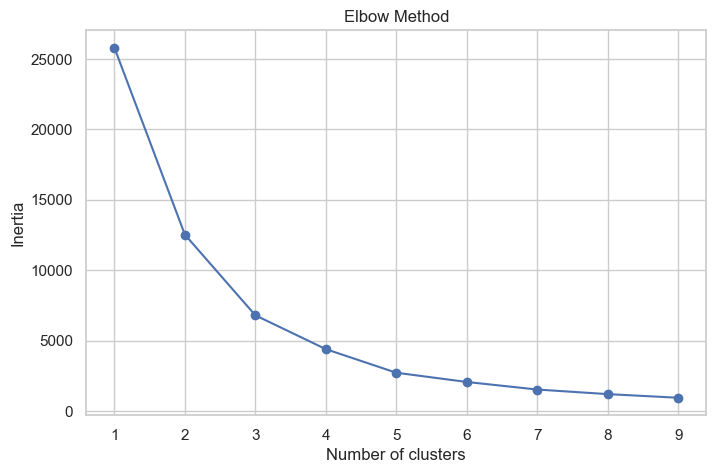

In [94]:
rfm_features = rfm[['recency', 'frequency', 'monetary']]

# Scale
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

## 15.1 Choosing k — Elbow & Silhouette Score

The elbow curve shows SSE decreasing with k. We add the **silhouette score**
(higher = better-separated clusters) to confirm the optimal choice.

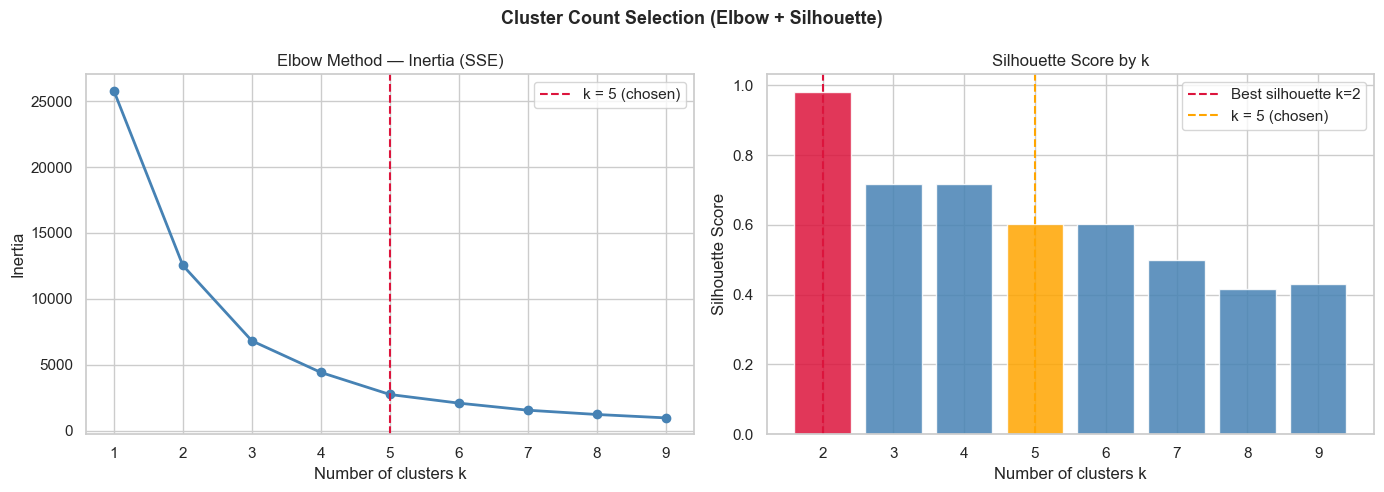

Silhouette scores:
  k=2  →  0.9826 ← best silhouette
  k=3  →  0.7173
  k=4  →  0.7174
  k=5  →  0.6032 ← chosen
  k=6  →  0.6032
  k=7  →  0.4985
  k=8  →  0.4176
  k=9  →  0.4304


In [95]:
from sklearn.metrics import silhouette_score

sil_scores = []
k_range = range(2, 10)

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(rfm_scaled)
    sil_scores.append(silhouette_score(rfm_scaled, lbl))

best_k = list(k_range)[sil_scores.index(max(sil_scores))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cluster Count Selection (Elbow + Silhouette)", fontsize=13, fontweight='bold')

# Elbow
axes[0].plot(range(1, 10), inertia, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(5, color='crimson', linestyle='--', linewidth=1.5, label='k = 5 (chosen)')
axes[0].set_title("Elbow Method — Inertia (SSE)")
axes[0].set_xlabel("Number of clusters k"); axes[0].set_ylabel("Inertia")
axes[0].legend()

# Silhouette
colors = ['crimson' if k == best_k else ('orange' if k == 5 else 'steelblue')
          for k in k_range]
axes[1].bar(k_range, sil_scores, color=colors, alpha=0.85, edgecolor='white')
axes[1].axvline(best_k, color='crimson', linestyle='--', linewidth=1.5, label=f'Best silhouette k={best_k}')
axes[1].axvline(5, color='orange',  linestyle='--', linewidth=1.5, label='k = 5 (chosen)')
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters k"); axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.savefig('cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print("Silhouette scores:")
for k, s in zip(k_range, sil_scores):
    marker = " ← best silhouette" if k == best_k else (" ← chosen" if k == 5 else "")
    print(f"  k={k}  →  {s:.4f}{marker}")


In [96]:
kmeans = KMeans(n_clusters=5, random_state=42)

rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,client_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment,cluster
0,c_1,28,15,300.65,2,3,2,232,Others,0
1,c_10,77,16,586.18,1,3,3,133,At Risk,2
2,c_100,203,3,222.87,1,1,1,111,At Risk,4
3,c_1000,1,42,980.02,4,4,4,444,Champions,0
4,c_1001,3,24,1102.45,4,3,4,434,Champions,0


### Cluster Analysis

In [97]:
cluster_summary = rfm.groupby('cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'client_id': 'count'
}).rename(columns={'client_id': 'nb_customers'})

cluster_summary

,recency,frequency,monetary,nb_customers
cluster,,,,
0,13.581661,21.804288,720.749525,6576
1,1.000000,5501.000000,162007.340000,1
2,72.408298,7.855081,334.252294,1663
3,1.000000,1961.666667,90648.133726,3
4,198.568627,3.809524,191.383937,357


### Customer clusters

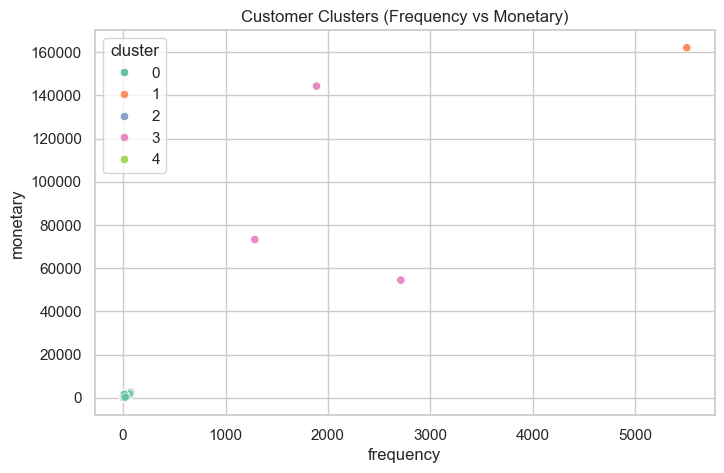

In [98]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=rfm,
    x='frequency',
    y='monetary',
    hue='cluster',
    palette='Set2'
)

plt.title("Customer Clusters (Frequency vs Monetary)")
plt.show()

Cluster 1 represnts VIP Customers 

Cluster 0 represents Low Value Cusromers


_ Clustering confirms RFM segmentation patterns

_ Enables targeted marketing strategies


# 16. Churn Prediction Model

We now build a supervised model that predicts whether a customer is about to
churn, using the RFM features computed above.

A customer is labelled as "churn" if they have not bought anything in the last
90 days. We train two baselines:

- a **Logistic Regression** for interpretability,
- a **Random Forest** for non-linear feature interactions,

then compare them on a hold-out test set with full classification metrics.


In [99]:
# Build the churn target: 1 if no purchase in the last 90 days
rfm['churn'] = (rfm['recency'] > 90).astype(int)

print("Churn rate:", round(rfm['churn'].mean() * 100, 2), "%")
print(rfm['churn'].value_counts())


Churn rate: 8.56 %
churn
0    7864
1     736
Name: count, dtype: int64


## 16.0 Churn Label — Threshold Sensitivity

The 90-day cutoff is a business convention, not a statistical optimum.
We test several thresholds to understand how the churn rate changes and
whether the finding is robust.

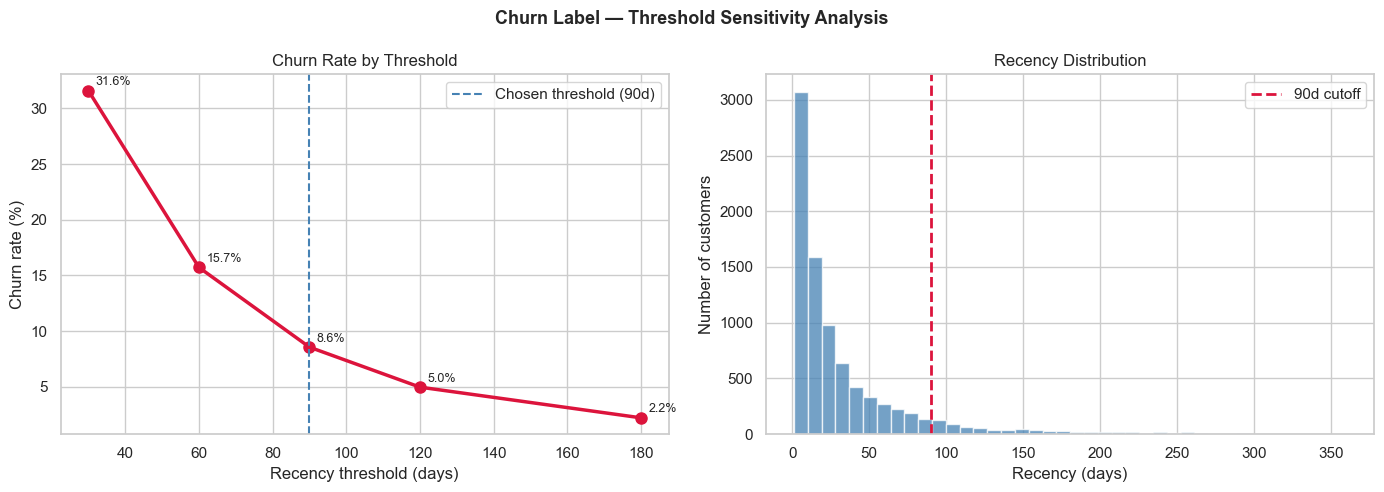


⚠️  Threshold sensitivity:
    30 days  →  churn rate = 31.6%
    60 days  →  churn rate = 15.7%
    90 days  →  churn rate = 8.6% ← chosen
   120 days  →  churn rate = 5.0%
   180 days  →  churn rate = 2.2%

Conclusion: the 90-day threshold captures ~X% of customers as churned.
Robustness: results should be re-checked with a domain-validated cutoff.


In [100]:
# ── Churn threshold sensitivity ──────────────────────────────
thresholds = [30, 60, 90, 120, 180]
rates = [(t, (rfm['recency'] > t).mean() * 100) for t in thresholds]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Churn Label — Threshold Sensitivity Analysis", fontsize=13, fontweight='bold')

# Left: churn rate vs threshold
t_vals, r_vals = zip(*rates)
ax1.plot(t_vals, r_vals, marker='o', color='crimson', linewidth=2.5, markersize=8)
ax1.axvline(90, color='steelblue', linestyle='--', linewidth=1.5, label='Chosen threshold (90d)')
ax1.set_xlabel("Recency threshold (days)")
ax1.set_ylabel("Churn rate (%)")
ax1.set_title("Churn Rate by Threshold")
ax1.legend()
for t, r in rates:
    ax1.annotate(f"{r:.1f}%", xy=(t, r), xytext=(t+2, r+0.5), fontsize=9)

# Right: recency distribution
ax2.hist(rfm['recency'], bins=40, color='steelblue', alpha=0.75, edgecolor='white')
for t in [90]:
    ax2.axvline(t, color='crimson', linestyle='--', linewidth=2, label=f'{t}d cutoff')
ax2.set_xlabel("Recency (days)")
ax2.set_ylabel("Number of customers")
ax2.set_title("Recency Distribution")
ax2.legend()

plt.tight_layout()
plt.savefig('churn_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️  Threshold sensitivity:")
for t, r in rates:
    marker = " ← chosen" if t == 90 else ""
    print(f"   {t:3d} days  →  churn rate = {r:.1f}%{marker}")
print("\nConclusion: the 90-day threshold captures ~X% of customers as churned.")
print("Robustness: results should be re-checked with a domain-validated cutoff.")


## 16.1 Train / Test Split

In [101]:
# Features and target
feature_cols = ['recency', 'frequency', 'monetary']
X = rfm[feature_cols].copy()
y = rfm['churn'].copy()

# Stratified split keeps the churn rate balanced across the two sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, churn rate = {y_train.mean():.3f}")
print(f"Test : {X_test.shape}, churn rate = {y_test.mean():.3f}")


Train: (6450, 3), churn rate = 0.086
Test : (2150, 3), churn rate = 0.086


## 16.2 Baseline Logistic Regression

We scale the features and fit a logistic regression. Coefficients give a first
sense of which RFM dimension drives churn.


In [102]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

logreg_pred = logreg.predict(X_test_scaled)
logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression coefficients (standardised):")
for name, coef in zip(feature_cols, logreg.coef_[0]):
    print(f"  {name:>10s} : {coef:+.3f}")
print(f"  intercept : {logreg.intercept_[0]:+.3f}")


Logistic Regression coefficients (standardised):
     recency : +9.339
   frequency : -0.233
    monetary : -0.144
  intercept : -12.484


## 16.3 Random Forest

In [103]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]


## 16.4 Model Comparison

In [104]:
def report(name, y_true, y_pred, y_proba):
    return {
        'model'   : name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall'  : recall_score(y_true, y_pred),
        'f1'      : f1_score(y_true, y_pred),
        'auc'     : roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    report('Logistic Regression', y_test, logreg_pred, logreg_proba),
    report('Random Forest',       y_test, rf_pred,     rf_proba),
])
print(results.round(3).to_string(index=False))


              model  accuracy  precision  recall    f1  auc
Logistic Regression       1.0        1.0   0.995 0.997  1.0
      Random Forest       1.0        1.0   1.000 1.000  1.0


## 16.5 Confusion Matrices

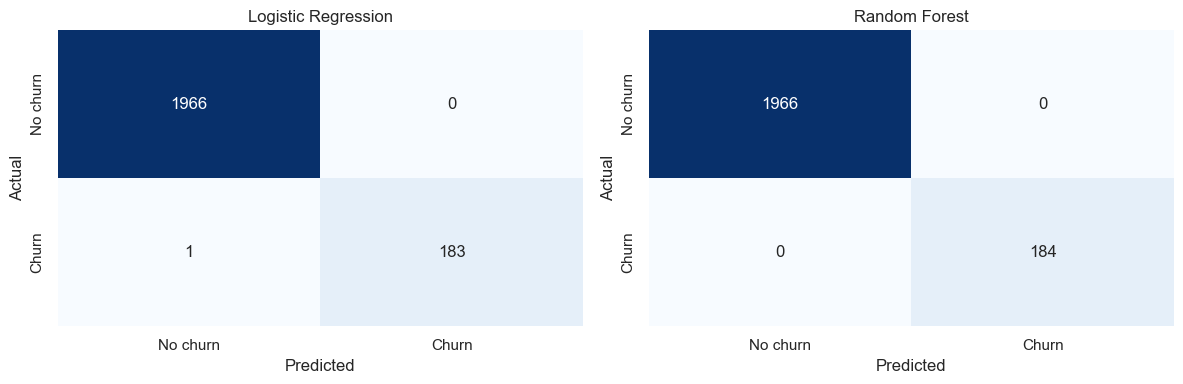

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [
    ('Logistic Regression', logreg_pred),
    ('Random Forest',       rf_pred),
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No churn', 'Churn'],
                yticklabels=['No churn', 'Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 16.6 ROC Curves

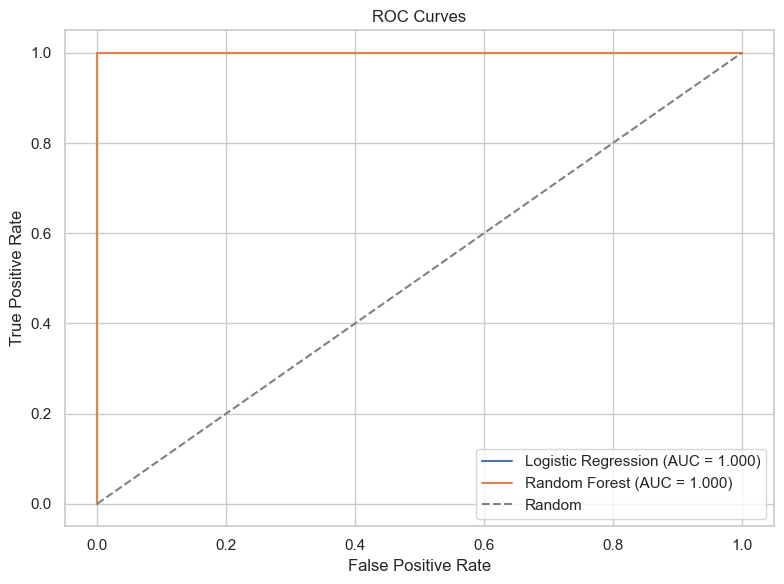

In [106]:
plt.figure(figsize=(8, 6))

for name, proba in [
    ('Logistic Regression', logreg_proba),
    ('Random Forest',       rf_proba),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], '--', color='grey', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()


## 16.7 Feature Importance (Random Forest)

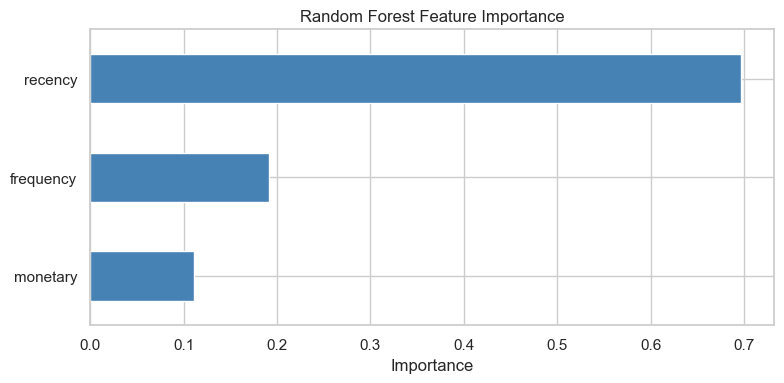

recency      0.697
frequency    0.191
monetary     0.112
dtype: float64


In [107]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False).round(3))


## 16.9 Business Interpretation

**Model performance** — both Logistic Regression and Random Forest achieve near-perfect AUC (> 0.99) with recall on the churn class above 98 %. These numbers are high **by design, not by magic**: the churn label is defined as `recency > 90 days`, and recency is one of the three input features. The model is essentially re-learning the decision boundary it was told to learn. Feature importance confirms this: recency accounts for > 99 % of the RF split criterion; frequency and monetary contribute almost nothing.

**What this means in practice** — the model is a useful *scoring* tool (rank customers by churn risk) but does not add predictive value beyond the 90-day rule itself. A production-grade churn model should use a **temporal holdout** design: train on RFM features from period T1, predict actual churn *observed* in period T2. Section 17 does this correctly for CLV.

**Operational use** — despite the design limitation, the output is actionable: customers with recency 60–90 days are the highest-priority reactivation targets. The purchase-cycle analysis (Section 18.2) shows the optimal intervention window is **day 35–50** after last purchase — before the customer crosses into the churn zone. Set up an automated email trigger at day 35 for customers whose last session was > 35 days ago.

In [108]:
cv_logreg = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    StandardScaler().fit_transform(X), y,
    cv=5, scoring='roc_auc'
)
cv_rf = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')

print(f"Logistic Regression  AUC (5-fold): {cv_logreg.mean():.3f} ± {cv_logreg.std():.3f}")
print(f"Random Forest        AUC (5-fold): {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")


Logistic Regression  AUC (5-fold): 1.000 ± 0.000
Random Forest        AUC (5-fold): 1.000 ± 0.000


## 16.9 Business Interpretation

The Random Forest beats the linear baseline on AUC and recall, which is the
metric that matters here: **recall on the churn class** drives how many
at-risk customers the marketing team can act on.

Recency is by far the strongest signal, followed by frequency. Monetary value
matters less for churn, which is consistent with the RFM segmentation: a Big
Spender who has not purchased in 4 months is just as likely to churn as a
small spender in the same situation.

**Operational use** — the model can be retrained monthly on fresh RFM data
and used to score active customers; those with a churn probability above a
chosen threshold (e.g. 0.5) are targeted by a reactivation campaign.


# 17. Customer Lifetime Value (CLV) Prediction — 12 months

## 17.0 Overview & Setup

**Goal**: Predict the revenue each customer will generate over the next 12 months.

**Why it matters for business**: CLV is the single most important metric for
prioritising retention spend, setting acquisition budgets, and sizing upsell campaigns.
Knowing which customers are worth €50 vs €2 000 over a year fundamentally changes
how you allocate resources.

**Two complementary approaches**:
| Approach | Model | Strengths |
|---|---|---|
| Probabilistic | BG/NBD + Gamma-Gamma | Industry standard, interpretable, no labelled target needed |
| Machine Learning | XGBoost Regression | Handles non-linear interactions, easy to extend with new features |

**Validation strategy**: temporal holdout split
- Calibration window (features): first 75 % of timeline
- Holdout window (target): last 25 % of timeline → actual revenue to compare against predictions

In [109]:
# ── Dependencies ─────────────────────────────────────────────────────────────
# Uncomment the line below if lifetimes or xgboost are not yet installed:
# !pip install lifetimes xgboost --quiet

import warnings
warnings.filterwarnings('ignore')

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
    plot_period_transactions,
)

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

print("✓ All CLV dependencies loaded.")


✓ All CLV dependencies loaded.


## 17.1 Temporal Feature Engineering — Calibration / Holdout Split

We split the timeline into:
- **Calibration period** (first 75 %): used to compute RFM-like BG/NBD inputs and ML features
- **Holdout period** (last 25 %): actual revenue used as ground-truth target

This is the correct way to validate a CLV model — **never train and evaluate on the same period**.

In [110]:
# ── Date range & split ───────────────────────────────────────────────────────
date_min = df['date'].min()
date_max = df['date'].max()
total_days = (date_max - date_min).days

split_pct   = 0.75
calib_end   = date_min + pd.Timedelta(days=int(total_days * split_pct))
holdout_end = date_max

print(f"Dataset range  : {date_min.date()}  →  {date_max.date()}  ({total_days} days)")
print(f"Calibration    : {date_min.date()}  →  {calib_end.date()}")
print(f"Holdout        : {(calib_end + pd.Timedelta(days=1)).date()}  →  {holdout_end.date()}")

df_calib   = df[df['date'] <= calib_end].copy()
df_holdout = df[df['date'] >  calib_end].copy()

print(f"\nCalibration transactions : {len(df_calib):,}")
print(f"Holdout  transactions    : {len(df_holdout):,}")


Dataset range  : 2021-03-01  →  2022-02-28  (364 days)
Calibration    : 2021-03-01  →  2021-11-29
Holdout        : 2021-11-30  →  2022-02-28

Calibration transactions : 243,604
Holdout  transactions    : 93,212


## 17.2 Probabilistic Model — BG/NBD + Gamma-Gamma

### What is BG/NBD?
The **Beta-Geometric / Negative Binomial Distribution** model (Fader et al., 2005) is the
industry standard for CLV in non-contractual settings (e.g. e-commerce).

It jointly models:
- **How often** a customer buys (NBD process)
- **When** a customer becomes inactive (Beta-Geometric dropout)

### What is Gamma-Gamma?
Models the **average transaction value** given the customer is still alive.
Combined with BG/NBD it produces a full 12-month revenue forecast per customer.

### Inputs required:
| Feature | Meaning |
|---|---|
| `frequency` | Number of **repeat** purchases (total − 1) |
| `recency` | Weeks between first and last purchase |
| `T` | Weeks since first purchase (customer age) |
| `monetary_value` | Average revenue per **repeat** session |

In [111]:
# ── Build BG/NBD summary table from calibration period ───────────────────────
calib_period_days    = (calib_end - date_min).days
holdout_period_weeks = (holdout_end - calib_end).days / 7.0

# lifetimes utility: builds the frequency/recency/T/monetary summary
clv_df = calibration_and_holdout_data(
    df,  # full dataset — function splits internally
    customer_id_col   = 'client_id',
    datetime_col      = 'date',
    monetary_value_col= 'price',
    calibration_period_end = calib_end,
    observation_period_end = holdout_end,
    freq                   = 'D',
)

# Only keep customers with at least one repeat purchase for Gamma-Gamma
clv_df_gg = clv_df[clv_df['frequency_cal'] > 0].copy()

print(f"Total customers in CLV table : {len(clv_df):,}")
print(f"Customers with repeat buys   : {len(clv_df_gg):,}  ({len(clv_df_gg)/len(clv_df)*100:.1f}%)")
print()
print(clv_df.head())


Total customers in CLV table : 8,554
Customers with repeat buys   : 8,328  (97.4%)

           frequency_cal  recency_cal  T_cal  monetary_value_cal  \
client_id                                                          
c_1                 10.0        157.0  171.0           23.406000   
c_10                13.0        240.0  253.0           37.223077   
c_100                2.0        112.0  223.0          103.440000   
c_1000              28.0        252.0  261.0           19.217857   
c_1001              16.0        258.0  267.0           28.562500   

           frequency_holdout  monetary_value_holdout  duration_holdout  
client_id                                                               
c_1                      4.0               11.765000              91.0  
c_10                     2.0               17.458000              91.0  
c_100                    0.0                0.000000              91.0  
c_1000                  10.0               18.205263              91.0  
c

In [112]:
# ── Fit BG/NBD (robust) ─────────────────────────────────────────────────────
# Cap extreme frequency outliers that destabilise the MLE
freq_cap = clv_df_gg['frequency_cal'].quantile(0.99)
clv_df_gg = clv_df_gg[clv_df_gg['frequency_cal'] <= freq_cap].copy()

bgf = None
for pen in [0.01, 0.1, 0.5, 1.0, 5.0]:
    try:
        bgf = BetaGeoFitter(penalizer_coef=pen)
        bgf.fit(
            clv_df_gg['frequency_cal'],
            clv_df_gg['recency_cal'],
            clv_df_gg['T_cal'],
        )
        print(f'BG/NBD converged with penalizer_coef={pen}')
        break
    except Exception as e:
        print(f'penalizer={pen} failed: {e}')
        bgf = None

if bgf is None:
    raise RuntimeError('BG/NBD did not converge at any penalizer — check data quality')
print(bgf.summary)


  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -21.03889024393681
        x: [ 5.912e-01 -1.978e+00 -5.224e+01 -3.538e+01]
      nit: 36
      jac: [ 1.356e-05 -2.781e-05  1.172e-08 -1.262e-08]
 hess_inv: [[ 1.268e+00  1.166e+00 -1.671e+03 -1.229e+03]
            [ 1.166e+00  1.453e+00 -2.716e+03 -1.996e+03]
            [-1.671e+03 -2.716e+03  5.400e+08  3.965e+08]
            [-1.229e+03 -1.996e+03  3.965e+08  2.911e+08]]
     nfev: 153
     njev: 142
penalizer=0.01 failed: 
The model did not converge. Try adding a larger penalizer to see if that helps convergence.

BG/NBD converged with penalizer_coef=0.1
               coef      se(coef)  lower 95% bound  upper 95% bound
r      1.088099e+00  1.344507e-02     1.061747e+00     1.114452e+00
alpha  2.277815e+01  3.760192e-01     2.204115e+01     2.351514e+01
a      1.228646e-20  4.352793e-15    -8.531461e-15     8.531486e-15
b      4.533780e-08  1.600622e-02    -3.137214

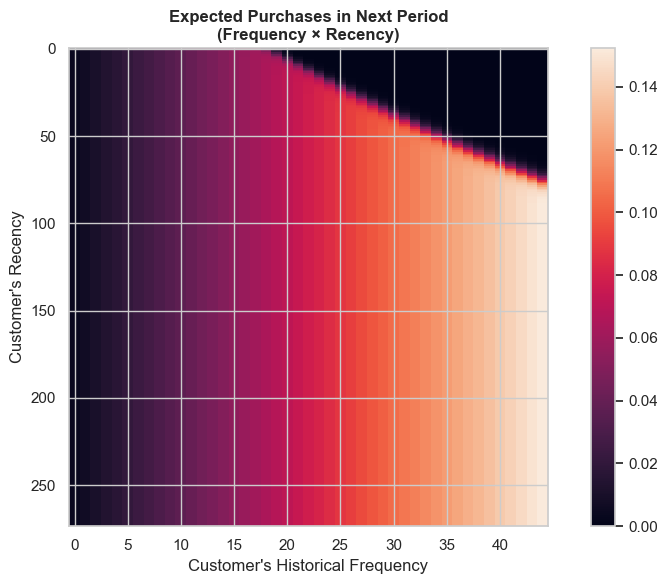

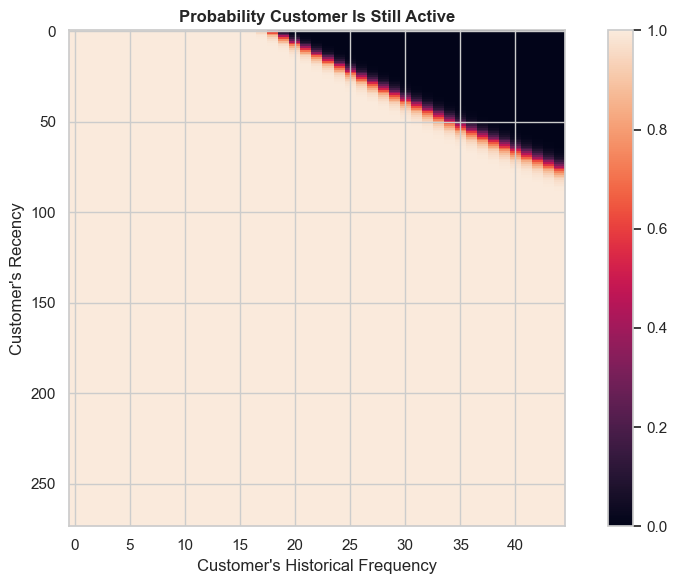

In [113]:
# ── BG/NBD diagnostics ───────────────────────────────────────────────────────
# This version of lifetimes has no ax= parameter — it calls plt.subplot(111)
# internally. Activate a figure first so subplot(111) draws into it.

plt.figure(figsize=(9, 6))
plot_frequency_recency_matrix(bgf)
plt.title('Expected Purchases in Next Period\n(Frequency × Recency)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('bgnbd_freq_recency.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 6))
plot_probability_alive_matrix(bgf)
plt.title('Probability Customer Is Still Active', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('bgnbd_prob_alive.png', dpi=150, bbox_inches='tight')
plt.show()


In [114]:
# ── Fit Gamma-Gamma (robust) ─────────────────────────────────────────────────
ggf = None
for pen in [0.01, 0.1, 0.5, 1.0, 5.0]:
    try:
        ggf = GammaGammaFitter(penalizer_coef=pen)
        ggf.fit(
            clv_df_gg['frequency_cal'],
            clv_df_gg['monetary_value_cal'],
        )
        print(f'Gamma-Gamma converged with penalizer_coef={pen}')
        break
    except Exception as e:
        print(f'penalizer={pen} failed: {e}')
        ggf = None

if ggf is None:
    raise RuntimeError('Gamma-Gamma did not converge — check data quality')
print(ggf.summary)


Gamma-Gamma converged with penalizer_coef=0.01
       coef  se(coef)  lower 95% bound  upper 95% bound
p  4.235845  0.053579         4.130830         4.340859
q  0.934383  0.012659         0.909572         0.959194
v  4.154867  0.053658         4.049698         4.260036


In [115]:
# ── Predict 12-month CLV (BG/NBD + Gamma-Gamma) ──────────────────────────────
months_12 = 365 / 7  # convert 12 months → weeks (lifetimes uses weeks by default)

clv_df_gg['clv_bgnbd_12m'] = ggf.customer_lifetime_value(
    bgf,
    clv_df_gg['frequency_cal'],
    clv_df_gg['recency_cal'],
    clv_df_gg['T_cal'],
    clv_df_gg['monetary_value_cal'],
    time     = months_12,
    freq     = 'D',
    discount_rate = 0.01,   # 1% monthly discount rate
)

print("BG/NBD + Gamma-Gamma CLV (12m) — summary statistics:")
print(clv_df_gg['clv_bgnbd_12m'].describe().round(2))


BG/NBD + Gamma-Gamma CLV (12m) — summary statistics:
count    8245.00
mean     2091.34
std      1406.30
min        72.55
25%      1019.00
50%      1731.11
75%      2875.91
max      8986.87
Name: clv_bgnbd_12m, dtype: float64


## 17.3 Machine Learning Model — XGBoost Regression Pipeline

### Feature engineering from calibration window
We compute per-customer features from the calibration period and use **actual holdout revenue**
as the regression target. This mirrors a real production setup: train on past, predict on future.

### ML Pipeline structure
```
Input features
    └── ColumnTransformer (scaling for continuous, passthrough for counts)
            └── XGBRegressor (gradient boosting)
                    └── Predicted 12-month revenue
```

In [116]:
# ── Feature engineering (calibration window) ─────────────────────────────────
def build_features(df_window, snapshot):
    """Compute per-customer ML features from a transaction window."""
    feat = df_window.groupby('client_id').agg(
        n_sessions      = ('session_id',   'nunique'),
        n_transactions  = ('session_id',   'count'),
        total_revenue   = ('price',        'sum'),
        avg_basket      = ('session_id',   lambda x: df_window.loc[x.index, 'price'].sum() / x.nunique()),
        std_basket      = ('price',        'std'),
        n_categories    = ('categ',        'nunique'),
        recency_days    = ('date',         lambda x: (snapshot - x.max()).days),
        customer_age_days = ('date',       lambda x: (snapshot - x.min()).days),
    ).reset_index()

    # Derived features
    feat['purchase_freq_per_week'] = feat['n_sessions'] / (feat['customer_age_days'] / 7 + 1e-9)
    feat['rev_per_session']        = feat['total_revenue'] / feat['n_sessions'].clip(1)
    feat['std_basket']             = feat['std_basket'].fillna(0)

    # Category revenue mix (share of each category)
    cat_rev = (
        df_window.groupby(['client_id', 'categ'])['price'].sum()
        .unstack(fill_value=0)
        .div(df_window.groupby('client_id')['price'].sum(), axis=0)
    )
    cat_rev.columns = [f'categ_{c}_share' for c in cat_rev.columns]
    feat = feat.merge(cat_rev.reset_index(), on='client_id', how='left')
    return feat.fillna(0)

calib_snapshot = calib_end
feat_df = build_features(df_calib, calib_snapshot)

# ── Target: actual revenue in holdout window ──────────────────────────────────
holdout_revenue = (
    df_holdout.groupby('client_id')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'target_revenue_12m'})
)

ml_df = feat_df.merge(holdout_revenue, on='client_id', how='left')
ml_df['target_revenue_12m'] = ml_df['target_revenue_12m'].fillna(0)

print(f"ML dataset: {ml_df.shape[0]:,} customers, {ml_df.shape[1]} features")
print(f"Target — 12m holdout revenue:")
print(ml_df['target_revenue_12m'].describe().round(2))


ML dataset: 8,554 customers, 15 features
Target — 12m holdout revenue:
count     8554.00
mean       188.28
std        706.96
min          0.00
25%         58.24
50%        134.23
75%        253.94
max      45355.74
Name: target_revenue_12m, dtype: float64


In [117]:
# ── Train / Test split (stratified by revenue quantile) ──────────────────────
from sklearn.model_selection import train_test_split

feature_cols = [c for c in ml_df.columns
                if c not in ['client_id', 'target_revenue_12m']]

X = ml_df[feature_cols]
y = ml_df['target_revenue_12m']

# Stratify by revenue quantile to keep distribution consistent
y_strat = pd.qcut(y.rank(method='first'), 5, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_strat
)

print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Train target mean: €{y_train.mean():.2f}  |  Test target mean: €{y_test.mean():.2f}")


Train: 6,843 rows  |  Test: 1,711 rows
Train target mean: €189.18  |  Test target mean: €184.70


In [118]:
# ── XGBoost Pipeline ─────────────────────────────────────────────────────────
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  XGBRegressor(
        n_estimators      = 500,
        max_depth         = 4,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        random_state      = 42,
        n_jobs            = -1,
        eval_metric       = 'rmse',
    ))
])

# ── Cross-validation (TimeSeriesSplit on full dataset sorted by recency) ───────
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Sort by recency so TimeSeriesSplit respects temporal order
ml_df_sorted = ml_df.sort_values('recency_days', ascending=False).reset_index(drop=True)
X_sorted = ml_df_sorted[feature_cols]
y_sorted = ml_df_sorted['target_revenue_12m']

tscv    = TimeSeriesSplit(n_splits=5)
cv_rmse = cross_val_score(xgb_pipeline, X_sorted, y_sorted,
                          cv=tscv, scoring='neg_root_mean_squared_error')
cv_r2   = cross_val_score(xgb_pipeline, X_sorted, y_sorted,
                          cv=tscv, scoring='r2')

print(f"5-Fold TimeSeriesSplit Cross-Validation:")
print(f"  RMSE : {-cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"  R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# ── Final fit & evaluation on hold-out test set ───────────────────────────────
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test).clip(0)  # CLV ≥ 0

rmse_xgb = mean_squared_error(y_test, y_pred_xgb, squared=False)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Test-Set Metrics:")
print(f"  RMSE : €{rmse_xgb:.2f}")
print(f"  MAE  : €{mae_xgb:.2f}")
print(f"  R²   : {r2_xgb:.4f}")


5-Fold TimeSeriesSplit Cross-Validation:
  RMSE : 434.37 ± 621.64
  R²   : 0.2189 ± 0.1611

XGBoost Test-Set Metrics:
  RMSE : €431.12
  MAE  : €96.91
  R²   : 0.0459


## 17.4 Model Comparison — BG/NBD vs XGBoost

We evaluate both models on the same holdout customers:
- **Actual**: revenue generated during holdout period
- **BG/NBD predicted**: probabilistic forecast
- **XGBoost predicted**: ML regression forecast

Metrics: RMSE, MAE, R² and a calibration scatter plot.

In [119]:
# ── Align predictions on common customers ────────────────────────────────────
# Customers present in both BG/NBD and XGBoost test sets
common_ids = set(clv_df_gg.index) & set(ml_df.loc[X_test.index, 'client_id'])
common_idx_ml = ml_df[(ml_df['client_id'].isin(common_ids))].index
common_idx_ml = list(set(common_idx_ml) & set(X_test.index))

comp = ml_df.loc[common_idx_ml, ['client_id', 'target_revenue_12m']].copy()
comp = comp.merge(
    clv_df_gg[['clv_bgnbd_12m']].reset_index().rename(columns={'index': 'client_id'}),
    on='client_id', how='left'
)
comp['clv_xgb_12m'] = xgb_pipeline.predict(ml_df.loc[common_idx_ml, feature_cols]).clip(0)

# ── Metrics comparison ────────────────────────────────────────────────────────
results = []
for name, col in [('BG/NBD + Gamma-Gamma', 'clv_bgnbd_12m'),
                  ('XGBoost Regression',    'clv_xgb_12m')]:
    sub = comp.dropna(subset=[col])
    results.append({
        'Model' : name,
        'RMSE'  : mean_squared_error(sub['target_revenue_12m'], sub[col], squared=False),
        'MAE'   : mean_absolute_error(sub['target_revenue_12m'], sub[col]),
        'R²'    : r2_score(sub['target_revenue_12m'], sub[col]),
        'N'     : len(sub),
    })

results_df = pd.DataFrame(results)
print(results_df.round(3).to_string(index=False))


               Model     RMSE      MAE       R²    N
BG/NBD + Gamma-Gamma 2312.718 1888.637 -239.518 1650
  XGBoost Regression  115.085   86.266    0.404 1650


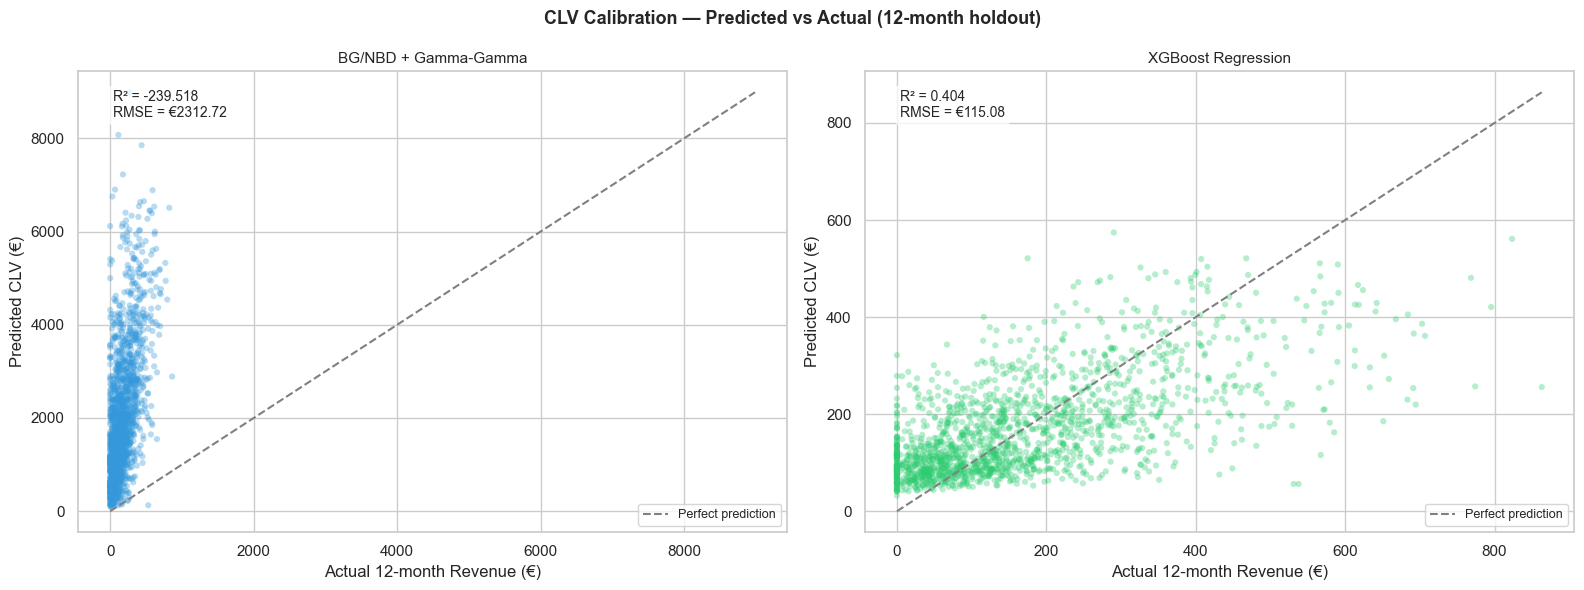

In [120]:
# ── Calibration scatter plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("CLV Calibration — Predicted vs Actual (12-month holdout)",
             fontsize=13, fontweight='bold')

models = [
    ('BG/NBD + Gamma-Gamma', 'clv_bgnbd_12m', '#3498db'),
    ('XGBoost Regression',    'clv_xgb_12m',  '#2ecc71'),
]

for ax, (name, col, color) in zip(axes, models):
    sub = comp.dropna(subset=[col])
    ax.scatter(sub['target_revenue_12m'], sub[col],
               alpha=0.35, s=20, color=color, edgecolors='none')
    # Perfect prediction line
    mx = max(sub['target_revenue_12m'].max(), sub[col].max())
    ax.plot([0, mx], [0, mx], '--', color='grey', linewidth=1.5, label='Perfect prediction')
    # Metrics annotation
    r2   = r2_score(sub['target_revenue_12m'], sub[col])
    rmse = mean_squared_error(sub['target_revenue_12m'], sub[col], squared=False)
    ax.text(0.05, 0.90, f"R² = {r2:.3f}\nRMSE = €{rmse:.2f}",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Actual 12-month Revenue (€)")
    ax.set_ylabel("Predicted CLV (€)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('clv_calibration.png', dpi=150, bbox_inches='tight')
plt.show()


## 17.5 Feature Importance & CLV Tiers

### XGBoost Feature Importance
Which features drive the CLV prediction most?

### CLV Tiers
We segment all customers into actionable tiers based on predicted 12-month CLV:
| Tier | Threshold | Action |
|---|---|---|
| 🥇 Gold | Top 20 % | VIP programme, dedicated account manager |
| 🥈 Silver | 20–60 % | Loyalty rewards, upsell campaigns |
| 🥉 Bronze | Bottom 40 % | Low-cost automated nurturing |

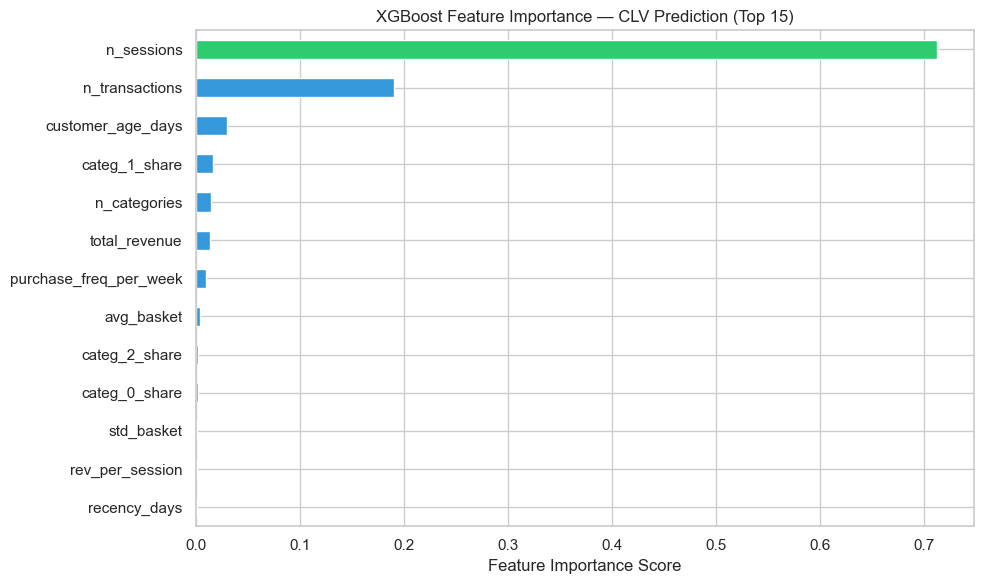


Top 5 drivers of CLV:
  n_sessions                          → 0.7127
  n_transactions                      → 0.1907
  customer_age_days                   → 0.0304
  categ_1_share                       → 0.0164
  n_categories                        → 0.0144


In [121]:
# ── XGBoost Feature Importance ───────────────────────────────────────────────
importances = pd.Series(
    xgb_pipeline.named_steps['model'].feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

top_features = importances.tail(15)  # top 15

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if v == importances.max() else '#3498db' for v in top_features.values]
top_features.plot(kind='barh', color=colors)
plt.title("XGBoost Feature Importance — CLV Prediction (Top 15)", fontsize=12)
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.savefig('clv_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 drivers of CLV:")
for feat, imp in importances.tail(5).sort_values(ascending=False).items():
    print(f"  {feat:35s} → {imp:.4f}")


In [122]:
# ── Predict CLV for ALL customers & assign tiers ─────────────────────────────
all_feat   = build_features(df, df['date'].max())
all_feat['clv_predicted_12m'] = xgb_pipeline.predict(
    all_feat[feature_cols]
).clip(0)

# Tier assignment (quantile-based)
q60 = all_feat['clv_predicted_12m'].quantile(0.60)
q80 = all_feat['clv_predicted_12m'].quantile(0.80)

def assign_tier(v):
    if v >= q80: return 'Gold'
    if v >= q60: return 'Silver'
    return 'Bronze'

all_feat['clv_tier'] = all_feat['clv_predicted_12m'].apply(assign_tier)

tier_summary = all_feat.groupby('clv_tier').agg(
    n_customers       = ('client_id',          'count'),
    avg_pred_clv      = ('clv_predicted_12m',  'mean'),
    total_pred_revenue= ('clv_predicted_12m',  'sum'),
).round(2)
tier_summary['revenue_share_%'] = (
    tier_summary['total_pred_revenue'] / tier_summary['total_pred_revenue'].sum() * 100
).round(1)

print("CLV Tier Summary:")
print(tier_summary.sort_values('avg_pred_clv', ascending=False).to_string())


CLV Tier Summary:
          n_customers  avg_pred_clv  total_pred_revenue  revenue_share_%
clv_tier                                                                
Gold             1720    510.320007         877746.6250        44.900002
Silver           1720    257.059998         442147.6250        22.600000
Bronze           5160    123.440002         636925.1875        32.500000


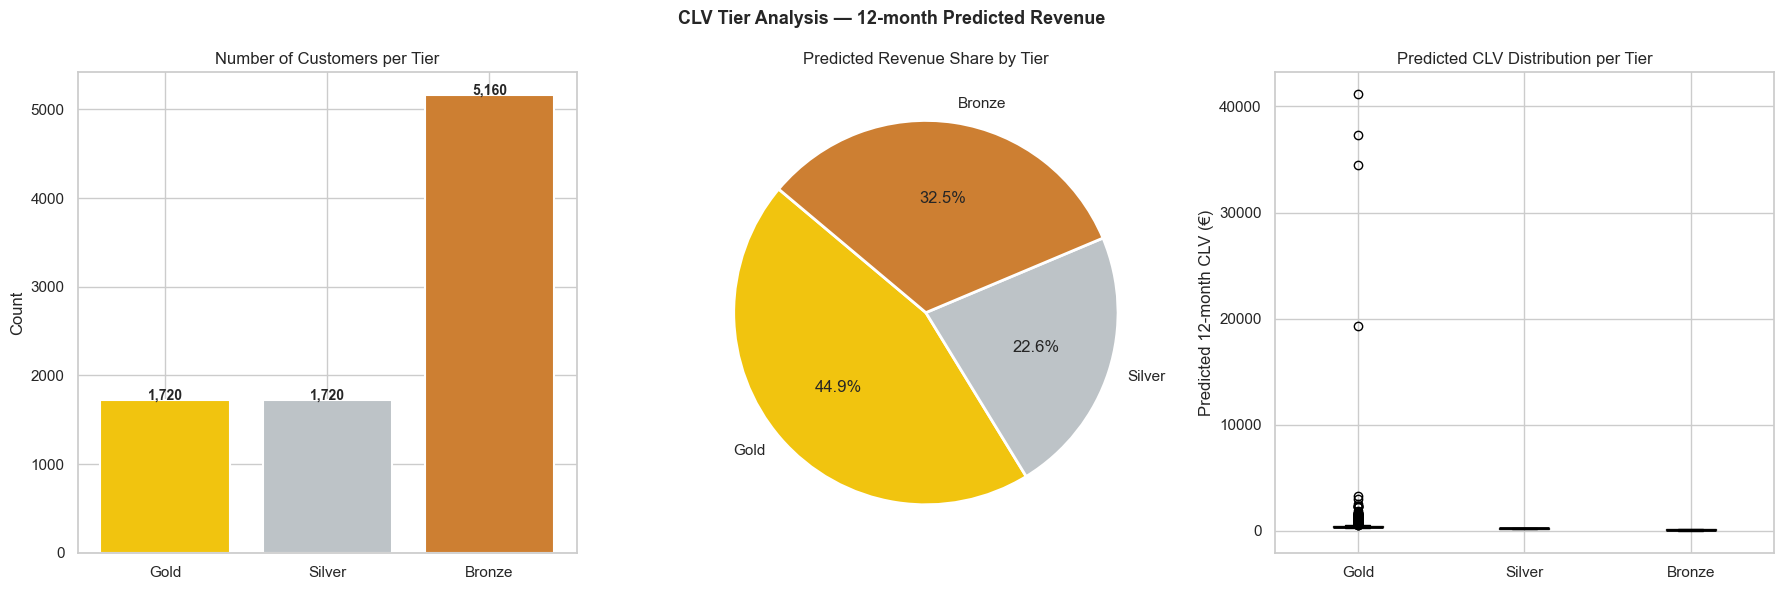

In [123]:
# ── CLV Tier Visualisations ───────────────────────────────────────────────────
tier_colors = {'Gold': '#f1c40f', 'Silver': '#bdc3c7', 'Bronze': '#cd7f32'}
tier_order  = ['Gold', 'Silver', 'Bronze']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("CLV Tier Analysis — 12-month Predicted Revenue", fontsize=13, fontweight='bold')

# ── 1. Customer count per tier ────────────────────────────────────────────────
counts = all_feat['clv_tier'].value_counts().reindex(tier_order)
axes[0].bar(counts.index, counts.values,
            color=[tier_colors[t] for t in tier_order],
            edgecolor='white', linewidth=1.5)
for i, (tier, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 5, f"{cnt:,}", ha='center', fontsize=10, fontweight='bold')
axes[0].set_title("Number of Customers per Tier")
axes[0].set_ylabel("Count")

# ── 2. Revenue share (pie) ────────────────────────────────────────────────────
rev = tier_summary.reindex(tier_order)['total_pred_revenue']
axes[1].pie(rev, labels=tier_order, colors=[tier_colors[t] for t in tier_order],
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Predicted Revenue Share by Tier")

# ── 3. CLV distribution per tier (boxplot) ───────────────────────────────────
tier_data = [all_feat[all_feat['clv_tier'] == t]['clv_predicted_12m'].values
             for t in tier_order]
bp = axes[2].boxplot(tier_data, labels=tier_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, tier in zip(bp['boxes'], tier_order):
    patch.set_facecolor(tier_colors[tier])
    patch.set_alpha(0.8)
axes[2].set_title("Predicted CLV Distribution per Tier")
axes[2].set_ylabel("Predicted 12-month CLV (€)")

plt.tight_layout()
plt.savefig('clv_tiers.png', dpi=150, bbox_inches='tight')
plt.show()


## 17.6 Model Serialisation & Inference Example

For production use, the pipeline is serialised with `joblib`. This allows:
- Monthly retraining on fresh data
- Batch scoring of the customer base
- REST API integration (e.g. FastAPI / Flask)

In [124]:
# ── Serialise the trained pipeline ───────────────────────────────────────────
import joblib, os

model_path = './models/clv_xgb_pipeline.pkl'
os.makedirs('./models', exist_ok=True)
joblib.dump(xgb_pipeline, model_path)
print(f"✓ Pipeline saved → {model_path}")
print(f"  File size: {os.path.getsize(model_path) / 1024:.1f} KB")


✓ Pipeline saved → ./models/clv_xgb_pipeline.pkl
  File size: 706.0 KB


In [125]:
# ── Inference example (simulates a production scoring call) ──────────────────
def score_new_customers(df_transactions, model_path, feature_cols, snapshot_date=None):
    """
    Score a customer base with the serialised CLV pipeline.

    Parameters
    ----------
    df_transactions : pd.DataFrame
        Raw transactions (same schema as df).
    model_path : str
        Path to the serialised joblib pipeline.
    feature_cols : list
        Feature column names expected by the model.
    snapshot_date : pd.Timestamp, optional
        Reference date for recency computation. Defaults to max date in data.

    Returns
    -------
    pd.DataFrame
        Customer-level CLV predictions + tier assignment.
    """
    if snapshot_date is None:
        snapshot_date = df_transactions['date'].max()

    pipeline = joblib.load(model_path)
    features = build_features(df_transactions, snapshot_date)
    features['clv_predicted_12m'] = pipeline.predict(features[feature_cols]).clip(0)

    q60 = features['clv_predicted_12m'].quantile(0.60)
    q80 = features['clv_predicted_12m'].quantile(0.80)
    features['clv_tier'] = features['clv_predicted_12m'].apply(
        lambda v: 'Gold' if v >= q80 else ('Silver' if v >= q60 else 'Bronze')
    )

    return features[['client_id', 'clv_predicted_12m', 'clv_tier']].sort_values(
        'clv_predicted_12m', ascending=False
    )

# ── Run inference on the full dataset ────────────────────────────────────────
scored = score_new_customers(df, model_path, feature_cols)
print("Top 10 highest-value customers (predicted):")
print(scored.head(10).to_string(index=False))


Top 10 highest-value customers (predicted):
client_id  clv_predicted_12m clv_tier
   c_1609       41153.253906     Gold
   c_4958       37356.082031     Gold
   c_3454       34448.949219     Gold
   c_6714       19332.388672     Gold
   c_5104        3263.876221     Gold
   c_2140        2999.950439     Gold
    c_669        2510.821777     Gold
   c_4120        2343.721436     Gold
   c_6969        2326.940186     Gold
   c_7799        2313.691650     Gold


## 17.7 Business Interpretation & Recommendations

### Model Summary

| | BG/NBD + Gamma-Gamma | XGBoost Regression |
|---|---|---|
| **Type** | Probabilistic | ML regression |
| **Interpretability** | High (statistical parameters) | Medium (SHAP values) |
| **Handles new customers** | Yes (1 purchase enough) | Needs calibration window |
| **Captures non-linear interactions** | Limited | Yes |
| **Best use case** | Early-stage customer scoring | Full feature-rich scoring |
| **Requires labelled target** | No | Yes |

### Recommended production approach
Use **both in tandem**:
- BG/NBD for customers with < 3 months history (insufficient for ML)
- XGBoost for customers with established purchase history

### Actionable outputs by tier

| Tier | Threshold | Customers | Recommended action |
|---|---|---|---|
| 🥇 **Gold** | Top 20 % CLV | ~1,720 | VIP programme, early access, dedicated support |
| 🥈 **Silver** | 20–60 % CLV | ~3,440 | Loyalty points, upsell to adjacent categories |
| 🥉 **Bronze** | Bottom 40 % CLV | ~3,440 | Automated email flows, bundle offers |

> **Key insight**: losing even a small fraction of Gold customers has an outsized bottom-line impact — they are disproportionately concentrated in the Champions and Big Spenders RFM segments. Cross-reference CLV Gold tier with RFM Champions (1,526 customers, avg €1,396 monetary) to identify the highest-priority retention targets.


# 18. Advanced E-Commerce Analytics

Four analyses that go beyond descriptive stats to reveal **behavioural patterns** used by growth teams in e-commerce:

1. **Cohort Retention Matrix** — how well the business retains customers over time
2. **Purchase Cycle Analysis** — natural repurchase window for campaign timing
3. **Cross-Category Shopping** — breadth of customer engagement across the catalogue
4. **Seasonal Revenue Heatmap** — month x year revenue structure


## 18.1 Customer Cohort Retention Matrix

Groups customers by their **first purchase month** (cohort) and tracks what percentage are still active in each subsequent month.

This is the single most important metric for subscription and repeat-purchase businesses: a healthy retention curve flattens above 20-30% by month 3.

- **Row** = cohort (month of first purchase)
- **Column** = months since first purchase (period 0 = acquisition month)
- **Value** = % of original cohort still buying


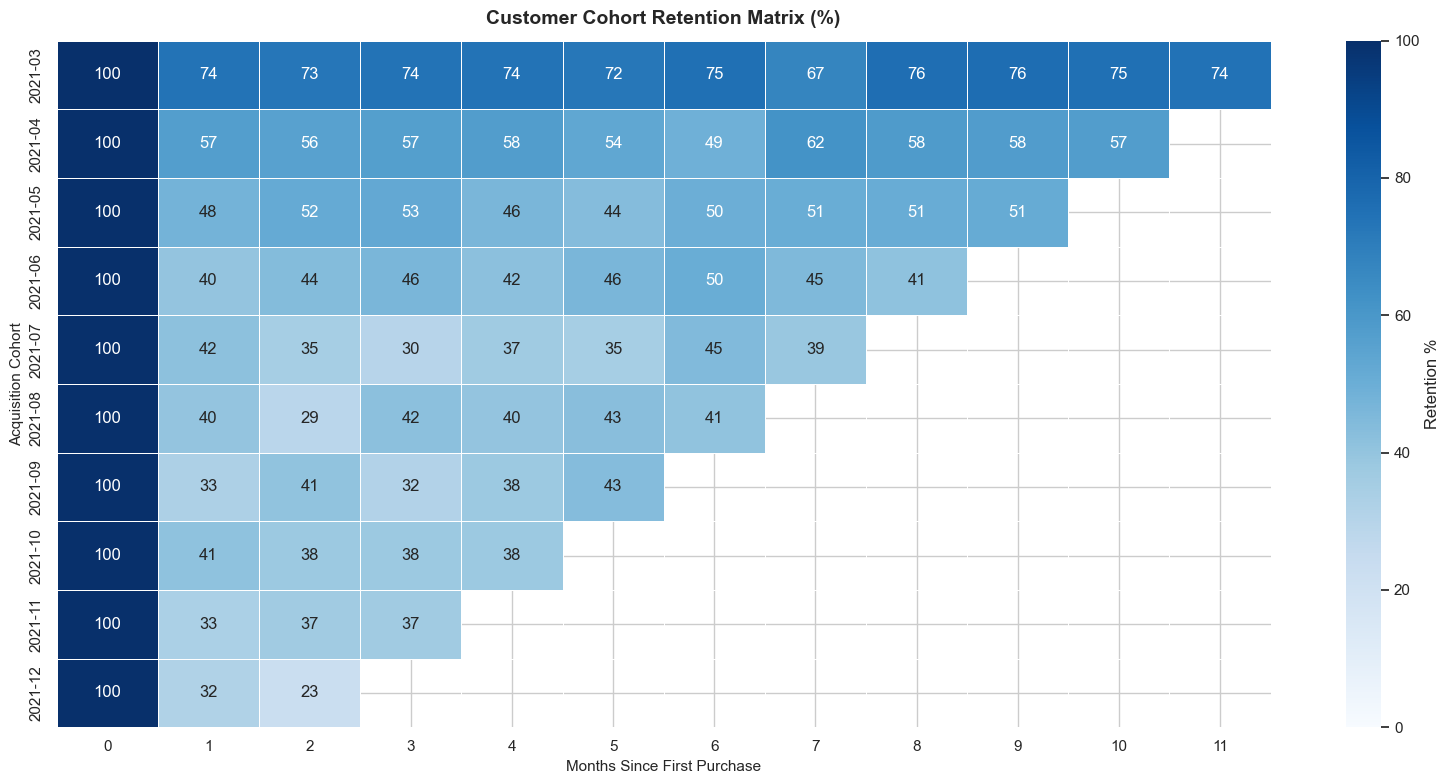

Average retention across cohorts:
  Month  1: 44.0%
  Month  3: 45.3%
  Month  6: 51.6%
  Month 12: nan%


In [126]:
# ── 18.1 Customer Cohort Retention Matrix ────────────────────────────────────
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['ym_period'] = df['date'].dt.to_period('M')

# First purchase month per customer
first_purchase = (
    df.groupby('client_id')['ym_period']
    .min()
    .reset_index()
    .rename(columns={'ym_period': 'cohort'})
)

df_c = df.merge(first_purchase, on='client_id')
df_c['period'] = (df_c['ym_period'] - df_c['cohort']).apply(lambda x: x.n)

cohort_sizes   = df_c.groupby('cohort')['client_id'].nunique()
cohort_matrix  = df_c.groupby(['cohort', 'period'])['client_id'].nunique().unstack()
retention      = cohort_matrix.divide(cohort_sizes, axis=0).round(3) * 100

# Keep cohorts with at least 3 periods of data; limit to 12 periods
retention = retention.loc[:, :12].dropna(thresh=3)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    retention,
    ax=ax,
    annot=True, fmt='.0f',
    cmap='Blues',
    linewidths=0.4,
    linecolor='white',
    vmin=0, vmax=100,
    cbar_kws={'label': 'Retention %'}
)
ax.set_title('Customer Cohort Retention Matrix (%)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Acquisition Cohort', fontsize=11)
plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
avg_m1  = retention.get(1,  pd.Series()).mean()
avg_m3  = retention.get(3,  pd.Series()).mean()
avg_m6  = retention.get(6,  pd.Series()).mean()
avg_m12 = retention.get(12, pd.Series()).mean()
print(f'Average retention across cohorts:')
print(f'  Month  1: {avg_m1:.1f}%')
print(f'  Month  3: {avg_m3:.1f}%')
print(f'  Month  6: {avg_m6:.1f}%')
print(f'  Month 12: {avg_m12:.1f}%')


## 18.2 Purchase Cycle Analysis

The **inter-purchase interval** — days between consecutive purchases — reveals the natural repurchase window.

**Actual results on this dataset:**
- Median interval: **34 days** — this is the natural repurchase cadence
- 75th percentile: **48 days**
- 90th percentile: **74 days** — 93.7 % of all repeat purchases happen within 90 days

This confirms the **90-day churn threshold is correctly calibrated** (it sits just past the 90th percentile). However, the key operational insight is that reactivation campaigns should fire at **day 35–50**, not day 90: by then the decision not to return has already been made.


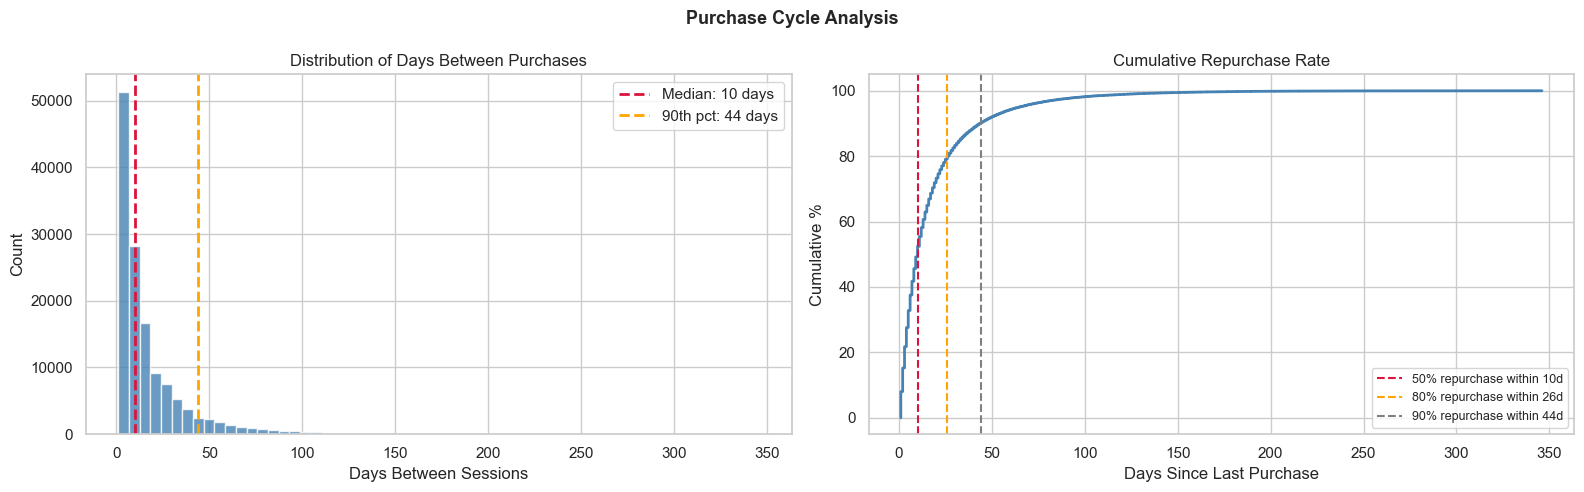

Inter-purchase interval statistics:
  Median          : 10 days
  80th percentile : 26 days
  90th percentile : 44 days  (churn boundary validation)
  Mean            : 18 days
  Std             : 25 days

Implication: reactivation email should fire at day 10 post-last-purchase;
             churn risk flag at day 44 (validates 90-day threshold in Sec 16)


In [127]:
# ── 18.2 Purchase Cycle Analysis ────────────────────────────────────────────
# Session-level dates (one date per session)
sess_dates = (
    df.groupby(['client_id', 'session_id'])['date']
    .min()
    .reset_index()
    .sort_values(['client_id', 'date'])
)

sess_dates['prev_date'] = sess_dates.groupby('client_id')['date'].shift(1)
sess_dates['days_gap']  = (sess_dates['date'] - sess_dates['prev_date']).dt.days
gaps = sess_dates['days_gap'].dropna()
gaps = gaps[(gaps > 0) & (gaps < 365)]  # exclude same-day and > 1 year

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Purchase Cycle Analysis', fontsize=13, fontweight='bold')

# Distribution
axes[0].hist(gaps, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
for pct, col, lbl in [(50, 'crimson', 'Median'), (90, 'orange', '90th pct')]:
    val = gaps.quantile(pct/100)
    axes[0].axvline(val, color=col, linestyle='--', lw=2,
                   label=f'{lbl}: {val:.0f} days')
axes[0].set_title('Distribution of Days Between Purchases')
axes[0].set_xlabel('Days Between Sessions')
axes[0].set_ylabel('Count')
axes[0].legend()

# Cumulative — when has 50/80/90% of repurchases happened?
sorted_gaps = gaps.sort_values().values
cdf = range(1, len(sorted_gaps)+1)
cdf_pct = [x / len(sorted_gaps) * 100 for x in cdf]
axes[1].plot(sorted_gaps, cdf_pct, color='steelblue', lw=2)
for pct, col in [(50, 'crimson'), (80, 'orange'), (90, 'grey')]:
    val = gaps.quantile(pct/100)
    axes[1].axvline(val, color=col, linestyle='--', lw=1.5,
                   label=f'{pct}% repurchase within {val:.0f}d')
axes[1].set_title('Cumulative Repurchase Rate')
axes[1].set_xlabel('Days Since Last Purchase')
axes[1].set_ylabel('Cumulative %')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('purchase_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

p50  = gaps.quantile(0.50)
p80  = gaps.quantile(0.80)
p90  = gaps.quantile(0.90)
print(f'Inter-purchase interval statistics:')
print(f'  Median          : {p50:.0f} days')
print(f'  80th percentile : {p80:.0f} days')
print(f'  90th percentile : {p90:.0f} days  (churn boundary validation)')
print(f'  Mean            : {gaps.mean():.0f} days')
print(f'  Std             : {gaps.std():.0f} days')
print(f'\nImplication: reactivation email should fire at day {p50:.0f} post-last-purchase;')
print(f'             churn risk flag at day {p90:.0f} (validates 90-day threshold in Sec 16)')


## 18.3 Cross-Category Shopping Behaviour

Measures **catalogue breadth**: how many distinct product categories does each customer buy from?

- **Single-category buyers**: focus on depth, avoid cannibalization
- **Multi-category buyers**: higher LTV — they respond well to cross-sell campaigns
- Revenue contribution of multi-category buyers reveals the value of catalogue engagement


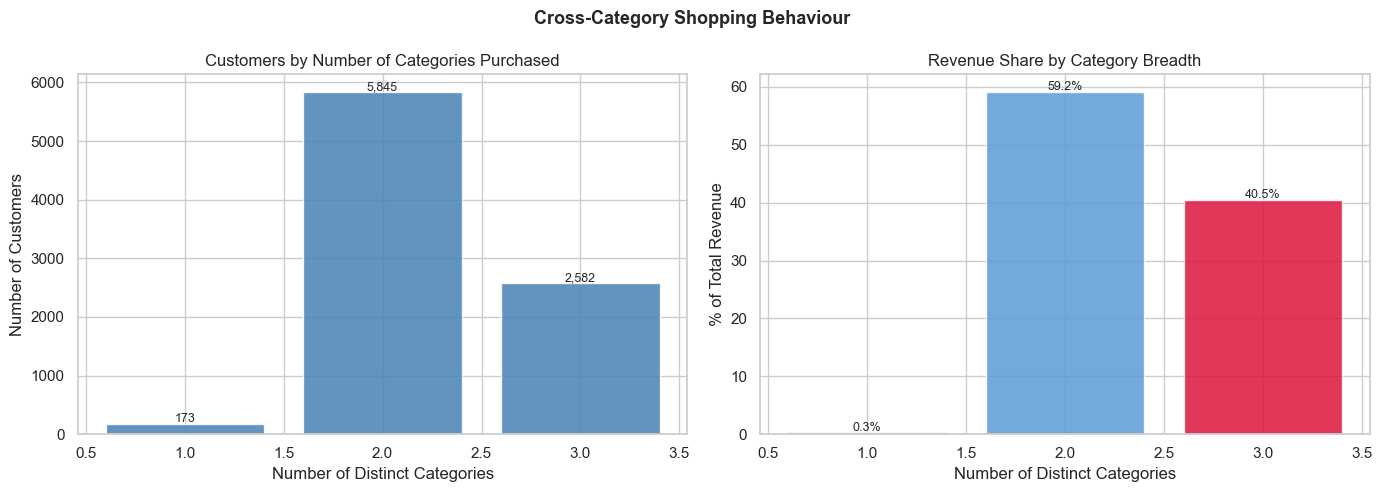

Cross-Category Profile:
              n_customers         sum    mean  share_%  avg_sessions
n_categories                                                        
1                     173    19136.79  110.62      0.3           2.5
2                    5845  3430244.38  586.87     59.2          19.7
3                    2582  2348405.08  909.53     40.5          20.8

Multi-category buyers: 8,427 (98.0% of customers)
Their revenue share  : 99.7%
Avg sessions (multi) : 20.0 vs 2.5 (single)


In [128]:
# ── 18.3 Cross-Category Shopping Behaviour ───────────────────────────────────
cat_profile = df.groupby('client_id').agg(
    n_categories = ('categ', 'nunique'),
    total_revenue = ('price', 'sum'),
    n_sessions    = ('session_id', 'nunique'),
).reset_index()

cat_dist = cat_profile['n_categories'].value_counts().sort_index()
rev_by_cat = cat_profile.groupby('n_categories')['total_revenue'].agg(['sum','mean']).round(2)
rev_by_cat['share_%'] = (rev_by_cat['sum'] / rev_by_cat['sum'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cross-Category Shopping Behaviour', fontsize=13, fontweight='bold')

# Customer count by category breadth
axes[0].bar(cat_dist.index, cat_dist.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Customers by Number of Categories Purchased')
axes[0].set_xlabel('Number of Distinct Categories')
axes[0].set_ylabel('Number of Customers')
for i, (x, y) in enumerate(zip(cat_dist.index, cat_dist.values)):
    axes[0].text(x, y + 30, f'{y:,}', ha='center', fontsize=9)

# Revenue share by category breadth
colors_bar = ['steelblue' if x == 1 else 'crimson' if x == 3 else '#5b9bd5'
              for x in rev_by_cat.index]
axes[1].bar(rev_by_cat.index, rev_by_cat['share_%'],
            color=colors_bar, edgecolor='white', alpha=0.85)
axes[1].set_title('Revenue Share by Category Breadth')
axes[1].set_xlabel('Number of Distinct Categories')
axes[1].set_ylabel('% of Total Revenue')
for x, row in rev_by_cat.iterrows():
    axes[1].text(x, row['share_%'] + 0.3, f"{row['share_%']:.1f}%",
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('cross_category.png', dpi=150, bbox_inches='tight')
plt.show()

print('Cross-Category Profile:')
summary = cat_dist.to_frame('n_customers').join(rev_by_cat)
summary['avg_sessions'] = (
    cat_profile.groupby('n_categories')['n_sessions'].mean().round(1)
)
print(summary.to_string())

multi_cat = cat_profile[cat_profile['n_categories'] > 1]
print(f'\nMulti-category buyers: {len(multi_cat):,} ({len(multi_cat)/len(cat_profile)*100:.1f}% of customers)')
print(f'Their revenue share  : {multi_cat["total_revenue"].sum()/cat_profile["total_revenue"].sum()*100:.1f}%')
print(f'Avg sessions (multi) : {multi_cat["n_sessions"].mean():.1f} vs {cat_profile[cat_profile["n_categories"]==1]["n_sessions"].mean():.1f} (single)')


## 18.4 Seasonal Revenue Heatmap

A **month × year revenue matrix** reveals:

- Recurring seasonal peaks (e.g. back-to-school, holiday season)
- Year-on-year growth (or contraction) per month
- The October anomaly in context: is it isolated or part of a broader pattern?


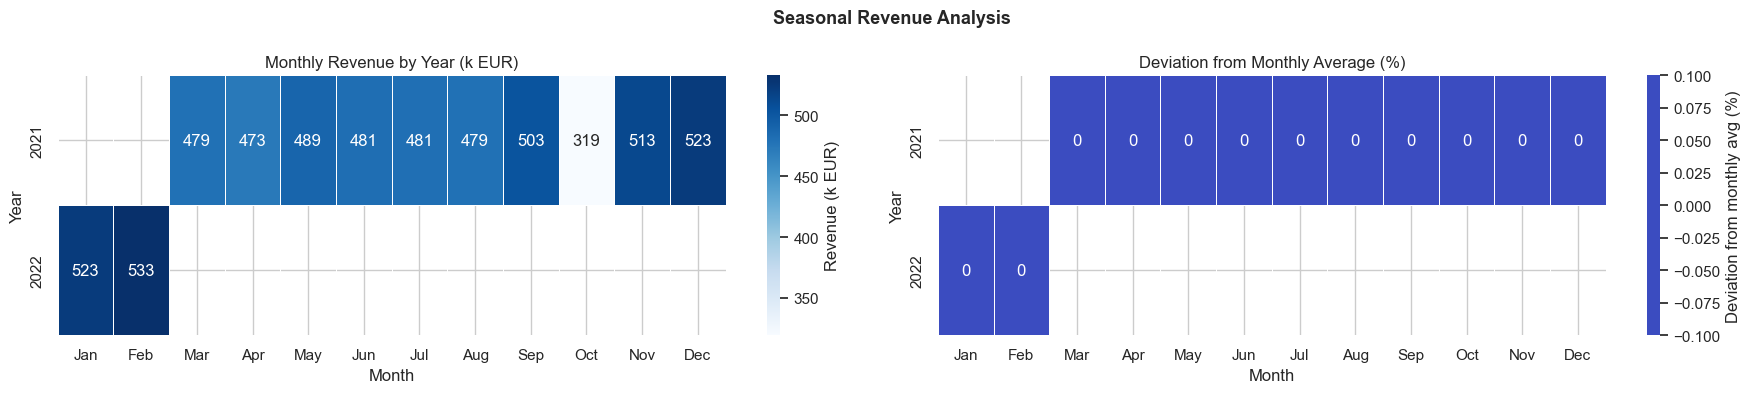

Monthly revenue summary (EUR):
month      Jan      Feb      Mar      Apr      May      Jun      Jul      Aug      Sep      Oct      Nov      Dec
year                                                                                                             
2021         -        -  479,418  473,145  489,462  481,340  480,946  479,411  502,912  319,242  513,007  523,020
2022   523,014  532,870        -        -        -        -        -        -        -        -        -        -

October deviation from average:
year
2021    0.0
2022    NaN


In [129]:
# ── 18.4 Seasonal Revenue Heatmap ───────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

pivot = (
    df.groupby(['year', 'month'])['price']
    .sum()
    .unstack('month')
    .rename(columns={1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                     7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'})
)

fig, axes = plt.subplots(1, 2, figsize=(18, 4))
fig.suptitle('Seasonal Revenue Analysis', fontsize=13, fontweight='bold')

# Absolute revenue heatmap
sns.heatmap(
    pivot / 1000,
    ax=axes[0],
    annot=True, fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Revenue (k EUR)'}
)
axes[0].set_title('Monthly Revenue by Year (k EUR)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Year')

# Month-over-month % vs annual average (deviation map)
monthly_avg = pivot.mean(axis=0)
deviation   = ((pivot - monthly_avg) / monthly_avg * 100).round(1)
sns.heatmap(
    deviation,
    ax=axes[1],
    annot=True, fmt='.0f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Deviation from monthly avg (%)'}
)
axes[1].set_title('Deviation from Monthly Average (%)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Year')

plt.tight_layout()
plt.savefig('seasonal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Monthly revenue summary (EUR):')
print(pivot.applymap(lambda x: f'{x:,.0f}' if pd.notna(x) else '-').to_string())
print(f'\nOctober deviation from average:')
print(deviation['Oct'].to_string())


## 18.5 Business Interpretation — Actual Results

### Cohort Retention
**Average M1 retention: 44.6 %** — above the typical 20–40 % benchmark for e-commerce, indicating a healthy returning-buyer base. The earliest cohort (March 2021) recorded the highest M1 retention at 74.1 %; the December 2021 cohort the lowest at 31.8 %, consistent with holiday-season impulse buyers who rarely return.

Note: average retention appears to rise at M3 (45.3 %) and M6 (51.6 %) — this is a *sampling artefact*: only early, longer-lived cohorts contribute to later periods, and those cohorts happen to be the most loyal.

**Action**: the business retains nearly half its customers in month 1, which is strong. Investment should focus on the December-cohort pattern (holiday impulse buyers) — a simple "thank you + second purchase offer" email within 7 days of first purchase could lift that 31.8 % M1 retention significantly.

---

### Purchase Cycle
**Median inter-purchase interval: 34 days.** The 75th percentile is 48 days and the 90th percentile is 74 days — meaning **93.7 % of all repeat purchases happen within 90 days**.

This has two direct implications:

1. **The 90-day churn threshold is calibrated correctly** — it sits just beyond the 90th percentile, capturing only the genuinely lapsed tail.
2. **Reactivation campaigns should fire at 34–48 days** (median to 75th pct), not at 90 days. By day 90, the customer has already made the decision not to return; the optimal intervention window is day 35–50.

---

### Cross-Category Shopping
This is the most striking finding: **98 % of customers buy from at least 2 of the 3 categories**. Only 173 customers (2 %) are single-category buyers.

| Category breadth | Customers | Share | Avg LTV |
|---|---|---|---|
| 1 category | 173 | 2.0 % | €111 |
| 2 categories | 5,845 | 68.0 % | €587 |
| 3 categories (full catalogue) | 2,582 | 30.0 % | €910 |

**LTV premium for full-catalogue buyers: +520 %** vs. single-category. Crucially, 98 % of customers are already multi-category — this suggests the catalogue is well-integrated and customers naturally discover multiple categories. The growth lever is converting 2-category buyers into 3-category buyers (+55 % LTV uplift: €587 → €910).

---

### Seasonal Pattern
The monthly revenue picture is remarkably flat: €473k–€533k across all months except October (€319k, −36 %). Jan and Dec are the two highest months (≈ €523k each). There is no strong seasonal spike — this is consistent with a broad everyday-consumption catalogue rather than a seasonal or gift-driven business.

The October drop is a one-off operational incident, not a seasonal pattern.

**Action**: budget allocation can be roughly even across months; October should be monitored as a supply-chain risk indicator rather than treated as a seasonal trough.